In [1]:
import os
import json
import pandas as pd
import re

import google.generativeai as genai
from google.cloud import bigquery, storage
import google.auth
import vertexai
from vertexai.generative_models import (
    GenerativeModel,
    GenerationConfig,
    HarmCategory,
    HarmBlockThreshold,
    GenerationResponse,
    Content,
    Part,
)
import asyncio
from asynciolimiter import Limiter
from tqdm.asyncio import tqdm_asyncio
from transformers import AutoTokenizer
from tqdm.auto import tqdm
import yaml

from typing import List, Dict, Tuple

from langchain_community.utilities.python import PythonREPL
import jsonlines

import nest_asyncio
from dotenv import load_dotenv

nest_asyncio.apply()
load_dotenv()

True

In [6]:
# CONFIG Bucket
CONFIG_BUCKET = "tmhcc-dev-intermediate"

credentials, project_id = google.auth.default()
LOCATION = os.getenv("GCP_LOCATION")

vertexai.init(
    project=os.getenv("GCP_PROJECT"), location=LOCATION, credentials=credentials
)

storage_client = storage.Client()
bigquery_client = bigquery.Client()
genai.configure(api_key=os.getenv("GOOGLE_AI_STUDIO_API_KEY"))

ROOT_DATA_DIR = os.path.join("..", "..", "..", *os.getenv("DATA_DIR").split(","))
BASE_FOLDER = os.path.join(ROOT_DATA_DIR, "info_collection")
FOLDER_NAME = "Collected_Math_Problems"
FOLDER_PATH = os.path.join(ROOT_DATA_DIR, FOLDER_NAME)
INTERIM_FOLDER = os.path.join(ROOT_DATA_DIR, "InterimFiles")
(
    os.path.exists(ROOT_DATA_DIR),
    os.path.exists(FOLDER_PATH),
    os.path.exists(INTERIM_FOLDER),
)

(True, True, True)

## Testing

In [ ]:
fnames = os.listdir(FOLDER_PATH)
cleaned_fnames = [fname for fname in fnames if fname.startswith('Cleaned_')]
cleaned_fnames

In [4]:
gemma_tokenizer = AutoTokenizer.from_pretrained("google/gemma-1.1-2b-it")

with open('chat_template.txt', 'r') as f:
    chat_template = f.read()
    chat_template = chat_template.replace("'problem'", "'math_problem'")

gemma_tokenizer.chat_template = chat_template

In [5]:
with open(os.path.join(FOLDER_PATH, cleaned_fnames[10]), 'r') as f:
    messages = json.load(f)

for idx, msg in enumerate(messages):
    if msg['role'] != 'step':
        continue

    for jdx, substep in enumerate(msg['content']):
        if substep['role'] != 'code_output':
            continue

        if not isinstance(substep['content'], list):
            messages[idx]['content'][jdx]['content'] = [substep['content']]

        # print(f"Step {idx + 1}, Substep {jdx + 1}, Code Output: {substep['content']}")

print(gemma_tokenizer.apply_chat_template(messages[1:], tokenize=False)[5:])

<math_problem>Is the following statement true or false?
All natural numbers are whole numbers.</math_problem>
<start_of_step>1
As the definition of whole number and natural numbers is not given, we assume:
- Whole numbers defined as the set of non-negative integers: $\{0, 1, 2, 3, \cdots\}$.
- Natural numbers defined as the set of positive integers: $\{1, 2, 3, \cdots\}$.<end_of_step>
<start_of_step>2
By these two definitions we can conclude that all natural numbers are whole numbers. Hence the statement is $\boxed{True}$.<end_of_step>



In [6]:
df = pd.read_json(os.path.join('..', 'data', 'info_collection', 'preprocess_input.jsonl'), lines=True, orient='records')
df

,id,problem,solution,prompt,concept,chapter_name
0,Exp0000,Write the next three natural numbers after 10999.,"10,999+1 = 11,000\n11,000 + 1 = 11,001\n11,001...",<math_problem>\nWrite the next three natural n...,Concept for Natural Numbers,Whole Numbers
1,Exp0001,Write the three whole numbers occurring just b...,Three whole numbers occurring just before 1000...,<math_problem>\nWrite the three whole numbers ...,Concept for Whole Numbers,Whole Numbers
2,Exp0002,Which is the smallest whole number?,0 (zero) is the smallest whole number. All the...,<math_problem>\nWhich is the smallest whole nu...,Concept for Whole Numbers,Whole Numbers
3,Exp0003,How many whole numbers are there between 32 an...,Whole numbers between 32 and 53 = 20 (53 − 32 ...,<math_problem>\nHow many whole numbers are the...,Concept for Whole Numbers,Whole Numbers
4,Exp0004,Write the successor of 2440701.,The successor of 2440701 is\n2440701 + 1 = 244...,<math_problem>\nWrite the successor of 2440701...,Successor and Predecessor of Whole Number,Whole Numbers
...,...,...,...,...,...,...
4321,Exp4321,If each element of a second order determinant ...,The total number of determinants of second ord...,<math_problem>\nIf each element of a second or...,Independent Events,Probability
4322,Exp4322,An electronic assembly consists of two subsyst...,Let the event in which A fails and B fails be ...,<math_problem>\nAn electronic assembly consist...,Properties of Conditional Probability,Probability
4323,Exp4323,If A and B are two events such that P (A) ≠ 0 ...,"P (A) ≠ 0 and P(B|A) = 1\n\nThus, the correct ...",<math_problem>\nIf A and B are two events such...,Properties of Conditional Probability,Probability
4324,Exp4324,"If P (A|B) > P (A), then which of the followin...","\nThus, the correct answer is C.","<math_problem>\nIf P (A|B) > P (A), then which...",Properties of Conditional Probability,Probability


In [17]:
example_pairs = []

for fname in cleaned_fnames:
    exp_id = fname.split('.')[0][8:]
    # input_prompt = df[df['id'] == exp_id].prompt.values[0]
    # input_prompt = input_prompt.replace('math_problem>', 'problem>')

    problem = df[df['id'] == exp_id].problem.values[0]
    
    with open(os.path.join(FOLDER_PATH, fname), 'r') as f:
        messages = json.load(f)

    for idx, msg in enumerate(messages):
        if msg['role'] != 'step':
            continue

        for jdx, substep in enumerate(msg['content']):
            if substep['role'] != 'code_output':
                continue

            if not isinstance(substep['content'], list):
                messages[idx]['content'][jdx]['content'] = [substep['content']]

    output = gemma_tokenizer.apply_chat_template(messages[1:], tokenize=False)[5:]

    example_pairs.append((problem, output))

In [19]:
print(example_pairs[12])

('Find the product by suitable rearrangement: 8 × 291 × 125', '<math_problem>Find the product by suitable rearrangement: $8 \\times 291 \\times 125$</math_problem>\n<start_of_step>1\n<code_input_block>\n<code>print(8 * 125 * 291)</code>\n</code_input_block>\n<code_output_block>\n291000\n</code_output_block>Therefore, $8 \\times 291 \\times 125 = \\boxed{291000}$<end_of_step>\n')


In [44]:
# Create the model
# See https://ai.google.dev/api/python/google/generativeai/GenerativeModel
generation_config = {
  "temperature": 0,
  "top_p": 0.95,
  "top_k": 64,
  "max_output_tokens": 8192,
  "response_mime_type": "text/plain",
  "stop_sequences": ["<code_output_block>"],
}
safety_settings = [
  {
    "category": "HARM_CATEGORY_HARASSMENT",
    "threshold": "BLOCK_NONE",
  },
  {
    "category": "HARM_CATEGORY_HATE_SPEECH",
    "threshold": "BLOCK_NONE",
  },
  {
    "category": "HARM_CATEGORY_SEXUALLY_EXPLICIT",
    "threshold": "BLOCK_NONE",
  },
  {
    "category": "HARM_CATEGORY_DANGEROUS_CONTENT",
    "threshold": "BLOCK_NONE",
  },
]

gemini_flash = genai.GenerativeModel(
  model_name="gemini-1.5-flash-latest",
#   model_name="gemini-1.5-pro-latest",
  safety_settings=safety_settings,
  generation_config=generation_config,
  system_instruction="""Your are a high school student and you are appearing for your math exam.
You can solve given math problems with step-by-step mathematical reasoning as well as using python, sympy, etc for calculations.
Always write code to perform even the smallest calculations.
If the value of mathematical constants like $/pi$, etc is not provided, then keep those constant names as is in the final Answer.

You are also given few solved examples to understand the format of the Solution:. Follow the same format strictly for your Solution:s.
"""
)

gemini_pro = genai.GenerativeModel(
  model_name="gemini-1.5-pro-latest",
  safety_settings=safety_settings,
  generation_config=generation_config,
  system_instruction="""Your are a high school student and you are appearing for your math exam.
You can solve given math problems with step-by-step mathematical reasoning as well as using python, sympy, etc for calculations.
Always write code to perform even the smallest calculations.
If the value of mathematical constants like $/pi$, etc is not provided, then keep those constant names as is in the final Answer.

You are also given few solved examples to understand the format of the Solution:. Follow the same format strictly for your Solution:s.
"""
)

In [20]:
few_shot_prompt = ""
for input_prompt, output in example_pairs:
    
    few_shot_prompt += f"<problem>{input_prompt}</problem>\n\n{output}\n\n"

few_shot_prompt = few_shot_prompt[:-3]

In [11]:
python_repl = PythonREPL()

In [49]:
def first_pass(problem:str, model:GenerativeModel) -> str:

    input_prompt = few_shot_prompt + f"""\n\n<problem>{problem}</problem>

"""

    response = model.generate_content(input_prompt, stream=True)

    for chunk in response:
        print(chunk.text, end="")

    return response.text

In [45]:
def solve_problem(problem:str, model:GenerativeModel) -> str:

    input_prompt = few_shot_prompt + f"""\n\n<problem>{problem}</problem>

"""

    final_response = ""

    while "boxed{" not in final_response:
        response = model.generate_content(input_prompt, stream=True)

        for chunk in response:
            print(chunk.text, end="")
        
        final_response += response.text

        if "<code>" in final_response:
            codes = re.findall(r"<code>(.*)</code>", response.text, re.DOTALL)[0].split('</code>\n<code>')
            code_outputs = []
            for code in codes:
                code_output = python_repl.run(code).strip()
                while code_output.endswith('\n'):
                    code_output = code_output[:-1]
                code_outputs.append(code_output)

            code_outputs = "\n".join(code_outputs)

            input_prompt = input_prompt + response.text + f"<code_output_block>\n{code_outputs}\n</code_output_block>\n"
            final_response += f"<code_output_block>\n{code_outputs}\n</code_output_block>\n"
            print(f"<code_output_block>\n{code_outputs}\n</code_output_block>\n", end="")
            response = model.generate_content(input_prompt, stream=True)

            for chunk in response:
                print(chunk.text, end="")
            final_response += response.text
    
    return final_response

In [22]:
# input_prompt = few_shot_prompt + """\n\n<problem>
# If P(A) = 0.8, P(B) = 0.5 and P(B|A) = 0.4, find P(A \u2229 B)
# </problem>

# <probable_Solution:>
# It is given that P(A) = 0.8, P(B) = 0.5, and P(B|A) = 0.4\nP (B|A) = 0.4
# </probable_Solution:>

# """

# model.count_tokens(input_prompt)

total_tokens: 12809

In [40]:
sol = solve_problem("If P(A) = 0.8, P(B) = 0.5 and P(B|A) = 0.4, find P(A \u2229 B)")

<math_problem>If $P(A) = 0.8$, $P(B) = 0.5$ and $P(B|A) = 0.4$, find $P(A \cap B)$</math_problem>
<start_of_step>1
We know that $P(B|A) = \frac{P(A \cap B)}{P(A)}$.<end_of_step>
<start_of_step>2
Substituting the given values, we get $0.4 = \frac{P(A \cap B)}{0.8}$.<end_of_step>
<start_of_step>3
Solving for $P(A \cap B)$, we get $P(A \cap B) = 0.4 \times 0.8 =$<code_input_block>
<code>print(0.4 * 0.8)</code>
</code_input_block>
<code_output_block>
0.32000000000000006
</code_output_block>
<start_of_step>4
Therefore, $P(A \cap B) = \boxed{0.32}$<end_of_step>


In [26]:
# input_prompt = few_shot_prompt + """\n\n<problem>\nA manufacturer has three machine operators A, B and C. The first operator A produces 1% defective items, where as the other two operators B and C produce 5% and 7% defective items respectively. A is on the job for 50% of the time, B is on the job for 30% of the time and C is on the job for 20% of the time. A defective item is produced, what is the probability that was produced by A?\n</problem>

# """
# model.count_tokens(input_prompt)

total_tokens: 12809

In [41]:
sol = solve_problem("\nA manufacturer has three machine operators A, B and C. The first operator A produces 1% defective items, where as the other two operators B and C produce 5% and 7% defective items respectively. A is on the job for 50% of the time, B is on the job for 30% of the time and C is on the job for 20% of the time. A defective item is produced, what is the probability that was produced by A?\n")

<math_problem>A manufacturer has three machine operators A, B and C. The first operator A produces 1% defective items, where as the other two operators B and C produce 5% and 7% defective items respectively. A is on the job for 50% of the time, B is on the job for 30% of the time and C is on the job for 20% of the time. A defective item is produced, what is the probability that was produced by A?</math_problem>
<start_of_step>1
Let $E_1$ be the event that the defective item is produced by operator A, $E_2$ be the event that the defective item is produced by operator B and $E_3$ be the event that the defective item is produced by operator C. Let $A$ be the event that a defective item is produced.<end_of_step>
<start_of_step>2
We are given:
- $P(E_1) = 0.5$
- $P(E_2) = 0.3$
- $P(E_3) = 0.2$
- $P(A|E_1) = 0.01$
- $P(A|E_2) = 0.05$
- $P(A|E_3) = 0.07$

We need to find $P(E_1|A)$.<end_of_step>
<start_of_step>3
Using Bayes' Theorem, we have:
$P(E_1|A) = \dfrac{P(A|E_1)P(E_1)}{P(A|E_1)P(E_1) 

In [36]:
# input_prompt = few_shot_prompt + """\n\n<problem>\nA road roller takes 750 complete revolutions to move once over to level a road. Find the area of the road if the diameter of a road roller is 84 cm and length is 1 m.\n</problem>

# """
# model.count_tokens(input_prompt)

total_tokens: 12858

In [42]:
sol = solve_problem("A road roller takes 750 complete revolutions to move once over to level a road. Find the area of the road if the diameter of a road roller is 84 cm and length is 1 m.\n")

<math_problem>A road roller takes $750$ complete revolutions to move once over to level a road. Find the area of the road if the diameter of a road roller is $84$ cm and length is $1$ m.</math_problem>
<start_of_step>1
The diameter of the road roller is $84$ cm, so its radius is $r = \frac{84}{2} = 42$ cm.
The length of the road roller is $1$ m, which is equal to $100$ cm.<end_of_step>
<start_of_step>2
The area covered by the road roller in one revolution is equal to the lateral surface area of the cylinder, which is given by $2\pi rh = 2\pi \times 42 \times 100$ cm$^2$.<end_of_step>
<start_of_step>3
Therefore, the area of the road is equal to the area covered by the road roller in $750$ revolutions, which is $750 \times 2\pi \times 42 \times 100$ cm$^2$ = $<code_input_block>
<code>from sympy import pi
print(750 * 2 * pi * 42 * 100)</code>
</code_input_block>
<code_output_block>
6300000*pi
</code_output_block>
<start_of_step>4
Therefore, the area of the road is $\boxed{6300000\pi}$ cm$

In [48]:
sol = solve_problem('Solve 2x + 3y = 11 and 2x \u2013 4y = \u2013 24 and hence find the value of \u2018m\u2019 for which y = mx + 3.', gemini_pro)

<math_problem>Solve the following system of equations:
 $$2x + 3y = 11$$
 $$2x - 4y = -24$$
 
 and hence find the value of $m$ for which $y = mx + 3$.</math_problem>
<start_of_step>1
We can solve for $x$ in terms of $y$ from the first equation:
 $$2x = 11 - 3y$$
 $$x = \frac{11 - 3y}{2}$$<end_of_step>
<start_of_step>2
Substituting this value of $x$ into the second equation, we get:
 $$2 \left( \frac{11 - 3y}{2} \right) - 4y = -24$$
 $$11 - 3y - 4y = -24$$
 $$-7y = -35$$
 $$y = 5$$<end_of_step>
<start_of_step>3
Substituting $y = 5$ into the equation for $x$, we get:
 $$x = \frac{11 - 3(5)}{2} = -2$$<end_of_step>
<start_of_step>4
Therefore, the solution to the system of equations is $x = -2$ and $y = 5$.<end_of_step>
<start_of_step>5
Now, we need to find the value of $m$ for which $y = mx + 3$. Substituting $x = -2$ and $y = 5$ into this equation, we get:
 $$5 = m(-2) + 3$$
 $$2 = -2m$$
 $$m = -1$$<end_of_step>
<start_of_step>6
Therefore, the value of $m$ is $\boxed{-1}$.<end_of_step>

In [51]:
problems = [
    "If P(A) = 0.8, P(B) = 0.5 and P(B|A) = 0.4, find P(A \u2229 B)",
    "\nA manufacturer has three machine operators A, B and C. The first operator A produces 1% defective items, where as the other two operators B and C produce 5% and 7% defective items respectively. A is on the job for 50% of the time, B is on the job for 30% of the time and C is on the job for 20% of the time. A defective item is produced, what is the probability that was produced by A?\n",
    "\nA road roller takes 750 complete revolutions to move once over to level a road. Find the area of the road if the diameter of a road roller is 84 cm and length is 1 m.\n",
    "Solve 2x + 3y = 11 and 2x \u2013 4y = \u2013 24 and hence find the value of \u2018m\u2019 for which y = mx + 3."
]

for idx, problem in enumerate(problems):
    print(f"Problem {idx + 1}")
    print(problem)

    sol = first_pass(problem, gemini_flash)

    print(f"\n\n{'==' * 50}\n\n")


Problem 1
If P(A) = 0.8, P(B) = 0.5 and P(B|A) = 0.4, find P(A ∩ B)
<math_problem>If $P(A) = 0.8$, $P(B) = 0.5$ and $P(B|A) = 0.4$, find $P(A \cap B)$</math_problem>
<start_of_step>1
We know that $P(B|A) = \frac{P(A \cap B)}{P(A)}$.<end_of_step>
<start_of_step>2
Substituting the given values, we get $0.4 = \frac{P(A \cap B)}{0.8}$.<end_of_step>
<start_of_step>3
Solving for $P(A \cap B)$, we get $P(A \cap B) = 0.4 \times 0.8 =$<code_input_block>
<code>print(0.4 * 0.8)</code>
</code_input_block>




Problem 2

A manufacturer has three machine operators A, B and C. The first operator A produces 1% defective items, where as the other two operators B and C produce 5% and 7% defective items respectively. A is on the job for 50% of the time, B is on the job for 30% of the time and C is on the job for 20% of the time. A defective item is produced, what is the probability that was produced by A?

<math_problem>A manufacturer has three machine operators A, B and C. The first operator A produces 

## Gemini to Filter Data Test

In [54]:
repr("""role": "user",
        "parts": [
            \"""")

'\'role": "user",\\n        "parts": [\\n            "\''

In [133]:
system_instruction = "Your are math professor. You are analyzing different problems to set for an up coming exam.\nYou want problems which have a single final answers.\nYou don't want any problems which don't have a single Answer i.e proving a statement, or Answer with list of numbers.\n\nYou will be shown a math problem, which you will have to decide if it suites your need or not.\nExplanations in Solution: are acceptable as long as there is a single Numeric final Answer, but True or False type problems arenot acceptable.\n\nThe output has to be in YAML with:\n```\nchosen: BOOLEAN\nreason: VERY BRIEF REASON TO CHOOSE OR REJECT GIVEN PROBLEM\n```"

history = [
    {
        "role": "user",
        "parts": [
            "Problem:\nWrite all the factors of the following number. 24\n\nSolution:\n24 = 1 \\u00d7 24,\\n24 = 2 \\u00d7 12,\\n24 = 3 \\u00d7 8,\\n24 = 4 \\u00d7 6,\\n24 = 6 \\u00d7 4\\nThus, all the factors of 24 are 1, 2, 3, 4, 6, 8, 12 and 24.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason:  Multiple Numeric Answers.\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nIf P(A) = 0.8, P(B) = 0.5 and P(B|A) = 0.4, find P(A \\u2229 B)\n\nSolution:\nIt is given that P(A) = 0.8, P(B) = 0.5, and P(B|A) = 0.4\\nP (B|A) = 0.4",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer.\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            'Problem:\nA manufacturer has three machine operators A, B and C. The first operator A produces 1% defective items, where as the other two operators B and C produce 5% and 7% defective items respectively. A is on the job for 50% of the time, B is on the job for 30% of the time and C is on the job for 20% of the time. A defective item is produced, what is the probability that was produced by A?\\n\n\nSolution:\nLet E1, E2, and E3 be the event that machine is operated by A, B, and C respectively.Let A be the event of producing defective items.\\u2234 `\\"P\\" (\\"E\\"_1) = 50% = 1\\/2``\\"P\\" (\\"E\\"_2) = 30% = 3\\/10``\\"P\\" (\\"E\\"_3) = 20% = 1\\/5`\\nNow,`\\"P\\"(\\"A\\"\\/\\"E\\"_1) = 1% = 1\\/100``\\"P\\"(\\"A\\"\\/\\"E\\"_2) = 5% = 5\\/100``\\"P\\"(\\"A\\"\\/\\"E\\"_2) = 7% = 7\\/100`Using Bayes\' theorem, we get\\nRequired probability = `\\"P\\" (\\"E\\"_1\\/\\"A\\") = (\\"P\\"(\\"E\\"_1)\\"P\\"(\\"A\\"\\/\\"E\\"_1))\\/(\\"P\\"(\\"E\\"_1)\\"P\\"(\\"A\\"\\/\\"E\\"_1)+\\"P\\"(\\"E\\"_2)\\"P\\"(\\"A\\"\\/\\"E\\"_2)++\\"P\\"(\\"E\\"_2)\\"P\\"(\\"A\\"\\/\\"E\\"_2)`\\n= `(1\\/2 xx 1\\/100)\\/(1\\/2 xx 1\\/100 + 3\\/10 xx 5\\/100 + 1\\/5 xx 7\\/100)`\\n= `(5)\\/(34)`',
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer.\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nSolve the following pair of linear equations by the elimination method and the substitution method: x + y = 5 and 2x \\u2013 3y = 4\n\nSolution:\nx + y = 5 and 2x \\u20133y = 4\\nBy elimination method\\nx + y = 5 ... (i)\\n2x \\u20133y = 4 ... (ii)\\nMultiplying equation (i) by (ii), we get\\n2x + 2y = 10 ... (iii)\\n2x \\u20133y = 4 ... (ii)\\nSubtracting equation (ii) from equation (iii), we get\\n5y = 6\\ny = \\\\frac{6}{5}\\nPutting the value in equation (i), we get\\nx = 5 - \\\\left(\\\\right. \\\\frac{6}{5} \\\\left.\\\\right) = \\\\frac{19}{5}\\nHence, x = \\\\frac{19}{5} \\\\text{and} y = \\\\frac{6}{5}\\nBy substitution method\\nx + y = 5 ... (i)\\nSubtracting y both side, we get\\nx = 5 - y ... (iv)\\nPutting the value of x in equation (ii) we get\\n2(5 \\u2013 y) \\u2013 3y = 4\\n-5y = - 6\\ny = \\\\frac{- 6}{- 5}\\n= y = \\\\frac{6}{5}\\nPutting the value of y in equation (iv) we get\\nx = 5 \\u2013 \\\\frac{6}{5}\\nx = \\\\frac{19}{5}\\nHence, x = \\\\frac{19}{5} and y = \\\\frac{6}{5} again",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer (x and y).\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nCheck whether the following are the quadratic equations: (x + 1)2 = 2(x - 3)\n\nSolution:\n(x + 1)2 = 2(x - 3)\\n\\u21d2 x2 + 2x + 1 = 2x - 6\\n\\u21d2 x2 + 2x + 1 - 2x + 6 = 0\\n\\u21d2 x2 + 7 = 0\\nIt is of the form ax2 + bx + c = 0.\\nHence, the given equation is a quadratic equation.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: No Numeric Answer.\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nABCD is a cyclic quadrilateral finds the angles of the cyclic quadrilateral.\n\nSolution:e know that the sum of the measures of opposite angles in a cyclic quadrilateral is 180\u00b0.\nTherefore, \u2220A + \u2220C = 180\n4y + 20 \u2212 4x = 180\n\u2212 4x + 4y = 160\nx \u2212 y = \u2212 40 (i)\nAlso, \u2220B + \u2220D = 180\n3y \u2212 5 \u2212 7x + 5 = 180\n\u2212 7x + 3y = 180 (ii)\nMultiplying equation (i) by 3, we obtain\n3x \u2212 3y = \u2212 120 (iii)\nAdding equations (ii) and (iii), we obtain\n\u2212 7x + 3x = 180 \u2212 120\n\u2212 4x = 60\nx = \u221215\nBy using equation (i), we obtain\nx \u2212 y = \u2212 40\n\u221215 \u2212 y = \u2212 40\ny = \u221215 + 40 = 25\n\u2220A = 4y + 20 = 4(25) + 20 = 120\u00b0\n\u2220B = 3y \u2212 5 = 3(25) \u2212 5 = 70\u00b0\n\u2220C = \u2212 4x = \u2212 4(\u2212 15) = 60\u00b0\n\u2220D = \u2212 7x + 5 = \u2212 7(\u221215) + 5 = 110\u00b0",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: Multiple Numeric answers\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nFormulate the following problems as a pair of equations, and hence find their solutions: Ritu can row downstream 20 km in 2 hours, and upstream 4 km in 2 hours. Find her speed of rowing in still water and the speed of the current\n\nSolution:\nLet the speed of Ritu in still water and the speed of stream be x km\/h and y km\/h respectively.\nSpeed of Ritu while rowing\nUpstream = (x - y) km\/h\nDownstream = (x + y) km\/h\nAccording to question,\n2(x + y) = 20\n\u21d2 x + y = 10 ... (i)\n2(x - y) = 4\n\u21d2 x - y = 2 ... (ii)\nAdding equation (i) and (ii), we get\n2x = 12 \u21d2 x = 6\nPutting this equation in (i), we get\ny = 4\nHence, Ritu's speed in still water is 6 km\/h and the speed of the current is 4 km\/h.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nFind the roots of the following quadratic equations by factorisation: x2 \\u2013 3x \\u2013 10 = 0\n\nSolution:\nx2 \u2013 3x \u2013 10\n= x2 - 5x + 2x - 10\n= x(x - 5) + 2(x - 5)\n= (x - 5)(x + 2)\nRoots of this equation are the values for which (x - 5)(x + 2) = 0\n\u21d2 x = 5 or x = -2",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nIn which of the following situation, does the list of number involved make as arithmetic progression and why? The taxi fare after each km when the fare is Rs 15 for the first km and Rs 8 for each additional km.\n\nSolution:\nIt can be observed that\\nTaxi fare for 1st km = 15\\nTaxi fare for first 2 km = 15 + 8 = 23\\nTaxi fare for first 3 km = 23 + 8 = 31\\nTaxi fare for first 4 km = 31 + 8 = 39\\na2 - a1 = 23 - 15 = 8\\na3 - a2 = 31 - 23 = 8\\na4 - a3 = 39 - 31 = 8\\nClearly 15, 23, 31, 39 \\u2026 forms an A.P. because every term is 8 more than the preceding term.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason:  No Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nWhich of the following are APs? If they form an A.P. find the common difference d and write three more terms: `sqrt3, sqrt6, sqrt9, sqrt12 ...`\n\nSolution:\n\\\\sqrt{3}, \\\\sqrt{6}, \\\\sqrt{9}, \\\\sqrt{12}\\nHere,\\na2 - a1 = \\\\sqrt{6} - \\\\sqrt{3} = \\\\sqrt{3} \\\\times 2 - \\\\sqrt{3} = \\\\sqrt{3} \\\\left(\\\\right. \\\\sqrt{2} - 1 \\\\left.\\\\right)\\na3 - a2 = \\\\sqrt{9} - \\\\sqrt{6} = 3 - \\\\sqrt{6} = \\\\sqrt{3} \\\\left(\\\\right. \\\\sqrt{3} - \\\\sqrt{2} \\\\left.\\\\right)\\na4 - a3 = \\\\sqrt{12} - \\\\sqrt{9} = 2 \\\\sqrt{3} - \\\\sqrt{3} \\\\times 3 = \\\\sqrt{3} \\\\left(\\\\right. 2 - \\\\sqrt{3} \\\\left.\\\\right)\\n\\u21d2 an+1 - an is not the same every time.\\nTherefore, tThe given numbers do not form an AP",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: True or False\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nWhich of the following are APs? If they form an A.P. find the common difference d and write three more terms: 12, 52, 72, 73 \\u2026\n\nSolution:\n12, 52, 72, 73 \\u2026\\nOr 1, 25, 49, 73 \\u2026\\nIt can be observed that\\na2 \\u2212 a1 = 25 \\u2212 1 = 24\\na3 \\u2212 a2 = 49 \\u2212 25 = 24\\na4 \\u2212 a3 = 73 \\u2212 49 = 24\\ni.e., ak+1 \\u2212 ak is same every time.\\nTherefore, the given numbers are in A.P.\\nAnd, d = 24\\nThree more terms are\\na5 = 73+ 24 = 97\\na6 = 97 + 24 = 121\\na7 = 121 + 24 = 145",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: Multiple Answers\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nSolve the following equations by trial and error method: 5p + 2 = 17\n\nSolution:\n5p + 2 = 17\\nPutting p = 1 in L.H.S.,\\n(5 \\u00d7 1) + 2 = 7 \\u2260 R.H.S.\\nPutting p = 2 in L.H.S.,\\n(5 \\u00d7 2) + 2 = 10 + 2 = 12 \\u2260 R.H.S.\\nPutting p = 3 in L.H.S.,\\n(5 \\u00d7 3) + 2 = 17 = R.H.S.\\nHence, p = 3 is a Solution: of the given equation.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nGive first the step you will use to separate the variable and then solve the equation: `a\\/5 = 7\\/15`\n\nSolution:\n\\\\frac{a}{5} = \\\\frac{7}{15}\\nMultiplying both sides of the given equation by 5, we obtain\\n\\\\frac{a \\\\times 5}{5} = \\\\frac{7 \\\\times 5}{15}\\na = \\\\frac{7}{3}",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nFill in the boxes with the correct symbol out of >, <, and = `(-5)\\/7` `2\\/3`\n\nSolution:\n\\\\frac{- 5}{7} = \\\\frac{- 5 \\\\times 3}{7 \\\\times 3} = \\\\frac{- 15}{21}\\n\\\\frac{2}{3} = \\\\frac{2 \\\\times 7}{3 \\\\times 7} = \\\\frac{14}{21}\\nAs - 15 < 14\\nTherefore",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: No Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nFind the area of the following parallelograms \n\nSolution:\nArea of parallelogram = Base \\u00d7 Height\\nHeight = 4 cm\\nBase = 7 cm\\nArea of parallelogram = 7 \\u00d7 4 = 28 cm2",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: Incomplete Problem\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nSolve the following equations by trial and error method:\n\nSolution:\n5p + 2 = 17\\nPutting p = 1 in L.H.S.,\\n(5 \\u00d7 1) + 2 = 7 \\u2260 R.H.S.\\nPutting p = 2 in L.H.S.,\\n(5 \\u00d7 2) + 2 = 10 + 2 = 12 \\u2260 R.H.S.\\nPutting p = 3 in L.H.S.,\\n(5 \\u00d7 3) + 2 = 17 = R.H.S.\\nHence, p = 3 is a Solution: of the given equation.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: Incomplete Problem\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nFor each of the following compound statements first identify the connecting words and then break it into component statements. All rational numbers are real and all real numbers are not complex.\n\nSolution:\nHere, the connecting word is \\u2018and\\u2019.\\nThe component statements are as follows.\\np: All rational numbers are real.\\nq: All real numbers are not complex.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: No Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nFind gof and fog, if f(x) = |x| and g(x) = |5x - 2|\n\nSolution:\nf \\\\left(\\\\right. x \\\\left.\\\\right) = \\\\left|\\\\right. x \\\\left|\\\\right. \\\\text{and} g \\\\left(\\\\right. x \\\\left.\\\\right) = \\\\left|\\\\right. 5 x - 2 \\\\left|\\\\right.\\n:. (gof) (x) = g g(f(x)) = g(|x|) = |5|x|-2|\\n\\\\left(\\\\right. f o g \\\\left.\\\\right) \\\\left(\\\\right. x \\\\left.\\\\right) = f \\\\left(\\\\right. g \\\\left(\\\\right. x \\\\left.\\\\right) \\\\left.\\\\right) = f \\\\left(\\\\right. \\\\left|\\\\right. 5 x - 2 \\\\left|\\\\right. \\\\left.\\\\right) = \\\\left|\\\\right. \\\\left|\\\\right. 5 x - 2 \\\\left|\\\\right. = \\\\left|\\\\right. 5 x - 2",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: No Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nWrite the next three natural numbers after 10999.\n\nSolution:\nThe next three natural numbers after 10999 are 11000, 11001, and 11002.",
        ]
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: Multiple Numeric Answer\n```",
        ]
    }
]

In [134]:
inputs = []
outputs = []

for item in history:
    if item['role'] == 'user':
        inputs.append(item['parts'][0])
    else:
        outputs.append(item['parts'][0])

In [135]:
len(inputs), len(outputs)

(19, 19)

In [136]:
few_shot = ""

for idx, (input_prompt, output) in enumerate(zip(inputs, outputs)):
    few_shot += f"{input_prompt}\n\n{output}\n\n"

few_shot = few_shot[:-3]

In [108]:
df = pd.read_json(os.path.join('..', 'data', 'info_collection', 'preprocess_input.jsonl'), lines=True, orient='records')
df

,id,problem,solution,prompt,concept,chapter_name
0,Exp0000,Write the next three natural numbers after 10999.,"10,999+1 = 11,000\n11,000 + 1 = 11,001\n11,001...",<math_problem>\nWrite the next three natural n...,Concept for Natural Numbers,Whole Numbers
1,Exp0001,Write the three whole numbers occurring just b...,Three whole numbers occurring just before 1000...,<math_problem>\nWrite the three whole numbers ...,Concept for Whole Numbers,Whole Numbers
2,Exp0002,Which is the smallest whole number?,0 (zero) is the smallest whole number. All the...,<math_problem>\nWhich is the smallest whole nu...,Concept for Whole Numbers,Whole Numbers
3,Exp0003,How many whole numbers are there between 32 an...,Whole numbers between 32 and 53 = 20 (53 − 32 ...,<math_problem>\nHow many whole numbers are the...,Concept for Whole Numbers,Whole Numbers
4,Exp0004,Write the successor of 2440701.,The successor of 2440701 is\n2440701 + 1 = 244...,<math_problem>\nWrite the successor of 2440701...,Successor and Predecessor of Whole Number,Whole Numbers
...,...,...,...,...,...,...
4321,Exp4321,If each element of a second order determinant ...,The total number of determinants of second ord...,<math_problem>\nIf each element of a second or...,Independent Events,Probability
4322,Exp4322,An electronic assembly consists of two subsyst...,Let the event in which A fails and B fails be ...,<math_problem>\nAn electronic assembly consist...,Properties of Conditional Probability,Probability
4323,Exp4323,If A and B are two events such that P (A) ≠ 0 ...,"P (A) ≠ 0 and P(B|A) = 1\n\nThus, the correct ...",<math_problem>\nIf A and B are two events such...,Properties of Conditional Probability,Probability
4324,Exp4324,"If P (A|B) > P (A), then which of the followin...","\nThus, the correct answer is C.","<math_problem>\nIf P (A|B) > P (A), then which...",Properties of Conditional Probability,Probability


In [137]:
genai.configure(api_key=os.getenv("GOOGLE_AI_STUDIO_API_KEY"))

# Create the model
# See https://ai.google.dev/api/python/google/generativeai/GenerativeModel
generation_config = {
  "temperature": 0.1,
  "top_p": 1,
  "top_k": 64,
  "max_output_tokens": 128,
  "response_mime_type": "text/plain",
}

safety_settings = [
  {
    "category": "HARM_CATEGORY_HARASSMENT",
    "threshold": "BLOCK_NONE",
  },
  {
    "category": "HARM_CATEGORY_HATE_SPEECH",
    "threshold": "BLOCK_NONE",
  },
  {
    "category": "HARM_CATEGORY_SEXUALLY_EXPLICIT",
    "threshold": "BLOCK_NONE",
  },
  {
    "category": "HARM_CATEGORY_DANGEROUS_CONTENT",
    "threshold": "BLOCK_NONE",
  },
]

model = genai.GenerativeModel(
  model_name="gemini-1.5-flash-latest",
  safety_settings=safety_settings,
  generation_config=generation_config,
  system_instruction="Your are math professor. You are analyzing different problems to set for an up coming exam.\nYou want problems which have a single final answers.\nYou don't want any problems which don't have a single answer i.e proving a statement, true or false, or answer with list of numbers.\n\nYou will be shown a math problem, which you will have to decide if it suites your need or not.\nExplanations in solution are acceptable as long as there is a single numeric final answer.\n\nThe output has to be in YAML with:\n```\nchosen: BOOLEAN\nreason: VERY BRIEF REASON TO CHOOSE OR REJECT GIVEN PROBLEM\n```",
)

In [110]:
def get_output(problem:str, solution:str) -> str:

    input_prompt = few_shot + f"""\n\nNew Problem:\n{problem}\n\nSolution:\n{solution}\n\n"""

    print(f"""Problem:\n{problem}\n\nSolution:\n{solution}\n\n""")

    response = model.generate_content(input_prompt, stream=True)

    for chunk in response:
        print(chunk.text, end="")
        
    return response.text

In [115]:
def input_format(problem:str, solution:str) -> str:

    return f"""Problem:\n{problem}\n\nSolution:\n{solution}\n\n"""


In [111]:
repr(df.problem[0])

"'Write the next three natural numbers after 10999.'"

In [112]:
idx = 0
out = get_output(df.problem[idx], df.solution[idx])

Problem:
Write the next three natural numbers after 10999.

Solution:
10,999+1 = 11,000
11,000 + 1 = 11,001
11,001 + 1 = 11,002
∴ The next three natural numbers after 10,999 are 11,000; 11,001; 11,002


```yaml
chosen: true
reason: Single Numeric Answer
```

In [113]:
idx = 10
out = get_output(df.problem[idx], df.solution[idx])

Problem:
Write the predecessor of 208090.

Solution:
The predecessor of 208090 is
208090 − 1 = 208089


```yaml
chosen: true
reason: Single Numeric Answer
```

In [114]:
idx = 100
out = get_output(df.problem[idx], df.solution[idx])

Problem:
Express the following number as the sum of three odd primes: 61

Solution:
61 = 11 + 19 + 31


```yaml
chosen: true
reason: Single Numeric Answer
```

In [116]:
chat_session = model.start_chat(
    history=history,
)

print(chat_session.send_message(input_format(df.problem[0], df.solution[0])).text)

```yaml
chosen: false
reason: Multiple Numeric Answer
```


In [126]:
async def get_chat_response(problem:str, solution:str) -> str:

    response = await chat_session.send_message_async(input_format(problem, solution))

    return response.text

In [149]:
chat_session = model.start_chat(
    history=history,
)



tasks = [get_chat_response(df.problem[idx], df.solution[idx]) for idx in range(20, 25)]

for done in tqdm_asyncio.as_completed(tasks, ncols=100, desc="Waiting for Tasks:", leave=True):
    response = await done
    # chat_session.rewind()
    print(response)

print(f'Initial Chat History Length: {len(history)}')
print(f'Final Chat History Length: {len(chat_session.history)}')

Waiting for Tasks::  20%|█████████                                    | 1/5 [00:00<00:03,  1.03it/s]

```yaml
chosen: false
reason: True or False
```


Waiting for Tasks:: 100%|█████████████████████████████████████████████| 5/5 [00:02<00:00,  2.19it/s]

```yaml
chosen: false
reason: True or False
```
```yaml
chosen: false
reason: True or False
```
```yaml
chosen: false
reason: True or False
```
```yaml
chosen: false
reason: True or False
```
Initial Chat History Length: 38
Final Chat History Length: 38


## Filter data with Gemini

In [151]:
system_instruction = "Your are math professor. You are analyzing different problems to set for an up coming exam.\nYou want problems which have a single final answers.\nYou don't want any problems which don't have a single Answer i.e proving a statement, or Answer with list of numbers.\n\nYou will be shown a math problem, which you will have to decide if it suites your need or not.\nExplanations in Solution: are acceptable as long as there is a single Numeric final Answer, but True or False type problems arenot acceptable.\n\nThe output has to be in YAML with:\n```\nchosen: BOOLEAN\nreason: VERY BRIEF REASON TO CHOOSE OR REJECT GIVEN PROBLEM\n```"


In [152]:
history = [
    {
        "role": "user",
        "parts": [
            "Problem:\nWrite all the factors of the following number. 24\n\nSolution:\n24 = 1 \\u00d7 24,\\n24 = 2 \\u00d7 12,\\n24 = 3 \\u00d7 8,\\n24 = 4 \\u00d7 6,\\n24 = 6 \\u00d7 4\\nThus, all the factors of 24 are 1, 2, 3, 4, 6, 8, 12 and 24.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason:  Multiple Numeric Answers.\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nIf P(A) = 0.8, P(B) = 0.5 and P(B|A) = 0.4, find P(A \\u2229 B)\n\nSolution:\nIt is given that P(A) = 0.8, P(B) = 0.5, and P(B|A) = 0.4\\nP (B|A) = 0.4",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer.\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            'Problem:\nA manufacturer has three machine operators A, B and C. The first operator A produces 1% defective items, where as the other two operators B and C produce 5% and 7% defective items respectively. A is on the job for 50% of the time, B is on the job for 30% of the time and C is on the job for 20% of the time. A defective item is produced, what is the probability that was produced by A?\\n\n\nSolution:\nLet E1, E2, and E3 be the event that machine is operated by A, B, and C respectively.Let A be the event of producing defective items.\\u2234 `\\"P\\" (\\"E\\"_1) = 50% = 1\\/2``\\"P\\" (\\"E\\"_2) = 30% = 3\\/10``\\"P\\" (\\"E\\"_3) = 20% = 1\\/5`\\nNow,`\\"P\\"(\\"A\\"\\/\\"E\\"_1) = 1% = 1\\/100``\\"P\\"(\\"A\\"\\/\\"E\\"_2) = 5% = 5\\/100``\\"P\\"(\\"A\\"\\/\\"E\\"_2) = 7% = 7\\/100`Using Bayes\' theorem, we get\\nRequired probability = `\\"P\\" (\\"E\\"_1\\/\\"A\\") = (\\"P\\"(\\"E\\"_1)\\"P\\"(\\"A\\"\\/\\"E\\"_1))\\/(\\"P\\"(\\"E\\"_1)\\"P\\"(\\"A\\"\\/\\"E\\"_1)+\\"P\\"(\\"E\\"_2)\\"P\\"(\\"A\\"\\/\\"E\\"_2)++\\"P\\"(\\"E\\"_2)\\"P\\"(\\"A\\"\\/\\"E\\"_2)`\\n= `(1\\/2 xx 1\\/100)\\/(1\\/2 xx 1\\/100 + 3\\/10 xx 5\\/100 + 1\\/5 xx 7\\/100)`\\n= `(5)\\/(34)`',
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer.\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nSolve the following pair of linear equations by the elimination method and the substitution method: x + y = 5 and 2x \\u2013 3y = 4\n\nSolution:\nx + y = 5 and 2x \\u20133y = 4\\nBy elimination method\\nx + y = 5 ... (i)\\n2x \\u20133y = 4 ... (ii)\\nMultiplying equation (i) by (ii), we get\\n2x + 2y = 10 ... (iii)\\n2x \\u20133y = 4 ... (ii)\\nSubtracting equation (ii) from equation (iii), we get\\n5y = 6\\ny = \\\\frac{6}{5}\\nPutting the value in equation (i), we get\\nx = 5 - \\\\left(\\\\right. \\\\frac{6}{5} \\\\left.\\\\right) = \\\\frac{19}{5}\\nHence, x = \\\\frac{19}{5} \\\\text{and} y = \\\\frac{6}{5}\\nBy substitution method\\nx + y = 5 ... (i)\\nSubtracting y both side, we get\\nx = 5 - y ... (iv)\\nPutting the value of x in equation (ii) we get\\n2(5 \\u2013 y) \\u2013 3y = 4\\n-5y = - 6\\ny = \\\\frac{- 6}{- 5}\\n= y = \\\\frac{6}{5}\\nPutting the value of y in equation (iv) we get\\nx = 5 \\u2013 \\\\frac{6}{5}\\nx = \\\\frac{19}{5}\\nHence, x = \\\\frac{19}{5} and y = \\\\frac{6}{5} again",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer (x and y).\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nCheck whether the following are the quadratic equations: (x + 1)2 = 2(x - 3)\n\nSolution:\n(x + 1)2 = 2(x - 3)\\n\\u21d2 x2 + 2x + 1 = 2x - 6\\n\\u21d2 x2 + 2x + 1 - 2x + 6 = 0\\n\\u21d2 x2 + 7 = 0\\nIt is of the form ax2 + bx + c = 0.\\nHence, the given equation is a quadratic equation.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: No Numeric Answer.\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nABCD is a cyclic quadrilateral finds the angles of the cyclic quadrilateral.\n\nSolution:e know that the sum of the measures of opposite angles in a cyclic quadrilateral is 180\u00b0.\nTherefore, \u2220A + \u2220C = 180\n4y + 20 \u2212 4x = 180\n\u2212 4x + 4y = 160\nx \u2212 y = \u2212 40 (i)\nAlso, \u2220B + \u2220D = 180\n3y \u2212 5 \u2212 7x + 5 = 180\n\u2212 7x + 3y = 180 (ii)\nMultiplying equation (i) by 3, we obtain\n3x \u2212 3y = \u2212 120 (iii)\nAdding equations (ii) and (iii), we obtain\n\u2212 7x + 3x = 180 \u2212 120\n\u2212 4x = 60\nx = \u221215\nBy using equation (i), we obtain\nx \u2212 y = \u2212 40\n\u221215 \u2212 y = \u2212 40\ny = \u221215 + 40 = 25\n\u2220A = 4y + 20 = 4(25) + 20 = 120\u00b0\n\u2220B = 3y \u2212 5 = 3(25) \u2212 5 = 70\u00b0\n\u2220C = \u2212 4x = \u2212 4(\u2212 15) = 60\u00b0\n\u2220D = \u2212 7x + 5 = \u2212 7(\u221215) + 5 = 110\u00b0",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: Multiple Numeric answers\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nFormulate the following problems as a pair of equations, and hence find their solutions: Ritu can row downstream 20 km in 2 hours, and upstream 4 km in 2 hours. Find her speed of rowing in still water and the speed of the current\n\nSolution:\nLet the speed of Ritu in still water and the speed of stream be x km\/h and y km\/h respectively.\nSpeed of Ritu while rowing\nUpstream = (x - y) km\/h\nDownstream = (x + y) km\/h\nAccording to question,\n2(x + y) = 20\n\u21d2 x + y = 10 ... (i)\n2(x - y) = 4\n\u21d2 x - y = 2 ... (ii)\nAdding equation (i) and (ii), we get\n2x = 12 \u21d2 x = 6\nPutting this equation in (i), we get\ny = 4\nHence, Ritu's speed in still water is 6 km\/h and the speed of the current is 4 km\/h.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nFind the roots of the following quadratic equations by factorisation: x2 \\u2013 3x \\u2013 10 = 0\n\nSolution:\nx2 \u2013 3x \u2013 10\n= x2 - 5x + 2x - 10\n= x(x - 5) + 2(x - 5)\n= (x - 5)(x + 2)\nRoots of this equation are the values for which (x - 5)(x + 2) = 0\n\u21d2 x = 5 or x = -2",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nIn which of the following situation, does the list of number involved make as arithmetic progression and why? The taxi fare after each km when the fare is Rs 15 for the first km and Rs 8 for each additional km.\n\nSolution:\nIt can be observed that\\nTaxi fare for 1st km = 15\\nTaxi fare for first 2 km = 15 + 8 = 23\\nTaxi fare for first 3 km = 23 + 8 = 31\\nTaxi fare for first 4 km = 31 + 8 = 39\\na2 - a1 = 23 - 15 = 8\\na3 - a2 = 31 - 23 = 8\\na4 - a3 = 39 - 31 = 8\\nClearly 15, 23, 31, 39 \\u2026 forms an A.P. because every term is 8 more than the preceding term.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason:  No Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nWhich of the following are APs? If they form an A.P. find the common difference d and write three more terms: `sqrt3, sqrt6, sqrt9, sqrt12 ...`\n\nSolution:\n\\\\sqrt{3}, \\\\sqrt{6}, \\\\sqrt{9}, \\\\sqrt{12}\\nHere,\\na2 - a1 = \\\\sqrt{6} - \\\\sqrt{3} = \\\\sqrt{3} \\\\times 2 - \\\\sqrt{3} = \\\\sqrt{3} \\\\left(\\\\right. \\\\sqrt{2} - 1 \\\\left.\\\\right)\\na3 - a2 = \\\\sqrt{9} - \\\\sqrt{6} = 3 - \\\\sqrt{6} = \\\\sqrt{3} \\\\left(\\\\right. \\\\sqrt{3} - \\\\sqrt{2} \\\\left.\\\\right)\\na4 - a3 = \\\\sqrt{12} - \\\\sqrt{9} = 2 \\\\sqrt{3} - \\\\sqrt{3} \\\\times 3 = \\\\sqrt{3} \\\\left(\\\\right. 2 - \\\\sqrt{3} \\\\left.\\\\right)\\n\\u21d2 an+1 - an is not the same every time.\\nTherefore, tThe given numbers do not form an AP",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: True or False\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nWhich of the following are APs? If they form an A.P. find the common difference d and write three more terms: 12, 52, 72, 73 \\u2026\n\nSolution:\n12, 52, 72, 73 \\u2026\\nOr 1, 25, 49, 73 \\u2026\\nIt can be observed that\\na2 \\u2212 a1 = 25 \\u2212 1 = 24\\na3 \\u2212 a2 = 49 \\u2212 25 = 24\\na4 \\u2212 a3 = 73 \\u2212 49 = 24\\ni.e., ak+1 \\u2212 ak is same every time.\\nTherefore, the given numbers are in A.P.\\nAnd, d = 24\\nThree more terms are\\na5 = 73+ 24 = 97\\na6 = 97 + 24 = 121\\na7 = 121 + 24 = 145",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: Multiple Answers\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nSolve the following equations by trial and error method: 5p + 2 = 17\n\nSolution:\n5p + 2 = 17\\nPutting p = 1 in L.H.S.,\\n(5 \\u00d7 1) + 2 = 7 \\u2260 R.H.S.\\nPutting p = 2 in L.H.S.,\\n(5 \\u00d7 2) + 2 = 10 + 2 = 12 \\u2260 R.H.S.\\nPutting p = 3 in L.H.S.,\\n(5 \\u00d7 3) + 2 = 17 = R.H.S.\\nHence, p = 3 is a Solution: of the given equation.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nGive first the step you will use to separate the variable and then solve the equation: `a\\/5 = 7\\/15`\n\nSolution:\n\\\\frac{a}{5} = \\\\frac{7}{15}\\nMultiplying both sides of the given equation by 5, we obtain\\n\\\\frac{a \\\\times 5}{5} = \\\\frac{7 \\\\times 5}{15}\\na = \\\\frac{7}{3}",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: true\nreason: Single Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nFill in the boxes with the correct symbol out of >, <, and = `(-5)\\/7` `2\\/3`\n\nSolution:\n\\\\frac{- 5}{7} = \\\\frac{- 5 \\\\times 3}{7 \\\\times 3} = \\\\frac{- 15}{21}\\n\\\\frac{2}{3} = \\\\frac{2 \\\\times 7}{3 \\\\times 7} = \\\\frac{14}{21}\\nAs - 15 < 14\\nTherefore",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: No Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nFind the area of the following parallelograms \n\nSolution:\nArea of parallelogram = Base \\u00d7 Height\\nHeight = 4 cm\\nBase = 7 cm\\nArea of parallelogram = 7 \\u00d7 4 = 28 cm2",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: Incomplete Problem\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nSolve the following equations by trial and error method:\n\nSolution:\n5p + 2 = 17\\nPutting p = 1 in L.H.S.,\\n(5 \\u00d7 1) + 2 = 7 \\u2260 R.H.S.\\nPutting p = 2 in L.H.S.,\\n(5 \\u00d7 2) + 2 = 10 + 2 = 12 \\u2260 R.H.S.\\nPutting p = 3 in L.H.S.,\\n(5 \\u00d7 3) + 2 = 17 = R.H.S.\\nHence, p = 3 is a Solution: of the given equation.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: Incomplete Problem\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nFor each of the following compound statements first identify the connecting words and then break it into component statements. All rational numbers are real and all real numbers are not complex.\n\nSolution:\nHere, the connecting word is \\u2018and\\u2019.\\nThe component statements are as follows.\\np: All rational numbers are real.\\nq: All real numbers are not complex.",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: No Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nFind gof and fog, if f(x) = |x| and g(x) = |5x - 2|\n\nSolution:\nf \\\\left(\\\\right. x \\\\left.\\\\right) = \\\\left|\\\\right. x \\\\left|\\\\right. \\\\text{and} g \\\\left(\\\\right. x \\\\left.\\\\right) = \\\\left|\\\\right. 5 x - 2 \\\\left|\\\\right.\\n:. (gof) (x) = g g(f(x)) = g(|x|) = |5|x|-2|\\n\\\\left(\\\\right. f o g \\\\left.\\\\right) \\\\left(\\\\right. x \\\\left.\\\\right) = f \\\\left(\\\\right. g \\\\left(\\\\right. x \\\\left.\\\\right) \\\\left.\\\\right) = f \\\\left(\\\\right. \\\\left|\\\\right. 5 x - 2 \\\\left|\\\\right. \\\\left.\\\\right) = \\\\left|\\\\right. \\\\left|\\\\right. 5 x - 2 \\\\left|\\\\right. = \\\\left|\\\\right. 5 x - 2",
        ],
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: No Numeric Answer\n```",
        ],
    },
    {
        "role": "user",
        "parts": [
            "Problem:\nWrite the next three natural numbers after 10999.\n\nSolution:\nThe next three natural numbers after 10999 are 11000, 11001, and 11002.",
        ]
    },
    {
        "role": "model",
        "parts": [
            "```yaml\nchosen: false\nreason: Multiple Numeric Answer\n```",
        ]
    }
]

In [195]:
async def get_raw_output_from_llm(
        df:pd.DataFrame,
        interim_results_df:pd.DataFrame,
        interim_fname:str,
        system_instruction:str,
        model_name:str='gemini-1.0-pro-002',
        save_every:int=100,
        rpm:int=200,
        history:List[Dict[str, str]]=[]
    ):

    ## Model Setup ##
    # Safety Settings
    safety_settings = {
        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_ONLY_HIGH,
        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    }

    # Generation Config
    generation_config = GenerationConfig(
        candidate_count=1,
        stop_sequences=[],
        max_output_tokens=128,
        temperature=0.2,
        top_p=1,
        top_k=40,
    )

    # Model
    gemini_model = GenerativeModel(
        model_name=model_name,
        safety_settings=safety_settings,
        generation_config=generation_config,
        system_instruction=system_instruction,
    )

    # Chat Session
    chat_session = gemini_model.start_chat(history=history)


    # Setup Limiter
    # max_concurrent_tasks = 60
    rate_limiter = Limiter(rpm // 60)

    ## Async Function Call to Model ##
    async def gemini_async_call(problem:str, solution:str, exp_id:str):
        # with semaphore:
        await rate_limiter.wait()
        try:
            response = await chat_session.send_message_async(input_format(problem, solution))
            return response, exp_id
        except Exception:
            return None, exp_id

    ## Main Function ##
    tasks = []
    # too_long_counter = 0
    interim_results = []
    for _, current_row in tqdm(df.iterrows(), desc='Creating Tasks', total=len(df)):

        if current_row.id in interim_results_df.exp_id.values:
            continue
        
        problem = current_row.problem
        solution = current_row.solution
        exp_id = current_row.id
        tasks.append(asyncio.create_task(gemini_async_call(problem, solution, exp_id)))

    # print(f"Too Long Counter: {too_long_counter}")
    print(f'{len(tasks)} Tasks Created')
    counter = 0
    safety_counter = 0
    input_not_processed_counter = 0
    for done in tqdm_asyncio.as_completed(tasks, ncols=100, desc="Waiting for Tasks:", leave=True):

        try:

            response, exp_id  = await done
            response: GenerationResponse
            counter += 1
            chat_session._history.pop()
            chat_session._history.pop()

            if response is None:
                raise Exception

            try:
                interim_results.append({
                    'exp_id': exp_id,
                    'text': response.text,
                    'input_tokens': response.usage_metadata.prompt_token_count,
                    'output_tokens': response.usage_metadata.candidates_token_count
                })
                
            except Exception:
                safety_counter += 1
                interim_results.append({
                    'exp_id': exp_id,
                    'text': None,
                    'input_tokens': None,
                    'output_tokens': None,
                })
                continue
        
        except Exception:
            # print(f"Error at index {idx} - input not processed")
            input_not_processed_counter += 1
            interim_results.append({
                    'exp_id': exp_id,
                    'text': None,
                    'input_tokens': None,
                    'output_tokens': None,
                })
        
        # Save to file
        if counter % save_every == 0:
            with jsonlines.open(interim_fname, 'a') as writer:
                writer.write_all(interim_results)
            interim_results = []

    print(f"Number of Safety Blocks: {safety_counter}")
    print(f"Number of Input not processed: {input_not_processed_counter}")
    
    with jsonlines.open(interim_fname, 'a') as writer:
        writer.write_all(interim_results)
        
    return df

In [162]:
df = pd.read_json(os.path.join('..', 'data', 'info_collection', 'preprocess_input.jsonl'), lines=True, orient='records')
df.head(3)

,id,problem,solution,prompt,concept,chapter_name
0,Exp0000,Write the next three natural numbers after 10999.,"10,999+1 = 11,000\n11,000 + 1 = 11,001\n11,001...",<math_problem>\nWrite the next three natural n...,Concept for Natural Numbers,Whole Numbers
1,Exp0001,Write the three whole numbers occurring just b...,Three whole numbers occurring just before 1000...,<math_problem>\nWrite the three whole numbers ...,Concept for Whole Numbers,Whole Numbers
2,Exp0002,Which is the smallest whole number?,0 (zero) is the smallest whole number. All the...,<math_problem>\nWhich is the smallest whole nu...,Concept for Whole Numbers,Whole Numbers


In [163]:
# interim_fname = f'interim_results_Preprocessing_input_data_{pd.to_datetime("now").strftime("%Y%m%d_%H%M%S")}.jsonl'
interim_fname = 'interim_results_gemini_flash_filter.jsonl'
print(f"Interim Results File: {interim_fname}")

if not os.path.exists(interim_fname):
    with jsonlines.open(interim_fname, 'w') as writer:
        writer.write_all([])

Interim Results File: interim_results_gemini_flash_filter.jsonl


In [196]:
history_content = []
for item in history:
    if item['role'] == 'user':
        history_content.append(Content(
            role="user",
            parts=[Part.from_text(item['parts'][0])]
        ))
    else:
        history_content.append(Content(
            role="model",
            parts=[Part.from_text(item['parts'][0])]
        ))
    
len(history_content)

38

In [164]:
interim_fname = 'interim_results_gemini_flash_filter.jsonl'
with jsonlines.open(interim_fname, 'r') as reader:
    interim_results_df = pd.DataFrame(reader)

if len(interim_results_df) == 0:
    interim_results_df = pd.DataFrame(columns=['exp_id', 'text', 'input_tokens', 'output_tokens'])

In [197]:
# intermedate_df = asyncio.run(get_raw_output_from_llm_v2(chucked_df, interim_results_df))
intermedate_df = asyncio.run(
    get_raw_output_from_llm(
        df=df,
        interim_results_df=interim_results_df,
        interim_fname=interim_fname,
        system_instruction=system_instruction,
        model_name='gemini-1.5-flash-preview-0514',
        # model_name='gemini-1.0-pro-002',
        save_every=10,
        rpm=180,
        history=history_content,
    )
)

Creating Tasks:   0%|          | 0/4326 [00:00<?, ?it/s]

4326 Tasks Created


Waiting for Tasks:: 100%|███████████████████████████████████████| 4326/4326 [24:02<00:00,  3.00it/s]

Number of Safety Blocks: 0
Number of Input not processed: 0


In [198]:
interim_df = pd.read_json(interim_fname, lines=True, orient='records')
interim_df

,exp_id,text,input_tokens,output_tokens
0,Exp0000,```yaml\nchosen: false\nreason: Multiple Numer...,4369,14
1,Exp0001,```yaml\nchosen: false\nreason: Multiple Numer...,4382,14
2,Exp0002,```yaml\nchosen: true\nreason: Single Numeric ...,4294,14
3,Exp0003,```yaml\nchosen: true\nreason: Single Numeric ...,4407,14
4,Exp0004,```yaml\nchosen: true\nreason: Single Numeric ...,4309,14
...,...,...,...,...
4321,Exp4321,```yaml\nchosen: true\nreason: Single Numeric ...,4429,14
4322,Exp4322,```yaml\nchosen: true\nreason: Single Numeric ...,4486,14
4323,Exp4323,```yaml\nchosen: false\nreason: No Numeric Ans...,4345,14
4324,Exp4324,```yaml\nchosen: true\nreason: Single Numeric ...,4353,14


In [203]:
interim_df['chosen'] = interim_df.text.apply(lambda x: yaml.full_load(x.replace('```yaml\n', '').replace('```', ''))['chosen'])
interim_df['reason'] = interim_df.text.apply(lambda x: yaml.full_load(x.replace('```yaml\n', '').replace('```', ''))['reason'])

In [206]:
interim_df['chosen'].value_counts()

chosen
True     3212
False    1114
Name: count, dtype: int64

In [208]:
chosen_exps = interim_df[interim_df['chosen']].exp_id.values.tolist()

In [209]:
df[df.id.isin(chosen_exps)]

,id,problem,solution,prompt,concept,chapter_name
2,Exp0002,Which is the smallest whole number?,0 (zero) is the smallest whole number. All the...,<math_problem>\nWhich is the smallest whole nu...,Concept for Whole Numbers,Whole Numbers
3,Exp0003,How many whole numbers are there between 32 an...,Whole numbers between 32 and 53 = 20 (53 − 32 ...,<math_problem>\nHow many whole numbers are the...,Concept for Whole Numbers,Whole Numbers
4,Exp0004,Write the successor of 2440701.,The successor of 2440701 is\n2440701 + 1 = 244...,<math_problem>\nWrite the successor of 2440701...,Successor and Predecessor of Whole Number,Whole Numbers
5,Exp0005,Write the successor of 100199.,Successor of 100199 is\n100199 + 1 = 100200,<math_problem>\nWrite the successor of 100199....,Successor and Predecessor of Whole Number,Whole Numbers
6,Exp0006,Write the successor of 1099999.,Successor of 1099999 is\n1099999 + 1 = 1100000,<math_problem>\nWrite the successor of 1099999...,Successor and Predecessor of Whole Number,Whole Numbers
...,...,...,...,...,...,...
4320,Exp4320,Assume that the chances of the patient having ...,"Let A, E1, and E2 respectively denote the even...",<math_problem>\nAssume that the chances of the...,Random Variables and Its Probability Distribut...,Probability
4321,Exp4321,If each element of a second order determinant ...,The total number of determinants of second ord...,<math_problem>\nIf each element of a second or...,Independent Events,Probability
4322,Exp4322,An electronic assembly consists of two subsyst...,Let the event in which A fails and B fails be ...,<math_problem>\nAn electronic assembly consist...,Properties of Conditional Probability,Probability
4324,Exp4324,"If P (A|B) > P (A), then which of the followin...","\nThus, the correct answer is C.","<math_problem>\nIf P (A|B) > P (A), then which...",Properties of Conditional Probability,Probability


In [213]:
print(df.problem[4322])

An electronic assembly consists of two subsystems, say, A and B. From previous testing procedures, the following probabilities are assumed to be known: P(A fails) = 0.2 P(B fails alone) = 0.15 P(A and B fail) = 0.15 Evaluate the following probabilities (i) P(A fails| B has failed) (ii) P(A fails alone)


## Gemini to Generate Solution Format Test

In [216]:
tqdm.pandas()

interim_df = pd.read_json(interim_fname, lines=True, orient='records')
interim_df['chosen'] = interim_df.text.progress_apply(lambda x: yaml.full_load(x.replace('```yaml\n', '').replace('```', ''))['chosen'])
interim_df['reason'] = interim_df.text.progress_apply(lambda x: yaml.full_load(x.replace('```yaml\n', '').replace('```', ''))['reason'])

chosen_exps = interim_df[interim_df['chosen']].exp_id.values.tolist()
interim_df['chosen'].value_counts()

  0%|          | 0/4326 [00:00<?, ?it/s]

  0%|          | 0/4326 [00:00<?, ?it/s]

chosen
True     3212
False    1114
Name: count, dtype: int64

In [253]:
chosen_df = df[df.id.isin(chosen_exps)].copy(deep=True).reset_index(drop=True)
chosen_df.head()

,id,problem,solution,prompt,concept,chapter_name
0,Exp0002,Which is the smallest whole number?,0 (zero) is the smallest whole number. All the...,<math_problem>\nWhich is the smallest whole nu...,Concept for Whole Numbers,Whole Numbers
1,Exp0003,How many whole numbers are there between 32 an...,Whole numbers between 32 and 53 = 20 (53 − 32 ...,<math_problem>\nHow many whole numbers are the...,Concept for Whole Numbers,Whole Numbers
2,Exp0004,Write the successor of 2440701.,The successor of 2440701 is\n2440701 + 1 = 244...,<math_problem>\nWrite the successor of 2440701...,Successor and Predecessor of Whole Number,Whole Numbers
3,Exp0005,Write the successor of 100199.,Successor of 100199 is\n100199 + 1 = 100200,<math_problem>\nWrite the successor of 100199....,Successor and Predecessor of Whole Number,Whole Numbers
4,Exp0006,Write the successor of 1099999.,Successor of 1099999 is\n1099999 + 1 = 1100000,<math_problem>\nWrite the successor of 1099999...,Successor and Predecessor of Whole Number,Whole Numbers


In [239]:
def get_few_shot_examples() -> List[Tuple[str, str, str]]: 

    fnames = os.listdir(FOLDER_PATH)
    cleaned_fnames = [fname for fname in fnames if fname.startswith('Cleaned_')]

    print('Loading Gemma Tokenizer')
    gemma_tokenizer = AutoTokenizer.from_pretrained("google/gemma-1.1-2b-it")
    print('Gemma Tokenizer Loaded')

    with open('chat_template.txt', 'r') as f:
        chat_template = f.read()
        chat_template = chat_template.replace("'problem'", "'math_problem'")

    gemma_tokenizer.chat_template = chat_template

    with open(os.path.join(FOLDER_PATH, cleaned_fnames[10]), 'r') as f:
        messages = json.load(f)

    for idx, msg in enumerate(messages):
        if msg['role'] != 'step':
            continue

        for jdx, substep in enumerate(msg['content']):
            if substep['role'] != 'code_output':
                continue

            if not isinstance(substep['content'], list):
                messages[idx]['content'][jdx]['content'] = [substep['content']]

    example_pairs = []
    for fname in tqdm(cleaned_fnames, desc='Loading Examples'):
        exp_id = fname.split('.')[0][8:]
        
        problem = df[df['id'] == exp_id].problem.values[0]
        solution = df[df['id'] == exp_id].solution.values[0]
        
        with open(os.path.join(FOLDER_PATH, fname), 'r') as f:
            messages = json.load(f)

        for idx, msg in enumerate(messages):
            if msg['role'] != 'step':
                continue

            for jdx, substep in enumerate(msg['content']):
                if substep['role'] != 'code_output':
                    continue

                if not isinstance(substep['content'], list):
                    messages[idx]['content'][jdx]['content'] = [substep['content']]

        output = gemma_tokenizer.apply_chat_template(messages[1:], tokenize=False)[5:]

        # Remove multiple new lines
        problem = re.sub(r'\n+', '\n', problem)
        solution = re.sub(r'\n+', '\n', solution)

        example_pairs.append((problem.strip().strip('\n'), solution.strip().strip('\n'), output.strip().strip('\n')))
    
    return example_pairs

In [240]:
few_shot_examples = get_few_shot_examples()


Loading Gemma Tokenizer
Gemma Tokenizer Loaded


Loading Examples:   0%|          | 0/43 [00:00<?, ?it/s]

In [241]:
prob, hint, completion = few_shot_examples[0]

print(f"""<PROBLEM_AND_HINTS>
<PROBLEM>
{prob}
</PROBLEM>
<HINTS>
{hint}
</HINTS>
</PROBLEM_AND_HINTS>
<COMPLETION>
{completion}
</COMPLETION>
""")

<PROBLEM_AND_HINTS>
<PROBLEM>
If A and B are two events such that P (A) ≠ 0 and P(B|A) = 1, then. (A) A ⊂ B (B) B ⊂ A (C) B = Φ (D) A = Φ
</PROBLEM>
<HINTS>
P (A) ≠ 0 and P(B|A) = 1
Thus, the correct answer is A.
</HINTS>
</PROBLEM_AND_HINTS>
<COMPLETION>
<math_problem>If $A$ and $B$ are two events such that $P(A) = 0$ and $P(B|A) = 1$, then. (A) $A \subset B$ (B) $B \subset A$ (C) $B = \Phi$ (D) $A = \Phi$</math_problem>
<start_of_step>1
$P(B|A) = 1$ implies that if event $A$ occurs, then event $B$ must also occur.<end_of_step>
<start_of_step>2
Therefore, all the elements of set $A$ must also be in set $B$.<end_of_step>
<start_of_step>3
Thus, $\boxed{A \subset B}$<end_of_step>
</COMPLETION>



In [250]:
# Set up the Gemini Model
safety_settings = {
    HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
}

generation_config = GenerationConfig(
    candidate_count=1,
    max_output_tokens=8192,
    temperature=0.4,
    top_p=1,
    top_k=40,
    stop_sequences=['<code_output_block>', '</COMPLETION>'],
    response_mime_type="text/plain",
)

system_instruction = """Your are a high school student and you are appearing for your math exam.
You can solve given math problems with step-by-step mathematical reasoning as well as using python, sympy, etc for calculations.
Always write code to perform even the smallest calculations.
If the value of mathematical constants like $/pi$, etc is not provided, then keep those constant names as is in the final Answer.

You are also given few solved examples to understand the format of the solution format and steps to follow. Follow the same format strictly for all your solutions.
You can use `math`, `fraction`, `sympy`, `scipy`, etc libraries to help with calculation codes.
"""

gemini_flash_model = GenerativeModel(
    model_name='gemini-1.5-flash-preview-0514',
    safety_settings=safety_settings,
    generation_config=generation_config,
    system_instruction=system_instruction,
)


In [251]:
def first_pass(problem:str, hints:str, few_shot_examples:list, model:GenerativeModel) -> str:

    problem = re.sub(r'\n+', '\n', problem).strip().strip('\n')
    hints = re.sub(r'\n+', '\n', hints).strip().strip('\n')

    input_prompt = "\n\n".join([f"<PROBLEM_AND_HINTS>\n<PROBLEM>\n{prob}\n</PROBLEM>\n<HINTS>\n{hint}\n</HINTS>\n</PROBLEM_AND_HINTS>\n<COMPLETION>\n{comp}\n</COMPLETION>" for prob, hint, comp in few_shot_examples]) + f"\n\n<PROBLEM_AND_HINTS>\n<PROBLEM>\n{problem}\n</PROBLEM>\n<HINTS>\n{hints}\n</HINTS>\n</PROBLEM_AND_HINTS><COMPLETION>\n"

    fp_response = ""
    response = model.generate_content(input_prompt, stream=True)

    for chunk in response:
        print(chunk.text, end="")
        fp_response += chunk.text

    return fp_response

In [252]:
idx = 100
prob, hints = chosen_df.problem[idx], chosen_df.solution[idx]
fp_sol = first_pass(prob, hints, few_shot_examples, gemini_flash_model)

<math_problem>Find the HCF of the following numbers: $70, 105, 175$.</math_problem>
<start_of_step>1
We can find the HCF using the `gcd` function from `sympy`:<code_input_block>
<code>from sympy import gcd

print(gcd(70, 105, 175))</code>
</code_input_block>


In [276]:
def create_first_pass_prompts(df:pd.DataFrame, few_shot_examples:list) -> pd.DataFrame:

    few_shot_prompt = "\n\n".join([f"<PROBLEM_AND_HINTS>\n<PROBLEM>\n{prob}\n</PROBLEM>\n<HINTS>\n{hint}\n</HINTS>\n</PROBLEM_AND_HINTS>\n<COMPLETION>\n{comp}\n</COMPLETION>" for prob, hint, comp in few_shot_examples])

    input_format = "\n\n<PROBLEM_AND_HINTS>\n<PROBLEM>\n{prob}\n</PROBLEM>\n<HINTS>\n{hints}\n</HINTS>\n</PROBLEM_AND_HINTS>\n<COMPLETION>\n"

    df['fp_prompt'] = df[['problem', 'solution']].progress_apply(lambda x: few_shot_prompt + input_format.format(prob=x.problem, hints=x.solution), axis=1)
    
    return df

In [278]:
chosen_df = create_first_pass_prompts(chosen_df, few_shot_examples)
chosen_df.head()

  0%|          | 0/3212 [00:00<?, ?it/s]

,id,problem,solution,prompt,concept,chapter_name,fp_prompt
0,Exp0002,Which is the smallest whole number?,0 (zero) is the smallest whole number. All the...,<math_problem>\nWhich is the smallest whole nu...,Concept for Whole Numbers,Whole Numbers,<PROBLEM_AND_HINTS>\n<PROBLEM>\nIf A and B are...
1,Exp0003,How many whole numbers are there between 32 an...,Whole numbers between 32 and 53 = 20 (53 − 32 ...,<math_problem>\nHow many whole numbers are the...,Concept for Whole Numbers,Whole Numbers,<PROBLEM_AND_HINTS>\n<PROBLEM>\nIf A and B are...
2,Exp0004,Write the successor of 2440701.,The successor of 2440701 is\n2440701 + 1 = 244...,<math_problem>\nWrite the successor of 2440701...,Successor and Predecessor of Whole Number,Whole Numbers,<PROBLEM_AND_HINTS>\n<PROBLEM>\nIf A and B are...
3,Exp0005,Write the successor of 100199.,Successor of 100199 is\n100199 + 1 = 100200,<math_problem>\nWrite the successor of 100199....,Successor and Predecessor of Whole Number,Whole Numbers,<PROBLEM_AND_HINTS>\n<PROBLEM>\nIf A and B are...
4,Exp0006,Write the successor of 1099999.,Successor of 1099999 is\n1099999 + 1 = 1100000,<math_problem>\nWrite the successor of 1099999...,Successor and Predecessor of Whole Number,Whole Numbers,<PROBLEM_AND_HINTS>\n<PROBLEM>\nIf A and B are...


In [363]:
for _, current_row in chosen_df.sample(20).iterrows():
    print(f"Problem:\n{current_row.problem.strip()}")
    print(f"Solution:\n{current_row.solution.strip()}")
    print("\n\n")

Problem:
Fill in the blanks to make the following statements true: (− 4) + [15 + (− 3)] = [(− 4) + 15] + ______
Solution:
(− 4) + [15 + (− 3)] = [(− 4) + 15] + -3



Problem:
Write the function in the simplest form: `tan^(-1) x/(sqrt(a^2 - x^2))`, |x| < a
Solution:
\left(tan\right)^{- 1} \frac{x}{\sqrt{a^{2} - x^{2}}}
Put x = a sin \theta \Rightarrow \frac{x}{a} = sin \theta \Rightarrow \theta = \left(sin\right)^{- 1} \left(\right. \frac{x}{a} \left.\right)
\therefore \left(tan\right)^{- 1} \frac{x}{\sqrt{a^{2} - x^{2}}} = \left(tan\right)^{- 1} \left(\right. \frac{a sin \theta}{\sqrt{a^{2} - a^{2} \left(sin\right)^{2} \theta}} \left.\right)
= \left(tan\right)^{- 1} \left(\right. \frac{a sin \theta}{a \sqrt{1 - \left(sin\right)^{2} \theta}} \left.\right) = \left(tan\right)^{- 1} \left(\right. \frac{a sin \theta}{a cos \theta} \left.\right)
= \left(tan\right)^{- 1} \left(\right. tan \theta \left.\right) = \theta = \left(sin\right)^{- 1} \frac{x}{a}



Problem:
Find the roots of the foll

In [285]:
async def get_raw_output_from_llm(
        df:pd.DataFrame,
        interim_results_df:pd.DataFrame,
        interim_fname:str,
        system_instruction:str,
        model_name:str='gemini-1.0-pro-002',
        prompt_col:str='Prompt',
        save_every:int=100,
        rpm:int=200,
        stop_sequences:List[str]=[],
    ):

    ## Model Setup ##
    # Safety Settings
    safety_settings = {
        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_ONLY_HIGH,
        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    }

    # Generation Config
    generation_config = GenerationConfig(
        candidate_count=1,
        stop_sequences=stop_sequences,
        max_output_tokens=8192,
        temperature=1,
        top_p=1,
        top_k=40,
    )

    # Model
    gemini_model = GenerativeModel(
        model_name=model_name,
        safety_settings=safety_settings,
        generation_config=generation_config,
        system_instruction=system_instruction,
    )

    # Setup Limiter
    # max_concurrent_tasks = 60
    rate_limiter = Limiter(rpm // 60)

    ## Async Function Call to Model ##
    async def gemini_async_call(text:str, exp_id:str):
        # with semaphore:
        await rate_limiter.wait()
        try:
            return await gemini_model.generate_content_async(text), exp_id
        except Exception:
            return None, exp_id

    ## Main Function ##
    tasks = []
    # too_long_counter = 0
    interim_results = []
    for _, current_row in tqdm(df.iterrows(), total=len(df), desc='Creating Tasks'):

        if current_row.id in interim_results_df.exp_id.values:
            continue
        
        input_prompt = current_row[prompt_col]
        exp_id = current_row.id
        tasks.append(asyncio.create_task(gemini_async_call(input_prompt, exp_id)))

    # print(f"Too Long Counter: {too_long_counter}")
    print(f'{len(tasks)} Tasks Created')
    counter = 0
    safety_counter = 0
    input_not_processed_counter = 0
    for done in tqdm_asyncio.as_completed(tasks, ncols=100, desc="Waiting for Tasks:", leave=True):

        try:

            result, exp_id  = await done
            result: GenerationResponse
            counter += 1

            if result is None:
                raise Exception

            try:
                interim_results.append({
                    'exp_id': exp_id,
                    'text': result.text,
                    'input_tokens': result._raw_response.usage_metadata.prompt_token_count,
                    'output_tokens': result._raw_response.usage_metadata.candidates_token_count
                })
                
            except Exception:
                safety_counter += 1
                interim_results.append({
                    'exp_id': exp_id,
                    'text': None,
                    'input_tokens': None,
                    'output_tokens': None,
                })
                continue
        
        except Exception:
            # print(f"Error at index {idx} - input not processed")
            input_not_processed_counter += 1
            interim_results.append({
                    'exp_id': exp_id,
                    'text': None,
                    'input_tokens': None,
                    'output_tokens': None,
                })
        
        # Save to file
        if counter % save_every == 0:
            with jsonlines.open(interim_fname, 'a') as writer:
                writer.write_all(interim_results)
            interim_results = []

    print(f"Number of Safety Blocks: {safety_counter}")
    print(f"Number of Input not processed: {input_not_processed_counter}")
    
    with jsonlines.open(interim_fname, 'a') as writer:
        writer.write_all(interim_results)
        
    return df

In [286]:
# interim_fname = f'interim_results_Preprocessing_input_data_{pd.to_datetime("now").strftime("%Y%m%d_%H%M%S")}.jsonl'
interim_fname = 'interim_results_gemini_flash_fp.jsonl'
print(f"Interim Results File: {interim_fname}")

if not os.path.exists(interim_fname):
    with jsonlines.open(interim_fname, 'w') as writer:
        writer.write_all([])

Interim Results File: interim_results_gemini_flash_fp.jsonl


In [287]:
interim_fname = 'interim_results_gemini_flash_fp.jsonl'
with jsonlines.open(interim_fname, 'r') as reader:
    interim_results_df = pd.DataFrame(reader)

if len(interim_results_df) == 0:
    interim_results_df = pd.DataFrame(columns=['exp_id', 'text', 'input_tokens', 'output_tokens'])

In [288]:
system_instruction = """Your are a high school student and you are appearing for your math exam.
You can solve given math problems with step-by-step mathematical reasoning as well as using python, sympy, etc for calculations.
Always write code to perform even the smallest calculations.
If the value of mathematical constants like $/pi$, etc is not provided, then keep those constant names as is in the final Answer.

You are also given few solved examples to understand the format of the solution format and steps to follow. Follow the same format strictly for all your solutions.
You can use `math`, `fraction`, `sympy`, `scipy`, etc libraries to help with calculation codes.
"""

intermedate_df = asyncio.run(
    get_raw_output_from_llm(
        df=chosen_df,
        interim_results_df=interim_results_df,
        interim_fname=interim_fname,
        system_instruction=system_instruction,
        model_name='gemini-1.5-flash-preview-0514',
        prompt_col='fp_prompt',
        save_every=10,
        rpm=180,
        stop_sequences=['<code_output_block>', '</COMPLETION>'],
    )
)

Creating Tasks:   0%|          | 0/3212 [00:00<?, ?it/s]

3212 Tasks Created


Waiting for Tasks:: 100%|███████████████████████████████████████| 3212/3212 [17:56<00:00,  2.98it/s]

Number of Safety Blocks: 7
Number of Input not processed: 0


  0%|          | 0/3212 [00:00<?, ?it/s]

  0%|          | 0/3212 [00:00<?, ?it/s]

  0%|          | 0/3212 [00:00<?, ?it/s]

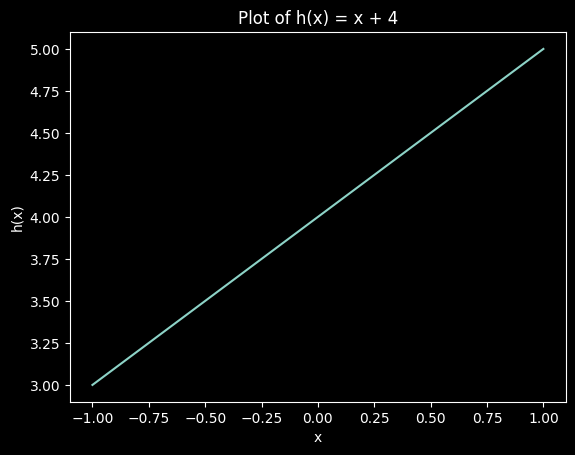

  0%|          | 0/3212 [00:00<?, ?it/s]

,exp_id,text,input_tokens,output_tokens,code_counter,code_snippet,code_output,error
0,Exp0002,<math_problem>Which is the smallest whole numb...,17687.0,105.0,0,None,None,None
1,Exp0004,<math_problem>Write the successor of $2440701$...,17702.0,93.0,1,print(2440701 + 1),2440702,None
2,Exp0005,<math_problem>Write the successor of $100199$....,17698.0,89.0,1,print(100199 + 1),100200,None
3,Exp0006,<math_problem>Write the successor of $1099999$...,17702.0,93.0,1,print(1099999 + 1),1100000,None
4,Exp0003,<math_problem>How many whole numbers are there...,17800.0,216.0,1,from sympy import Rational\n\n# Define value\n...,20,None
...,...,...,...,...,...,...,...,...
3207,Exp4325,<math_problem>If $A$ and $B$ are any two event...,17745.0,304.0,0,None,None,None
3208,Exp4293,<math_problem>A class has $15$ students whose ...,18704.0,915.0,1,"age = [14, 15, 16, 17, 18, 19, 20 ,21]\nprobab...","NameError(""name 'age' is not defined"")",NameError
3209,Exp4320,<math_problem>Assume that the chances of the p...,17826.0,585.0,1,from sympy import Rational\n\n# Define values\...,14/29,None
3210,Exp4322,<math_problem>An electronic assembly consists ...,17879.0,414.0,1,print(0.15 / 0.3),0.5,None


In [358]:
interim_df = pd.read_json(interim_fname, lines=True, orient='records')
interim_df['code_counter'] = interim_df.text.progress_apply(lambda x: x.count('<code>') if x is not None else 0)
interim_df['code_snippet'] = interim_df.progress_apply(lambda x: re.findall(r'<code>(.*?)</code>', x.text, re.DOTALL)[0] if x.code_counter > 0 else None, axis=1)
interim_df['code_output'] = interim_df.code_snippet.progress_apply(lambda x: python_repl.run(x).strip() if x is not None else None)
interim_df['error'] = interim_df.code_output.progress_apply(lambda x: re.search(r'(.*)Error', x).group(1) + "Error" if x is not None and x.count('Error') > 0 else None)
interim_df

In [360]:
interim_df.error.value_counts()

error
TypeError              31
AttributeError         12
ImportError             8
NameError               7
IndentationError        1
ValueError              1
IndexError              1
NotImplementedError     1
ShapeError              1
Name: count, dtype: int64

In [319]:
idx = 3211
output = interim_df.text[idx]
# print(output)
# print()

# Extract Problem
problem = re.search(r'<math_problem>(.*?)</math_problem>', output, re.DOTALL).group(1)

# Extract Steps
steps = re.findall(r'<code>(.*?)</code>', output, re.DOTALL)
print(steps[0])

from sympy import Rational

# Define the probabilities
probs = {2: Rational(1, 36), 3: Rational(1, 18), 4: Rational(1, 12), 5: Rational(1, 9), 6: Rational(5, 36), 7: Rational(1, 6), 8: Rational(5, 36), 9: Rational(1, 9), 10: Rational(1, 12), 11: Rational(1, 18), 12: Rational(1, 36)}

# Calculate the expected value
expected_value = sum([key * value for key, value in probs.items()])
print(expected_value)


In [339]:
interim_df.code_output[789]

"TypeError('invalid input: z')"

In [357]:
code_output = 'AttributeError("\'int\' object has no attribute \'is_commutative\'")'
code_output = "TypeError('invalid input: z')"
# Extract Error Name if any,
error_name = re.search(r'(.*)Error', code_output).group(1)
error_name

'Type'

In [365]:
print(interim_df.text[0])

<math_problem>Which is the smallest whole number?</math_problem>
<start_of_step>1
As the definition of whole numbers is not given, we assume:
- Whole numbers defined as the set of non-negative integers: $\{0, 1, 2, 3, \cdots\}$.<end_of_step>
<start_of_step>2
Hence, the smallest whole number is $\boxed{0}$.<end_of_step>



In [469]:
def get_messages(parsed_text:str) -> List[Dict[str, str]]:

    messages = []
    
    # Extract the Problem
    problem = re.search(r'<math_problem>(.*?)</math_problem>', parsed_text, re.DOTALL).group(1)
    messages.append({
        'role': 'problem',
        'content': problem
    })

    # Extract all the Steps
    steps = re.findall(r'<start_of_step>\d+\n(.*?)<end_of_step>', parsed_text, re.DOTALL)

    # Extract the incomplete step
    if '<code_input_block>' in parsed_text:
        start_index = parsed_text.rfind('<start_of_step>')
        incomplete_step = re.search(r'<start_of_step>\d+\n(.*?)</code_input_block>', parsed_text[start_index:], re.DOTALL).group(1)
        steps.append(incomplete_step + '</code_input_block>')

    for step in steps:

        # Extract the text before the code block
        if '<code_input_block>' not in step:
            messages.append({
                'role': 'step',
                'content': [
                    {
                        'role': 'text',
                        'content': step
                    }
                ]
            })
            continue
        else:
            text_before_code = re.search(r'(.*?)<code_input_block>', step, re.DOTALL).group(1)
            codes = re.findall(r'<code>(.*?)</code>', step, re.DOTALL)
            
            messages.append(
                {
                    'role': 'step',
                    'content': [
                        {
                            'role': 'text',
                            'content': text_before_code
                        },
                        *[{
                            'role': 'code',
                            'content': code
                        } for code in codes],
                        {
                            'role': 'code_output',
                            'content': [python_repl.run(code).strip() for code in codes]
                        }
                    ]
                }
            )

    return messages

In [493]:
def replace_second_occurrence(text):
    parts = text.split('<math_problem>', 2)
    if len(parts) < 3:
        return text  # No replacement needed
    return '<math_problem>'.join(parts[:2]) + '</math_problem>' + parts[2]

def replace_nth_occurrence(text, old, new, n):
    parts = text.split(old, n)
    if len(parts) < n+1:
        return text  # No replacement needed
    return old.join(parts[:n]) + new + parts[n]

unicode_remapping = {
    "≅": r"\cong",
    "≠": r"\neq",
    "≡": r"\equiv",
    "≤": r"\leq",
    "≥": r"\geq",
    "⊥": r"\perp",
    "⊂": r"\subset",
    "⊆": r"\subseteq",
    "⊇": r"\supseteq",
    "⊕": r"\oplus",
    "⊗": r"\otimes",
    "∩": r"\cap",
    "∴": r"\therefore",
    "”": r"\"",
    "‘": r"'",
    "“": r"\"",
    "\xad": r"-",
    "–": r"-",
    "º": r"\degree",
    "°": r"\degree",
    "θ": r"\theta",
    "∞": r"\infty",
    "□": r"\square",
    "Σ": r"\Sigma",
    "…": r"\cdots",
    "³": r"^3",
    "′": r"'",
    "⇒": r"\implies",
    "×": r"\times",
    "Δ": r"\Delta",
    "σ": r"\sigma",
    "∆": r"\Delta",
    "÷": r"\div",
    "☐": r"\square",
    "Φ": r"\phi",
    "∠": r"\angle",
    "∵": r"\because",
    "±": r"\pm",
    "↔": r"\Leftrightarrow",
    "π": r"\pi",
    "²": r"^2",
    "μ": r"\mu",
    "≈": r"\approx",
    "₹": r"Rs.",
    "’": r"'",
}

new_unicode_remapping = {
    '\u2245': r'\cong',
    '\u22a5': r'\perp',
    '\u2229': r'\cap',
    '\u2234': r'\therefore',
    '\u201d': r'\"',
    '\u2018': r"'",
    '\u201c': r'\"',
    '\xad': r'-',
    '\xba': r'\degree',
    '\u2260': r'\neq',
    '\u03b8': r'\theta',
    '\u221e': r'\infty',
    '\u25a1': r'\square',
    '\u03a3': r'\Sigma',
    '\u2026': r'\cdots',
    '\xb3': r'^3',
    '\xb0': r'\degree',
    '\u2032': r"'",
    '\u21d2': r'\implies',
    '\xd7': r'\times',
    '\u0394': r'\Delta',
    '\u03c3': r'\sigma',
    '\u2206': r'\Delta',
    '\xf7': r'\div',
    '\u2610': r'\square',
    '\u2265': r'\geq',
    '\u03a6': r'\phi',
    '\u2220': r'\angle',
    '\u2235': r'\because',
    '\xb1': r'\pm',
    '\u2194': r'\Leftrightarrow',
    '\u03c0': r'\pi',
    '\xb2': r'^2',
    '\u2013': r'-',
    '\u03bc': r'\mu',
    '\u2248': r'\approx',
    '\u20b9': r'Rs.',
    '\u2264': r'\leq',
    '\u2019': r"'",
    '\u2212': r'-',
}


In [507]:
exp_id = 'Exp0239'
parsed_text = interim_df[interim_df['exp_id'] == exp_id].text.values[0]
# parsed_text = interim_df.text[2695]
print(parsed_text)

# Remove Excess space after step number if any
parsed_text = re.sub(r'(<start_of_step>\d+)\s+', r'\1\n', parsed_text, re.DOTALL)

# Replace Unicode Characters, if any
for key, value in new_unicode_remapping.items():
    parsed_text = parsed_text.replace(key, value)

# <math_problem> appears twice in the text, then replace only the second occurence with </math_problem> tag
if parsed_text.count('<math_problem>') > 1:
    parsed_text = replace_nth_occurrence(parsed_text, '<math_problem>', '</math_problem>', 2)

if parsed_text.count('</code_input_block>') > 1:
    parsed_text = replace_nth_occurrence(parsed_text, '</code_input_block>', '<code_input_block>', 1)

if parsed_text.count('<code_input_block>') == 0 and parsed_text.count('</code_input_block>') == 1:
    parsed_text = parsed_text.replace('</code_input_block>', '<end_of_step>')


if '</start_of_step>' in parsed_text:
    parsed_text = parsed_text.replace('</start_of_step>', '<end_of_step>')

if parsed_text.count('<math_problem>') > 1:
    parsed_text = replace_second_occurrence(parsed_text)

print(parsed_text)
# print(repr(parsed_text))
get_messages(parsed_text)

<math_problem>Use the number line and add the following integers: $(−1) + (−2) + (−3)$. </math_problem>
<start_of_step>1. **Start at 0.**
<start_of_step>2. **Move 1 step to the left** to represent -1.
<start_of_step>3. **From the new position, move 2 steps to the left** to represent -2.
<start_of_step>4. **From the new position, move 3 steps to the left** to represent -3.
<start_of_step>5. **The final position on the number line represents the sum.**

Therefore, $(−1) + (−2) + (−3) = \boxed{-6}$.</start_of_step> 

<math_problem>Use the number line and add the following integers: $(-1) + (-2) + (-3)$. </math_problem>
<start_of_step>1. **Start at 0.**
<start_of_step>2. **Move 1 step to the left** to represent -1.
<start_of_step>3. **From the new position, move 2 steps to the left** to represent -2.
<start_of_step>4. **From the new position, move 3 steps to the left** to represent -3.
<start_of_step>5. **The final position on the number line represents the sum.**

Therefore, $(-1) + (-2) 

[{'role': 'problem',
  'content': 'Use the number line and add the following integers: $(-1) + (-2) + (-3)$. '}]

  0%|          | 0/3212 [00:00<?, ?it/s]

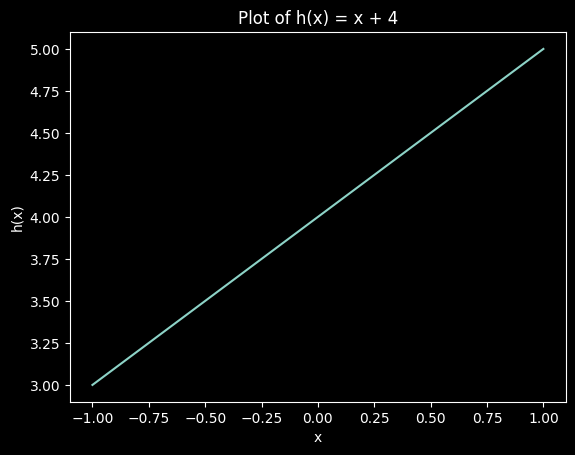

In [506]:
for idx in tqdm(interim_df.index):
    exp_id = interim_df.exp_id[idx]
    parsed_text = interim_df.text[idx]

    if parsed_text is None:
        continue

    # Remove Excess space after step number if any
    parsed_text = re.sub(r'(<start_of_step>\d+)\s+', r'\1\n', parsed_text, re.DOTALL)

    # Replace Unicode Characters, if any
    for key, value in new_unicode_remapping.items():
        parsed_text = parsed_text.replace(key, value)

    # <math_problem> appears twice in the text, then replace only the second occurence with </math_problem> tag
    if parsed_text.count('<math_problem>') > 1:
        parsed_text = replace_nth_occurrence(parsed_text, '<math_problem>', '</math_problem>', 2)

    if parsed_text.count('</code_input_block>') > 1:
        parsed_text = replace_nth_occurrence(parsed_text, '</code_input_block>', '<code_input_block>', 1)

    if parsed_text.count('<code_input_block>') == 0 and parsed_text.count('</code_input_block>') == 1:
        parsed_text = parsed_text.replace('</code_input_block>', '<end_of_step>')


    
    if '</start_of_step>' in parsed_text:
        parsed_text = parsed_text.replace('</start_of_step>', '<end_of_step>')

    try:
        messages = get_messages(parsed_text)
    except Exception:
        print(f"Error at index {idx}")
        break

    with open(os.path.join(FOLDER_PATH, f'{exp_id}.json'), 'w') as f:
        json.dump(messages, f, indent=4)

## Test

In [513]:
fnames = os.listdir(FOLDER_PATH)
cleaned_fnames = [fname for fname in fnames if fname.startswith('Cleaned_')]
len(cleaned_fnames)

94

In [515]:
with open('chat_template.txt', 'r') as f:
    chat_template = f.read()
    gemma_tokenizer.chat_template = chat_template

In [660]:
idx = 93
exp_id = cleaned_fnames[idx].split('.')[0][8:]
print(exp_id)

with open(os.path.join(FOLDER_PATH, cleaned_fnames[idx]), 'r') as f:
    messages = json.load(f)

problem = df[df['id'] == exp_id].problem.values[0]
hints = df[df['id'] == exp_id].solution.values[0]

# Strip and remove multiple new lines if any
problem = re.sub(r'\n+', '\n', problem).strip()
hints = re.sub(r'\n+', '\n', hints).strip()

print(f"<START_OF_INPUTS>\n<PROBLEM>{problem}\n</PROBLEM>\n\n<HINTS>\n{hints}\n</HINTS>\n<END_OF_INPUTS>\n")

print(gemma_tokenizer.apply_chat_template(messages, tokenize=False)[5:])


Exp0689
<START_OF_INPUTS>
<PROBLEM>Use the sign of >, < or = in the box to make the statements true. 23 – 41 + 11 23 – 41 – 11
</PROBLEM>

<HINTS>
23 - 41 + 11 23- 41 - 11
⇒ -7 >- 29
</HINTS>
<END_OF_INPUTS>

<math_problem>Use the sign of $>$, $<$ or $=$ in the box to make the statements true. $23 - 41 + 11 \boxed{} 23 - 41 - 11$</math_problem>
<start_of_step>1
Evaluating the left hand side:<code_input_block>
<code>print(23 - 41 + 11)</code>
</code_input_block>
<code_output_block>
-7
</code_output_block><end_of_step>



In [566]:
print(r"""<math_problem>A vendor supplies $32$ litres of milk to a hotel in the morning and $68$ litres of milk in the evening. If the milk costs Rs. $15$ per litre, how much money is due to the vendor per day?</math_problem>
<start_of_step>1
The total quantity of milk supplied per day is given by: $32+68 =$<code_input_block>
<code>print(32 + 68)</code>
</code_input_block>
<code_output_block>
100
</code_output_block>
Hence, the total quantity of milk supplied per day is $100$ litres<end_of_step>
<start_of_step>2
The cost of $1$ litre of milk is Rs.$15$.
Therefore, the total cost of milk per day is given by: $100 \times 15 =$<code_input_block>
print(100 * 15)
</code_input_block>
<code_output_block>
1500
</code_output_block>
Hence, the total cost of milk supplied per day is Rs.$1500$<end_of_step>
<final_answer>1500</final_answer>
""")

<math_problem>A vendor supplies $32$ litres of milk to a hotel in the morning and $68$ litres of milk in the evening. If the milk costs Rs. $15$ per litre, how much money is due to the vendor per day?</math_problem>
<start_of_step>1
The total quantity of milk supplied per day is given by: $32+68 =$<code_input_block>
<code>print(32 + 68)</code>
</code_input_block>
<code_output_block>
100
</code_output_block>
Hence, the total quantity of milk supplied per day is $100$ litres<end_of_step>
<start_of_step>2
The cost of $1$ litre of milk is Rs.$15$.
Therefore, the total cost of milk per day is given by: $100 \times 15 =$<code_input_block>
print(100 * 15)
</code_input_block>
<code_output_block>
1500
</code_output_block>
Hence, the total cost of milk supplied per day is Rs.$1500$<end_of_step>
<final_answer>1500</final_answer>



## Gemini solving math problems using Few Shot Examples

### Prep for Few Shot Examples

In [17]:
df = pd.read_json(
    os.path.join(BASE_FOLDER, "preprocess_input.jsonl"), lines=True, orient="records"
)

In [51]:
history = [
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Which is the smallest whole number?\n</PROBLEM>\n\n<HINTS>0 (zero) is the smallest whole number. All the natural numbers along with 0 are called whole numbers.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Which is the smallest whole number?</math_problem>\n<start_of_step>1\nAs the definition of whole numbers is not given, we assume:\n- Whole numbers defined as the set of non-negative integers: $\\{0, 1, 2, 3, \\ldots\\}$.<end_of_step>\n<start_of_step>2\nHence, the smallest whole number is $\\boxed{0}$.<end_of_step>\n<final_answer>0</final_answer>",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>How many whole numbers are there between 32 and 53?\n</PROBLEM>\n\n<HINTS>Whole numbers between 32 and 53 = 20 (53 − 32 − 1 = 20)\n(33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52)\n∴ There are 20 whole numbers between 32 and 53.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>How many whole numbers are there between $32$ and $53$?</math_problem>\n<start_of_step>1\nThe whole numbers between $32$ and $53$ are $33, 34, 35, \\dots, 52$.<end_of_step>\n<start_of_step>2\nThis is an arithmetic sequence with first term $a = 33$ and common difference $d = 1$.<end_of_step>\n<start_of_step>3\nThe number of terms in this sequence is given by $n = \\frac{l-a}{d}+1 = \\frac{52-33}{1} + 1 =$<code_input_block>\n<code>from sympy import Rational\n\n# Define value\nvalue = Rational(52 - 33, 1) + 1\nprint(value)</code>\n</code_input_block>\n<code_output_block>\n20\n</code_output_block>\nHence, there are $\\boxed{20}$ whole numbers between $32$ and $53$.\n<end_of_step>\n<final_answer>20</final_answer>",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Write the successor of 2440701.\n</PROBLEM>\n\n<HINTS>The successor of 2440701 is\n2440701 + 1 = 2440702\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Write the successor of $2440701$.</math_problem>\n<start_of_step>1\nSuccessor of $2440701$ is given by: $2440701 + 1=$<code_input_block>\n<code>print(2440701 + 1)</code>\n</code_input_block>\n<code_output_block>\n2440702\n</code_output_block>\nHence the successor of $2440701$ is $\\boxed{2440702}$<end_of_step>\n<final_answer>2440702</final_answer>",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Write the successor of 100199.\n</PROBLEM>\n\n<HINTS>Successor of 100199 is\n100199 + 1 = 100200\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Write the successor of $100199$.</math_problem>\n<start_of_step>1\nThe successor of a number is the next number in the sequence. To find the successor, we simply add $1$ to the given number.\nTherefore, the successor of $100199$ is $100199 + 1 =$<code_input_block>\n<code>print(100199 + 1)</code>\n</code_input_block>\n<code_output_block>\n100200\n</code_output_block>\nHence the successor of $100199$ is $\\boxed{100200}$<end_of_step>\n<final_answer>100200</final_answer>",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Write the predecessor of 94.\n</PROBLEM>\n\n<HINTS>The predecessor of 94 is\n94 − 1 = 93\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Write the predecessor of $94$.</math_problem>\n<start_of_step>1\nThe predecessor of a number is the number that comes before it. To find the predecessor, we simply subtract $1$ from the given number.\nTherefore, the predecessor of $94$ is $94 - 1 =$<code_input_block>\n<code>print(94 - 1)</code>\n</code_input_block>\n<code_output_block>\n93\n</code_output_block>\nHence the predecessor of $94$ is $\\boxed{93}$<end_of_step>\n<final_answer>93</final_answer>\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>In the following pairs of numbers, a state in which the whole number is on the left of the other number is on the number line. Also write it with the appropriate sign $(\\gt, \\lt)$ between them. $530, 503$\n</PROBLEM>\n\n<HINTS>\nExplanation:\n530, 503\nAs 530 > 503,\n503 is on the left side of 530 on the number line.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>In the following pairs of numbers, a state in which the whole number is on the left of the other number is on the number line. Also write it with the appropriate sign $(\\gt, \\lt)$ between them. \n$530$ , $503$</math_problem>\n<start_of_step>1\nWe know that $\\boxed{530 \\gt 503}$, hence $503$ is on the left side of $530$ on the number line.<end_of_step>\n<final_answer>$530 \\gt 503$</final_answer>",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Find the sum by suitable rearrangement: 837 + 208 + 363\n</PROBLEM>\n\n<HINTS>837 + 208 + 363\n= (837 + 363) + 208\n= 1200 + 208\n= 1408\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Find the sum by suitable rearrangement: $837 + 208 + 363$</math_problem>\n<start_of_step>1\nLets perform the calculation: $837 + 208 + 363=$<code_input_block>\n<code>print(837 + 208 + 363)</code>\n</code_input_block>\n<code_output_block>\n1408\n</code_output_block>\nTherefore, $837 + 208 + 363=\\boxed{1408}$<end_of_step>\n<final_answer>1408</final_answer>",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>A vendor supplies 32 litres of milk to a hotel in the morning and 68 litres of milk in the evening. If the milk costs ₹ 15 per litre, how much money is due to the vendor per day?\n</PROBLEM>\n\n<HINTS>Quantity of milk supplied in the morning = 32 l\nQuantity of milk supplied in the evening = 68 l\nTotal of milk per litre = (32 + 68) l\nCost of milk per litre = ₹ 15\nTotal cost per day = 15 × (32 + 68)\n= 15 × 100\n= ₹ 1500\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>A vendor supplies $32$ litres of milk to a hotel in the morning and $68$ litres of milk in the evening. If the milk costs Rs. $15$ per litre, how much money is due to the vendor per day?</math_problem>\n<start_of_step>1\nThe total quantity of milk supplied per day is given by: $32+68 =$<code_input_block>\n<code>print(32 + 68)</code>\n</code_input_block>\n<code_output_block>\n100\n</code_output_block>\nHence, the total quantity of milk supplied per day is $\\boxed{100}$ litres<end_of_step>\n<start_of_step>2\nThe cost of $1$ litre of milk is Rs.$15$.\nTherefore, the total cost of milk per day is given by: $100 \\times 15 =$<code_input_block>\nprint(100 * 15)\n</code_input_block>\n<code_output_block>\n1500\n</code_output_block>\nHence, the total cost of milk supplied per day is Rs.$\\boxed{1500}$<end_of_step>\n<final_answer>1500</final_answer>",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>The smallest even number is ______.\n</PROBLEM>\n\n<HINTS>The smallest even number is 2.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>The smallest even number is ______.</math_problem>\n<start_of_step>1\nAn even number is a number that is divisible by $2$.<end_of_step>\n<start_of_step>2\nThe smallest positive integer that is divisible by $2$ is $2$.<end_of_step>\n<start_of_step>3\nTherefore, the smallest even number is $\\boxed{2}$.<end_of_step>\n<final_answer>2</final_answer>\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Find the HCF of the following numbers: 27, 63\n</PROBLEM>\n\n<HINTS>27 = 3 × 3 × 3\n63 = 3 × 3 × 7\nHCF = 3 × 3 = 9\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Find the HCF of the following numbers: $27, 63$</math_problem>\n<start_of_step>1\nWe can use the `gcd` function from `math` to calculate the HCF (greatest common divisor).<code_input_block>\n<code>from math import gcd\nprint(gcd(27, 63))</code>\n</code_input_block>\n<code_output_block>\n9\n</code_output_block>\nHence, the HCF of $27, 63$ is $\\boxed{9}$<end_of_step>\n<final_answer>9</final_answer>\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Find the product by suitable rearrangement: 2 × 1768 × 50\n</PROBLEM>\n\n<HINTS>2 × 1768 × 50\n= 2 × 50 × 1768\n= 100 × 1768\n= 176800\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Find the product by suitable rearrangement: $2 \\times 1768 \\times 50$.</math_problem>\n<start_of_step>1\nLets perform the calculation: $2 \\times 50 \\times 1768=$<code_input_block>\n<code>print(2 * 50 * 1768)</code>\n</code_input_block>\n<code_output_block>\n176800\n</code_output_block>\nTherefore, $2 \\times 1768 \\times 50 = \\boxed{176800}$<end_of_step>\n<final_answer>176800</final_answer>\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Find the product using suitable properties. 738 × 103\n</PROBLEM>\n\n<HINTS>738 × 103\n= 738 × (100 + 3)\n= 738 × 100 + 738 × 3 ...(Distributive property)\n= 73800 + 2214\n= 76014\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Find the product using suitable properties. $738 \\times 103$</math_problem>\n<start_of_step>1\nLets perform the calculation: $738 \\times 103=$<code_input_block>\n<code>print(738 * 103)</code>\n</code_input_block>\n<code_output_block>\n76014\n</code_output_block>\nTherefore, $738 \\times 103 = \\boxed{76014}$<end_of_step>\n<final_answer>76014</final_answer>\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>A taxi driver filled his car petrol tank with 40 litres of petrol on Monday. The next day, he filled the tank with 50 litres of petrol. If petrol costs ₹ 44 per litre, how much did he spend in all on petrol?\n</PROBLEM>\n\n<HINTS>Quantity of petrol filled on Monday = 40 l\nQuantity of petrol filled on Tuesday = 50 l\nTotal quantity filled = (40 + 50) l\nCost of petrol (per l) = ₹ 44\nTotal money spent = 44 × (40 + 50)\n= 44 × 90\n= ₹ 3960\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>A taxi driver filled his car petrol tank with $40$ litres of petrol on Monday. The next day, he filled the tank with $50$ litres of petrol. If petrol costs Rs. $44$ per litre, how much did he spend in all on petrol?</math_problem>\n<start_of_step>1\nThe total quantity of petrol filled is given by: $40+50 =$<code_input_block>\n<code>print(40 + 50)</code>\n</code_input_block>\n<code_output_block>\n90\n</code_output_block>\nHence, the total quantity of petrol filled is $\\boxed{90}$ litres<end_of_step>\n<start_of_step>2\nThe cost of $1$ litre of petrol is Rs.$44$.\nTherefore, the total cost of petrol is given by: $90 \\times 44 =$<code_input_block>\nprint(90 * 44)\n</code_input_block>\n<code_output_block>\n3960\n</code_output_block>\nHence, the total cost of petrol is Rs.$\\boxed{3960}$<end_of_step>\n<final_answer>3960</final_answer>\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>If the product of two whole numbers is 1, can we say that one or both of them will be 1? Justify through examples.\n</PROBLEM>\n\n<HINTS>If the product of 2 numbers is 1, then both the numbers have to be equal to 1.\nFor example, 1 × 1 = 1\nHowever, 1 × 6 = 6\nClearly, the product of two whole numbers will be 1 in the situation when both numbers to be multiplied are 1.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>If the product of two whole numbers is $1$, can we say that one or both of them will be $1$? Justify through examples.</math_problem>\n<start_of_step>1\nYes, if the product of two whole numbers is $1$, then both of them must be equal to $1$.<end_of_step>\n<start_of_step>2\nHere's why:\n- The only way to get a product of $1$ is to multiply $1$ by itself.\n- Any other whole number multiplied by $1$ will result in a product greater than $1$.<end_of_step>\n<start_of_step>3\n**Examples:**\n- $1 \\times 1 = 1$\n- $2 \\times 1 = 2$\n- $3 \\times 1 = 3$\n- $10 \\times 1 = 10$\n- $100 \\times 1 = 100$\nAs we can see, the only way to get a product of $1$ is to multiply $1$ by itself. Therefore, if the product of two whole numbers is $1$, then both of them must be equal to $1$.<end_of_step>\n<final_answer>True</final_answer>\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Find using distributive property: 728 × 101\n</PROBLEM>\n\n<HINTS>728 × 101\n= 728 × (100 + 1)\n= 728 × 100 + 728 × 1\n= 72800 + 728\n= 73528\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Find using the distributive property: $728 \\times 101$.</math_problem>\n<start_of_step>1\nLets perform the calculation: $728 \\times 101=$<code_input_block>\n<code>print(728 * 101)</code>\n</code_input_block>\n<code_output_block>\n73528\n</code_output_block><end_of_step>\nTherefore, $728 \\times 101 = \\boxed{73528}$<end_of_step>\n<final_answer>73528</final_answer>\n\n\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Write all the factors of the following number. 23\n</PROBLEM>\n\n<HINTS>23 = 1 × 23,\n23 = 23 × 1\nThus, all factors of 23 are 1 and 23.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Find all the factors of $23$.</math_problem>\n<start_of_step>1\nWe can use the `divisors` function from `sympy` to get all the required factors.<code_input_block>\n<code>from sympy import divisors\nprint(divisors(23))</code>\n</code_input_block>\n<code_output_block>\n[1, 23]\n</code_output_block><end_of_step>\nThe factors of $23$ are $\\boxed{1, 23}$.<end_of_step>\n<final_answer>1, 23</final_answer>\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Is the given number prime? 37\n</PROBLEM>\n\n<HINTS>It has only two factors, 1 and 37.\nTherefore, it is a prime number.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Which of the following number is prime: 37</math_problem>\n<start_of_step>1\nA prime number is a natural number greater than 1 that has exactly two distinct positive divisors: 1 and itself.\nTo determine whether a number is prime or not we can make use of `isprime` function from `sympy` library<code_input_block>\n<code>from sympy import isprime\nprint(isprime(37))</code>\n</code_input_block>\n<code_output_block>\nTrue\n</code_output_block><end_of_step>\nTherefore, $37$ is a $\\boxed{\\text{prime number}}$.<end_of_step>\n<final_answer>True</final_answer>\n\n\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>1 is neither ______ nor ______.\n</PROBLEM>\n\n<HINTS>1 is neither prime number nor composite number.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>1 is neither ______ nor ______.</math_problem>\n<start_of_step>1\n$1$ is neither a prime number nor a composite number.<end_of_step>\n<final_answer>prime number, composite number</final_answer>\n\n\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Using the divisibility test, determine which of the following number is divisible by 4; by 8: 572\n</PROBLEM>\n\n<HINTS>572, its last two digits are divisible by 4, that is, this number is divisible by 4.\n572, its last three digits are not divisible by 8, that is, this number is not divisible by 8.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Using the divisibility test, determine which of the following numbers is divisible by $4$: $572$</math_problem>\n<start_of_step>1\nLets find the remainder of $572 \\div 4$<code_input_block>\n<code>print(572 % 4)</code>\n</code_input_block>\n<code_output_block>\n0\n</code_output_block>\nAs the remainder is $0$, the number $572$ is $\\boxed{\\text{divisible}}$ by $4$.\n<end_of_step>\n<final_answer>True</final_answer>\n\n\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Write a digit in the blank space of the following number so that the number formed is divisible by 11: 8 ______ 9484\n</PROBLEM>\n\n<HINTS>Let a be placed in the blank.\nSum of the digits at odd places = 4 + 4 + a = 8 + a\nSum of the digits at even places = 8 + 9 + 8 = 25\nDifference = 25 − (8 + a)\n= 17 − a\nFor a number to be divisible by 11, this difference should be zero or a multiple of 11.\nIf 17 − a = 0, then\na = 17\nThis is not possible.\nA multiple of 11 has to be taken. Taking 11, we obtain\n17 − a = 11\na = 6\nTherefore, the required digit is 6.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Write a digit in the blank space of the following number so that the number formed is divisible by $11$: $8$ ______ $9484$.</math_problem>\n<start_of_step>1\nLet the digit in the blank space be $x$.\nThe number is $8x9484$.<end_of_step>\n<start_of_step>2\nFor a number to be divisible by $11$, the difference between the sum of the digits at odd places and the sum of the digits at even places must be either $0$ or a multiple of $11$.<end_of_step>\n<start_of_step>3\nSum of digits at odd places: $4 + 4 + x = 8 + x$\nSum of digits at even places: $8 + 9 + 8 = 25$\nDifference: $25 - (8 + x) = 17 - x$<end_of_step>\n<start_of_step>4\nFor the number to be divisible by $11$, $17 - x$ must be $0$ or a multiple of $11$.\nIf $17 - x = 0$, then $x = 17$, which is not possible as $x$ must be a single digit.\nThe next multiple of $11$ is $11$.\nSo, $17 - x = 11$\n$x = 17 - 11 = 6$\nTherefore, the required digit is $\\boxed{6}$.<end_of_step>\n<final_answer>6</final_answer>\n\n\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Which of the following numbers is co-prime? 15 and 37\n</PROBLEM>\n\n<HINTS>Factors of 15 = 1, 3, 5, 15\nFactors of 37 = 1, 37\nWe know that two numbers with common factor is only 1 are called co-prime numbers.\nThe common factor of 15 and 37 is only 1.\nThus, these are co-prime numbers.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Which of the following numbers is co-prime: $15$ and $37$</math_problem>\n<start_of_step>1\nTwo numbers are said to be co-prime if their greatest common divisor (GCD) is $1$.<end_of_step>\n<start_of_step>2\nWe can use the `gcd` function from `math` to calculate the GCD.<code_input_block>\n<code>from math import gcd\nprint(gcd(15, 37))</code>\n</code_input_block>\n<code_output_block>\n1\n</code_output_block>\nThe GCD of $15$ and $37$ is $1$.<end_of_step>\n<start_of_step>3\nTherefore, $15$ and $37$ are $\\boxed{\\text{co-prime}}$.<end_of_step>\n<final_answer>True</final_answer>\n\n\n\n\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Write the greatest 4-digit number and express it in terms of its prime factors.\n</PROBLEM>\n\n<HINTS>Greatest four-digit number = 9999\n9999 = 3 × 3 × 11 × 101\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Write the greatest $4$-digit number and express it in terms of its prime factors.</math_problem>\n<start_of_step>1\nThe greatest $4$-digit number is $9999$.<end_of_step>\n<start_of_step>2\nWe can use the `factorint` function from `sympy` to get the prime factorization of the number.<code_input_block>\n<code>from sympy import factorint\nprint(factorint(9999))</code>\n</code_input_block>\n<code_output_block>\n{3: 2, 11: 1, 101: 1}\n</code_output_block>\nTherefore, the prime factorization of $9999$ is $3^2 \\times 11 \\times 101$.<end_of_step>\n<final_answer>$9999 = 3^2 \\times 11 \\times 101$</final_answer>\n\n\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Find all the prime factors of 1729 and arrange them in ascending order. Now state the relation, if any; between two consecutive prime factors.\n</PROBLEM>\n\n<HINTS>1729 = 7 × 13 × 19\n13 − 7 = 6, 19 − 13 = 6\nThe difference between the two consecutive prime factors is 6.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Find all the prime factors of $1729$ and arrange them in ascending order. Now state the relation, if any; between two consecutive prime factors.</math_problem>\n<start_of_step>1\nWe can use the `factorint` function from `sympy` to get the prime factorization of the number.<code_input_block>\n<code>from sympy import factorint\nprint(factorint(1729))</code>\n</code_input_block>\n<code_output_block>\n{7: 1, 13: 1, 19: 1}\n</code_output_block>\nTherefore, the prime factorization of $1729$ is $7 \\times 13 \\times 19$.<end_of_step>\n<start_of_step>2\nArranging the prime factors in ascending order, we get: $7, 13, 19$.<end_of_step>\n<start_of_step>3\nThe difference between the two consecutive prime factors is $13 - 7 = 6$ and $19 - 13 = 6$.<end_of_step>\n<final_answer>6</final_answer>\n\n\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Determine if 25110 is divisible by 45. [Hint: 5 and 9 are co-prime numbers. Test the divisibility of the numbers 5 and 9].\n</PROBLEM>\n\n<HINTS>45 = 5 × 9\nFactors of 5 = 1, 5\nFactors of 9 = 1, 3, 9\nTherefore, 5 and 9 are co-prime numbers.\nSince the last digit of 25110 is 0, it is divisible by 5.\nSum of the digits of 25110 = 2 + 5 + 1 + 1 + 0 = 9\nAs the sum of the digits of 25110 is divisible by 9, therefore, 25110 is divisible by 9.\nSince the number is divisible by 5 and 9 both, it is divisible by 45.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Determine if $25110$ is divisible by $45$.</math_problem>\n<start_of_step>1\nLets calculate the remainder of $25110 \\div 45$<code_input_block>\n<code>print(25110 % 45)</code>\n</code_input_block>\n<code_output_block>\n0\n</code_output_block>\nAs the remainder is $0$, $25110$ is divisible by $45$.<end_of_step>\n<final_answer>True</final_answer>\n\n\n\n\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>18 is divisible by both 2 and 3. It is also divisible by 2 × 3 = 6. Similarly, a number is divisible by both 4 and 6. Can we say that the number must also be divisible by 4 × 6 = 24? If not, give an example to justify your answer.\n</PROBLEM>\n\n<HINTS>No. It is not necessary because 12 and 36 are divisible by 4 and 6 both, but are not divisible by 24.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>18 is divisible by both 2 and 3. It is also divisible by $2 \\times 3 = 6$. Similarly, a number is divisible by both 4 and 6. Can we say that the number must also be divisible by $4 \\times 6 = 24$? If not, give an example to justify your answer.</math_problem>\n<start_of_step>1\nNo, we cannot say that a number divisible by both $4$ and $6$ must also be divisible by $24$.<end_of_step>\n<start_of_step>2\n**Example:**\nThe number $12$ is divisible by both $4$ and $6$, but it is not divisible by $24$.<end_of_step>\n<final_answer>False</final_answer>\n\n\n\n\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Find the HCF of the following numbers: 70, 105, 175\n</PROBLEM>\n\n<HINTS>70 = 2 × 5 × 7\n105 = 3 × 5 × 7\n175 = 5 × 5 × 7\nHCF = 5 × 7 = 35\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Find the HCF of the following numbers: $70, 105, 175$</math_problem>\n<start_of_step>1\nWe can use the `gcd` function from `math` to calculate the HCF (greatest common divisor).<code_input_block>\n<code>from math import gcd\nprint(gcd(70, 105, 175))</code>\n</code_input_block>\n<code_output_block>\n35\n</code_output_block>\nHence, the HCF of $70, 105, 175$ is $\\boxed{35}$<end_of_step>\n<final_answer>35</final_answer>\n\n\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>What is the HCF of two consecutive numbers?\n</PROBLEM>\n\n<HINTS>HCF of two consecutive numbers is 1.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>What is the HCF of two consecutive numbers?</math_problem>\n<start_of_step>1\nConsecutive numbers differ by $1$.  This means they have no common factors other than $1$.  \n<end_of_step>\n<start_of_step>2\nSince the greatest common factor (HCF) is the largest number that divides into both numbers, the HCF of two consecutive numbers is always $1$.\n<end_of_step>\n<final_answer>1</final_answer>",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Renu purchases two bags of fertilizer of weights 75 kg and 69 kg. Find the maximum value of weight which can measure the weight of the fertilizer the exact number of times.\n</PROBLEM>\n\n<HINTS>Weight of the two bags = 75 kg and 69 kg\nMaximum weight = HCF (75, 69)\n75 = 3 × 5 × 5\n69 = 3 × 23\nHCF = 3\nHence, the maximum value of the weight, which can measure the weight of the fertilizer an exact number of times, is 3 kg.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Renu purchases two bags of fertilizer of weights $75$ kg and $69$ kg. Find the maximum value of weight which can measure the weight of the fertilizer the exact number of times.</math_problem>\n<start_of_step>1\nThe maximum value of weight that can measure the weight of the fertilizer an exact number of times is the HCF (Highest Common Factor) of $75$ and $69$.<end_of_step>\n<start_of_step>2\nWe can use the `gcd` function from `math` to calculate the HCF (greatest common divisor).<code_input_block>\n<code>from math import gcd\nprint(gcd(75, 69))</code>\n</code_input_block>\n<code_output_block>\n3\n</code_output_block>\nThe HCF of $75$ and $69$ is $3$.\nHence, the maximum value of the weight, which can measure the weight of the fertilizer an exact number of times, is $3$ kg.<end_of_step>\n<final_answer>3</final_answer>",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Three boys step off together from the same spot. Their steps measure 63 cm, 70 cm, and 77 cm respectively. What is the minimum distance each should cover so that all can cover the distance in complete steps?\n</PROBLEM>\n\n<HINTS>Step measure of 1st Boy = 63 cm\nStep measure of 2nd Boy = 70 cm\nStep measure of 3rd Boy = 77 cm\nLCM of 63, 70, 77\nLCM = 2 × 3 × 3 × 5 × 7 × 11 = 6930\nHence, the minimum distance each should cover so that all can cover the distance in complete steps is 6930 cm.\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Three boys step off together from the same spot. Their steps measure $63$ cm, $70$ cm, and $77$ cm respectively. What is the minimum distance each should cover so that all can cover the distance in complete steps?</math_problem>\n<start_of_step>1\nThe minimum distance each should cover so that all can cover the distance in complete steps is the LCM (Least Common Multiple) of $63$, $70$, and $77$.<end_of_step>\n<start_of_step>2\nWe can use the `lcm` function from `math` to calculate the LCM.<code_input_block>\n<code>from math import lcm\nprint(lcm(63, 70, 77))</code>\n</code_input_block>\n<code_output_block>\n6930\n</code_output_block>\nThe LCM of $63$, $70$, and $77$ is $6930$.\nHence, the minimum distance each should cover so that all can cover the distance in complete steps is $6930$ cm.<end_of_step>\n<final_answer>6930</final_answer>\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Represent the following numbers as integers with appropriate signs. An aeroplane is flying at the height of two thousand metres above the ground.\n</PROBLEM>\n\n<HINTS>\n+2000 m\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Represent the following numbers as integers with appropriate signs. An aeroplane is flying at the height of two thousand metres above the ground.</math_problem>\n<start_of_step>1\nSince the aeroplane is flying above the ground, we use a positive sign to represent its height.\nTherefore, the height of the aeroplane can be represented as $\\boxed{+2000}$ m.<end_of_step>\n<final_answer>$+2000$</final_answer>\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Find the sum of: –52 and 52\n</PROBLEM>\n\n<HINTS>\n(–52) + (+52) = 0 ...[∵ (–a) + (+a) = 0]\n</HINTS>\n<END_OF_INPUTS>\n",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Find the sum of: $-52$ and $52$</math_problem>\n<start_of_step>1\nLets perform the calculation: $-52 + 52=$<code_input_block>\n<code>print(-52 + 52)</code>\n</code_input_block>\n<code_output_block>\n0\n</code_output_block>\nTherefore, $-52 + 52 = \\boxed{0}$<end_of_step>\n<final_answer>0</final_answer>\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>In a quiz, positive marks are given for correct answers and negative marks are given for incorrect answers. If jack’s scores in five successive rounds were 25, − 5, − 10, 15 and 10, what was his total at the end?\n</PROBLEM>\n\n<HINTS>\nJack’s scores in five successive rounds are 25, −5, −10, 15, and 10. Total score of Jack at the end will be the sum of these scores.\nTherefore, Jack’s total score at the end = 25 − 5 − 10 + 15 + 10 = 35\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>In a quiz, positive marks are given for correct answers and negative marks are given for incorrect answers. If Jack’s scores in five successive rounds were $25$, $-5$, $-10$, $15$ and $10$, what was his total at the end?</math_problem>\n<start_of_step>1\nJack's total score at the end is the sum of his scores in all five rounds.\nTherefore, Jack's total score at the end is $25 - 5 - 10 + 15 + 10 =$<code_input_block>\n<code>print(25 - 5 - 10 + 15 + 10)</code>\n</code_input_block>\n<code_output_block>\n35\n</code_output_block>\nHence, Jack's total score at the end is $\\boxed{35}$.<end_of_step>\n<final_answer>35</final_answer>\n\n",
      ],
    },
    {
      "role": "user",
      "parts": [
        "<START_OF_INPUTS>\n<PROBLEM>Express the following as a mixed fraction: `28/5`</PROBLEM>\n\n<HINTS>\nWe have,\n5 ) \bar{28} \left(\right. 5 – 25 3\n∴ \frac{28}{5} = 5 \frac{3}{5}\n</HINTS>\n<END_OF_INPUTS>",
      ],
    },
    {
      "role": "model",
      "parts": [
        "<math_problem>Express the following as a mixed fraction: $\frac{28}{5}$</math_problem>\n<start_of_step>1\nTo convert an improper fraction to a mixed fraction, we need to find the quotient and remainder.\nFor this we could use `divmod` function in python.<code_input_block>\n<code>print(divmod(28, 5))</code>\n</code_input_block>\n<code_output_block>\n(5, 3)\n</code_output_block>\nHence, the quotient is $5$ and the remainder is $3$.<end_of_step>\n<start_of_step>2\nTherefore, the mixed fraction code is written as: $\frac{28}{5} = \boxed{5\frac{3}{5}}$.<end_of_step>\n<final_answer>$5\frac{3}{5}$</final_answer>\n\n",
      ],
    },
  ]

examples = []
for idx in range(0, len(history), 2):

    example_input = history[idx]['parts'][0]

    problem, hint = example_input.split("</PROBLEM>\n\n<HINTS>")
    problem = problem.replace("<START_OF_INPUTS>\n<PROBLEM>", "").strip()
    hint = hint.replace("</HINTS>\n<END_OF_INPUTS>", "").strip()
    
    example_output = history[idx+1]['parts'][0].strip()
    
    example = {
        "problem": problem,
        "hint": hint,
        "output": example_output
    }
    examples.append(example)

len(examples)

33

In [73]:
# idx = -1
# example_format = """<START_OF_INPUTS>
# <PROBLEM>{problem}</PROBLEM>

# <HINTS>\n{hint}\n</HINTS>
# <END_OF_INPUTS>

# <START_OF_OUTPUT>\n{output}\n<END_OF_OUTPUT>"""

# print(example_format.format(**examples[idx]))

In [69]:
EXAMPLES_FOLDER_NAME = "Few_Shot_Examples"
EXAMPLES_FOLDER_PATH = os.path.join(ROOT_DATA_DIR, EXAMPLES_FOLDER_NAME)
os.path.exists(EXAMPLES_FOLDER_PATH)

True

In [77]:
examples[5]['problem'] = """In the following pairs of numbers, a state in which the whole number is on the left of the other number is on the number line. Also write it with the appropriate sign (>, <) between them. 530, 503\n> <"""

examples[7]['problem'] = """A vendor supplies 32 litres of milk to a hotel in the morning and 68 litres of milk in the evening. If the milk costs \u20b9 15 per litre, how much money is due to the vendor per day? """

examples[16]['problem'] = """Which of the following number is prime? 37"""

In [90]:
for idx, example in enumerate(examples):
    if (df['problem'] == example['problem']).sum() > 0:
        exp_id = df[df['problem'] == example['problem']].id.values[0]
        # print(f"Found Hits for {idx}: {exp_id}")

        with open(os.path.join(EXAMPLES_FOLDER_PATH, f"{exp_id}.json"), "w") as f:
            json.dump(example, f, indent=4)

    else:
        print(f"Did not find Hits for {idx}")

In [91]:
# Collect all the examples
all_examples = []

for fnames in os.listdir(EXAMPLES_FOLDER_PATH):
    with open(os.path.join(EXAMPLES_FOLDER_PATH, fnames), "r") as f:
        all_examples.append(json.load(f))

len(all_examples)

34

In [107]:
# Set up the Gemini Model
safety_settings = {
    HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
}

generation_config = GenerationConfig(
    candidate_count=1,
    max_output_tokens=8192,
    temperature=0.2,
    top_p=1,
    top_k=40,
    stop_sequences=['<code_output_block>', '<END_OF_OUTPUT>'],
    response_mime_type="text/plain",
)

system_instruction = """Your are a high school student appearing for your math exam.
You have to solve the given math problems with step-by-step mathematical reasoning as well as using python, sympy, etc for calculations.

Here are rules that need to be followed:
- You have to solve any given problem is a pre-determined format which has been shown with help examples
- Follow the same format strictly for all your solutions.
- If the value of mathematical constants like $/pi$, etc is not provided, then keep those constant names as is in the final Answer.
- You are free to use `math`, `fraction`, `sympy`, `scipy`, etc libraries to help with calculation codes."""

gemini_flash_model = GenerativeModel(
    model_name='gemini-1.5-flash-preview-0514',
    safety_settings=safety_settings,
    generation_config=generation_config,
    system_instruction=system_instruction,
)


In [8]:
def generate_few_shot_prompt(examples: List[Dict[str, str]]) -> str:
    few_shot_prompt = ""
    example_format = """<START_OF_INPUTS>\n<PROBLEM>{problem}</PROBLEM>\n\n<HINTS>\n{hint}\n</HINTS>\n<END_OF_INPUTS>\n\n<START_OF_OUTPUT>\n{output}\n<END_OF_OUTPUT>\n\n"""

    for example in examples:
        few_shot_prompt += example_format.format(**example)

    return few_shot_prompt.strip()

In [11]:
gemini_flash_model.count_tokens(generate_few_shot_prompt(examples))

total_tokens: 10298
total_billable_characters: 23221

In [12]:
def generate_input_prompt(problem: str, hint: str, few_shot_prompt:str) -> str:
    
    input_prompt = few_shot_prompt + "\n\n" + f"<START_OF_INPUTS>\n<PROBLEM>{problem}</PROBLEM>\n\n<HINTS>\n{hint}\n</HINTS>\n<END_OF_INPUTS>\n\n<START_OF_OUTPUT>\n"

    return input_prompt.strip() + "\n"

In [19]:
# Initiate a python repl
python_repl = PythonREPL()

In [22]:
problem = "Write the successor of 2345670."
hints = "Successor of 2345670 is\n2345670 + 1 = 2345671"

few_shot_prompt = generate_few_shot_prompt(examples)
input_prompt = generate_input_prompt(problem, hints, few_shot_prompt)

first_pass = ""
response = gemini_flash_model.generate_content(input_prompt, stream=True)

for chunk in response:
    first_pass += chunk.text
    print(chunk.text, end="")

<math_problem>Write the successor of $2345670$.</math_problem>
<start_of_step>1
Successor of $2345670$ is given by: $2345670 + 1=$<code_input_block>
<code>print(2345670 + 1)</code>
</code_input_block>


In [25]:
if '<final_answer>' in first_pass and '</final_answer>' in first_pass:
    answer = first_pass.split('<final_answer>')[1].split('</final_answer>')[0]
elif '<code_input_block>' in first_pass and '</code_input_block>' in first_pass:
    # Extract the code in <code> </code> tags
    code = first_pass.split('<code>')[1].split('</code>')[0]
    
    # Execute the code
    code_output = python_repl.run(code).strip()

    # Add to the output and send back to the model
    first_pass_extended = first_pass.strip() + f"\n<code_output_block>\n{code_output}\n</code_output_block>\n"

    sc_input_prompt = input_prompt + first_pass_extended

    second_pass = ""
    response = gemini_flash_model.generate_content(sc_input_prompt, stream=True)

    for chunk in response:
        second_pass += chunk.text
        print(chunk.text, end="")
    
    if '<final_answer>' in second_pass and '</final_answer>' in second_pass:
        print(f"\n\n{'=='*50}\n\nComplete Ouptut:")
        print(first_pass_extended + second_pass)

Hence the successor of $2345670$ is $\boxed{2345671}$<end_of_step>
<final_answer>2345671</final_answer>



Complete Ouptut:
<math_problem>Write the successor of $2345670$.</math_problem>
<start_of_step>1
Successor of $2345670$ is given by: $2345670 + 1=$<code_input_block>
<code>print(2345670 + 1)</code>
</code_input_block>
<code_output_block>
2345671
</code_output_block>
Hence the successor of $2345670$ is $\boxed{2345671}$<end_of_step>
<final_answer>2345671</final_answer>



  0%|          | 0/3212 [00:00<?, ?it/s]

  0%|          | 0/3212 [00:00<?, ?it/s]

  0%|          | 0/3212 [00:00<?, ?it/s]

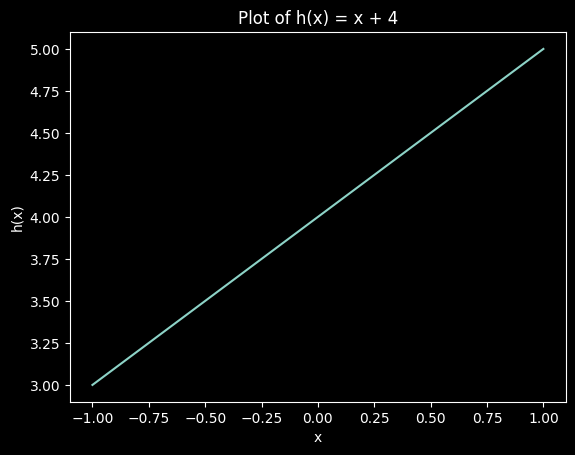

  0%|          | 0/3212 [00:00<?, ?it/s]

,exp_id,text,input_tokens,output_tokens,code_counter,code_snippet,code_output,error
0,Exp0002,<math_problem>Which is the smallest whole numb...,17687.0,105.0,0,None,None,None
1,Exp0004,<math_problem>Write the successor of $2440701$...,17702.0,93.0,1,print(2440701 + 1),2440702,None
2,Exp0005,<math_problem>Write the successor of $100199$....,17698.0,89.0,1,print(100199 + 1),100200,None
3,Exp0006,<math_problem>Write the successor of $1099999$...,17702.0,93.0,1,print(1099999 + 1),1100000,None
4,Exp0003,<math_problem>How many whole numbers are there...,17800.0,216.0,1,from sympy import Rational\n\n# Define value\n...,20,None
...,...,...,...,...,...,...,...,...
3207,Exp4325,<math_problem>If $A$ and $B$ are any two event...,17745.0,304.0,0,None,None,None
3208,Exp4293,<math_problem>A class has $15$ students whose ...,18704.0,915.0,1,"age = [14, 15, 16, 17, 18, 19, 20 ,21]\nprobab...","NameError(""name 'age' is not defined"")",NameError
3209,Exp4320,<math_problem>Assume that the chances of the p...,17826.0,585.0,1,from sympy import Rational\n\n# Define values\...,14/29,None
3210,Exp4322,<math_problem>An electronic assembly consists ...,17879.0,414.0,1,print(0.15 / 0.3),0.5,None


In [29]:
tqdm.pandas()

interim_fname = 'interim_results_gemini_flash_fp.jsonl'
interim_df = pd.read_json(interim_fname, lines=True, orient='records')
interim_df['code_counter'] = interim_df.text.progress_apply(lambda x: x.count('<code>') if x is not None else 0)
interim_df['code_snippet'] = interim_df.progress_apply(lambda x: re.findall(r'<code>(.*?)</code>', x.text, re.DOTALL)[0] if x.code_counter > 0 else None, axis=1)
interim_df['code_output'] = interim_df.code_snippet.progress_apply(lambda x: python_repl.run(x).strip() if x is not None else None)
interim_df['error'] = interim_df.code_output.progress_apply(lambda x: re.search(r'(.*)Error', x).group(1) + "Error" if x is not None and x.count('Error') > 0 else None)
interim_df

In [94]:
chapters_to_drop = [
    'Data Handling',
]

In [104]:
len(interim_df[interim_df['error'].notna()])

66

In [179]:
idx = 64
code_error_df = interim_df[interim_df['error'].notna()].copy(True).reset_index(drop=True)

exp_id = code_error_df.iloc[idx].exp_id

concept = df[df['id'] == exp_id].concept.values[0]
chapter = df[df['id'] == exp_id].chapter_name.values[0]
problem = df[df['id'] == exp_id].problem.values[0]
hint = df[df['id'] == exp_id].solution.values[0]
solution = code_error_df.iloc[idx].text
code_snippet = code_error_df.iloc[idx].code_snippet
error = code_error_df.iloc[idx].error

print(f"ExpID: {exp_id}\nConcept: {concept}\nChapter: {chapter}\n{'=='*50}\n\nProblem:\n\n{problem}\n\n{'=='*50}\n")
print(f"Solution:\n\n{solution}\n\nCode Snippet:\n\n{code_snippet}\n\n{'=='*50}\n\nError:\n\n{error}\n\n{'=='*50}\n")
print(f"Input Prompt:\n\n<START_OF_INPUTS>\n<PROBLEM>{problem}</PROBLEM>\n\n<HINTS>\n{hint}\n</HINTS>\n<END_OF_INPUTS>")

ExpID: Exp4293
Concept: Variance of a Random Variable
Chapter: Probability

Problem:

A class has 15 students whose ages are 14, 17, 15, 14, 21, 17, 19, 20, 16, 18, 20, 17, 16, 19 and 20 years. One student is selected in such a manner that each has the same chance of being chosen and the age X of the selected student is recorded. What is the probability distribution of the random variable X? Find mean, variance and standard deviation of X.


Solution:

<math_problem>A class has $15$ students whose ages are $14, 17, 15, 14, 21, 17, 19, 20, 16, 18, 20, 17, 16, 19$ and $20$ years. One student is selected in such a manner that each has the same chance of being chosen and the age $X$ of the selected student is recorded. What is the probability distribution of the random variable $X$? Find mean, variance and standard deviation of $X$.</math_problem>
<start_of_step>1
There are $15$ students in the class. Each student has the same chance to be chosen. Therefore, the probability of each student

In [177]:
new_solution = r"""<math_problem>Let $X$ denotes the sum of the numbers obtained when two fair dice are rolled. Find the variance and standard deviation of $X$.</math_problem>
<start_of_step>1
When two fair dice are rolled, $6 \times 6 = 36$ observations are obtained.
We need to find the probability distribution of $X$, which is the sum of the numbers obtained on the two dice.
<end_of_step>
<start_of_step>2
The probability distribution of $X$ is as follows:

| X | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|---|---|---|---|---|---|---|---|---|---|---|
| P(X) | 1/36 | 1/18 | 1/12 | 1/9 | 5/36 | 1/6 | 5/36 | 1/9 | 1/12 | 1/18 | 1/36 |
<end_of_step>
<start_of_step>3
The expected value of $X$ is:
$$E(X) = \sum_{i=1}^{12} X_i P(X_i) = 2 \times \frac{1}{36} + 3 \times \frac{1}{18} + 4 \times \frac{1}{12} + 5 \times \frac{1}{9} + 6 \times \frac{5}{36} + 7 \times \frac{1}{6} + 8 \times \frac{5}{36} + 9 \times \frac{1}{9} + 10 \times \frac{1}{12} + 11 \times \frac{1}{18} + 12 \times \frac{1}{36} =$$<code_input_block>
<code>from sympy import Rational

expected_value = 2 * Rational(1, 36) + 3 * Rational(1, 18) + 4 * Rational(1, 12) + 5 * Rational(1, 9) + 6 * Rational(5, 36) + 7 * Rational(1, 6) + 8 * Rational(5, 36) + 9 * Rational(1, 9) + 10 * Rational(1, 12) + 11 * Rational(1, 18) + 12 * Rational(1, 36)

print(expected_value)</code>
</code_input_block>
<code_output_block>
7
</code_output_block>
Therefore, the expected value of $X$ is $\boxed{7}$.<end_of_step>
<start_of_step>4
The variance of $X$ is:
$$Var(X) = E(X^2) - [E(X)]^2$$
We need to calculate $E(X^2)$:
$$E(X^2) = \sum_{i=1}^{12} X_i^2 P(X_i) = 2^2 \times \frac{1}{36} + 3^2 \times \frac{1}{18} + 4^2 \times \frac{1}{12} + 5^2 \times \frac{1}{9} + 6^2 \times \frac{5}{36} + 7^2 \times \frac{1}{6} + 8^2 \times \frac{5}{36} + 9^2 \times \frac{1}{9} + 10^2 \times \frac{1}{12} + 11^2 \times \frac{1}{18} + 12^2 \times \frac{1}{36} =$$<code_input_block>
<code>from sympy import Rational

expected_value_squared = (2**2) * Rational(1, 36) + (3**2) * Rational(1, 18) + (4**2) * Rational(1, 12) + (5**2) * Rational(1, 9) + (6**2) * Rational(5, 36) + (7**2) * Rational(1, 6) + (8**2) * Rational(5, 36) + (9**2) * Rational(1, 9) + (10**2) * Rational(1, 12) + (11**2) * Rational(1, 18) + (12**2) * Rational(1, 36)

print(expected_value_squared)</code>
</code_input_block>
<code_output_block>
329/6
</code_output_block>
Therefore, $E(X^2) = \frac{329}{6}$.<end_of_step>
<start_of_step>5
Now, we calculate the variance:
$$Var(X) = E(X^2) - [E(X)]^2 = \frac{329}{6} - 7^2 =$$<code_input_block>
<code>from sympy import Rational

value = Rational(329, 6) - 7**2

print(value)</code>
</code_input_block>
<code_output_block>
35/6
</code_output_block>
Therefore, the variance of $X$ is $\boxed{\frac{35}{6}}$.<end_of_step>
<end_of_step>
<start_of_step>6
Now, the standard deviation of $X$ is the square root of the variance:<code_input_block>
<code>from sympy import sqrt, Rational

variance = Rational(35, 6)
standard_deviation = sqrt(variance)

print(standard_deviation)</code>
</code_input_block>
<code_output_block>
sqrt(210)/6
</code_output_block>
Therefore, the standard deviation of $X$ is $\boxed{\frac{\sqrt{210}}{6}}$.<end_of_step>
<end_of_step>
<final_answer>35/6, sqrt(210)/6</final_answer>"""

In [178]:
new_example = {
    "problem": problem,
    "hint": hint,
    "output": new_solution
}

with open(os.path.join(EXAMPLES_FOLDER_PATH, f"{exp_id}.json"), "w") as f:
    json.dump(new_example, f, indent=4)

print(f'Saved {exp_id}.json in {EXAMPLES_FOLDER_PATH}')

Saved Exp4292.json in ../../../DataDump/AI-Mathematics-Olympiad/Few_Shot_Examples


### Use Few Shot Examples to Solve Math Problems using Gemini-Flash

In [26]:
df = pd.read_json(
    os.path.join(BASE_FOLDER, "preprocess_input.jsonl"), lines=True, orient="records"
)

In [3]:
EXAMPLES_FOLDER_NAME = "Few_Shot_Examples"
EXAMPLES_FOLDER_PATH = os.path.join(ROOT_DATA_DIR, EXAMPLES_FOLDER_NAME)
os.path.exists(EXAMPLES_FOLDER_PATH)

True

In [4]:
# Collect all the examples
all_examples = []

for fnames in os.listdir(EXAMPLES_FOLDER_PATH):
    with open(os.path.join(EXAMPLES_FOLDER_PATH, fnames), "r") as f:
        all_examples.append(json.load(f))

len(all_examples)

44

In [5]:
# Set up the Gemini Model
safety_settings = {
    HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_ONLY_HIGH,
    HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_ONLY_HIGH,
}

generation_config = GenerationConfig(
    candidate_count=1,
    max_output_tokens=8192,
    temperature=0.2,
    top_p=1,
    top_k=40,
    stop_sequences=["<code_output_block>", "<END_OF_OUTPUT>", "<END_OF_SOLUTION>"],
    response_mime_type="text/plain",
)

system_instruction = """Your are a high school student appearing for your math exam.
You have to solve the given math problems with step-by-step mathematical reasoning as well as using python, sympy, etc for calculations.

Here are rules that need to be followed:
- You have to solve any given problem is a pre-determined format which has been shown with help of many examples
- Follow the same format (shown in examples) strictly for all your solutions.
- If the value of mathematical constants like $/pi$, etc is not provided, then keep those constant names as is in the final Answer.
- You are free to use `math`, `fraction`, `sympy`, `scipy`, etc libraries to help with calculation codes.
- Always, I repeat always, you should always write the required python code to perform any kind of calculation while writing the solution
- You are not allowed to peform any calculations without writing the required code, if you do that, then marks will be deducted, always write the code required for making any calculations"""

gemini_flash_model = GenerativeModel(
    model_name="gemini-1.5-flash-001",
    safety_settings=safety_settings,
    generation_config=generation_config,
    system_instruction=system_instruction,
)

In [6]:
def generate_few_shot_prompt(
    examples: List[Dict[str, str]], without_hints: bool = False
) -> str:
    few_shot_prompt = ""

    if without_hints:
        example_format = """<PROBLEM>{problem}</PROBLEM>\n<START_OF_SOLUTION>\n{output}\n<END_OF_SOLUTION>\n\n"""
    else:
        example_format = """<START_OF_INPUTS>\n<PROBLEM>{problem}</PROBLEM>\n\n<HINTS>\n{hint}\n</HINTS>\n<END_OF_INPUTS>\n\n<START_OF_OUTPUT>\n{output}\n<END_OF_OUTPUT>\n\n"""

    for example in examples:
        if without_hints:
            few_shot_prompt += example_format.format(**example)
        else:
            few_shot_prompt += example_format.format(**example)

    return few_shot_prompt.strip()

In [7]:
gemini_flash_model.count_tokens(generate_few_shot_prompt(all_examples)), gemini_flash_model.count_tokens(generate_few_shot_prompt(all_examples, True))

(total_tokens: 19354
 total_billable_characters: 42299,
 total_tokens: 14903
 total_billable_characters: 35343)

In [7]:
print(generate_few_shot_prompt(all_examples[:2], without_hints=True))

<PROBLEM>Using the divisibility test, determine which of the following number is divisible by 4; by 8: 572</PROBLEM>
<START_OF_SOLUTION>
<math_problem>Using the divisibility test, determine which of the following numbers is divisible by $4$: $572$</math_problem>
<start_of_step>1
Lets find the remainder of $572 \div 4$<code_input_block>
<code>print(572 % 4)</code>
</code_input_block>
<code_output_block>
0
</code_output_block>
As the remainder is $0$, the number $572$ is $\boxed{\text{divisible}}$ by $4$.
<end_of_step>
<final_answer>True</final_answer>
<END_OF_SOLUTION>

<PROBLEM>Which is the smallest whole number?</PROBLEM>
<START_OF_SOLUTION>
<math_problem>Which is the smallest whole number?</math_problem>
<start_of_step>1
As the definition of whole numbers is not given, we assume:
- Whole numbers defined as the set of non-negative integers: $\{0, 1, 2, 3, \ldots\}$.<end_of_step>
<start_of_step>2
Hence, the smallest whole number is $\boxed{0}$.<end_of_step>
<final_answer>0</final_answe

In [8]:
def generate_input_prompt(
    problem: str,
    hint: str,
    few_shot_prompt: str,
    without_hints: bool = False,
    add_special_msg: bool = False,
) -> str:
    # Clean the problem and hint
    ## Replace multiple new lines with single new line
    problem = re.sub(r"\n+", "\n", problem)
    hint = re.sub(r"\n+", "\n", hint)

    ## Replace multiple spaces with single space
    problem = re.sub(r" +", " ", problem)
    hint = re.sub(r" +", " ", hint)

    ## Remove leading and trailing spaces
    problem = problem.strip()
    hint = hint.strip()

    special_message = """Initially you are given some examples enclosed in <START_OF_EXAMPLES> <END_OF_EXAMPLES> tags.\nThese are for you to understand the solution format, and follow it in your solutions.\n\nRemember that, you should always write the required python code to perform each and every kind of calculations.\nMake use of the code blocks for each and every calculation, even for addition, subtraction, counting, probability, etc - EACH AND EVERY CALCULATION!\n\n<START_OF_EXAMPLES>\n"""

    if add_special_msg:
        input_prompt = special_message + few_shot_prompt.strip() + "\n<END_OF_EXAMPLES>"
    else:
        input_prompt = few_shot_prompt.strip()

    if without_hints:
        input_prompt = (
            input_prompt
            + "\n\n"
            + f"<PROBLEM>{problem}</PROBLEM>\n<START_OF_SOLUTION>\n"
        )
    else:
        input_prompt = (
            input_prompt
            + "\n\n"
            + f"<START_OF_INPUTS>\n<PROBLEM>{problem}</PROBLEM>\n\n<HINTS>\n{hint}\n</HINTS>\n<END_OF_INPUTS>\n\n<START_OF_OUTPUT>\n"
        )

    return input_prompt.strip() + "\n"

In [9]:
print(
    generate_input_prompt(
        "P", "A", generate_few_shot_prompt(all_examples[:1], True), True, True
    )
)

Initially you are given some examples enclosed in <START_OF_EXAMPLES> <END_OF_EXAMPLES> tags.
These are for you to understand the solution format, and follow it in your solutions.

Remember that, you should always write the required python code to perform each and every kind of calculations.
Make use of the code blocks for each and every calculation, even for addition, subtraction, counting, probability, etc - EACH AND EVERY CALCULATION!

<START_OF_EXAMPLES>
<PROBLEM>Using the divisibility test, determine which of the following number is divisible by 4; by 8: 572</PROBLEM>
<START_OF_SOLUTION>
<math_problem>Using the divisibility test, determine which of the following numbers is divisible by $4$: $572$</math_problem>
<start_of_step>1
Lets find the remainder of $572 \div 4$<code_input_block>
<code>print(572 % 4)</code>
</code_input_block>
<code_output_block>
0
</code_output_block>
As the remainder is $0$, the number $572$ is $\boxed{\text{divisible}}$ by $4$.
<end_of_step>
<final_answer>

In [60]:
async def get_raw_output_from_llm(
    df: pd.DataFrame,
    gemini_model: GenerativeModel,
    interim_results_df: pd.DataFrame,
    interim_fname: str,
    prompt_col: str = "Prompt",
    save_every: int = 100,
    rpm: int = 200,
):
    # Setup Limiter
    # max_concurrent_tasks = 60
    rate_limiter = Limiter(rpm // 60)

    ## Async Function Call to Model ##
    async def gemini_async_call(text: str, exp_id: str):
        # with semaphore:
        await rate_limiter.wait()
        try:
            return await gemini_model.generate_content_async(text), exp_id
        except Exception:
            return None, exp_id

    ## Main Function ##
    tasks = []
    # too_long_counter = 0
    interim_results = []
    for _, current_row in tqdm(df.iterrows(), total=len(df), desc="Creating Tasks"):
        if current_row.id in interim_results_df.exp_id.values:
            continue

        input_prompt = current_row[prompt_col]
        exp_id = current_row.id
        tasks.append(asyncio.create_task(gemini_async_call(input_prompt, exp_id)))

    # print(f"Too Long Counter: {too_long_counter}")
    print(f"{len(tasks)} Tasks Created")
    counter = 0
    safety_counter = 0
    input_not_processed_counter = 0
    for done in tqdm_asyncio.as_completed(
        tasks, ncols=100, desc="Waiting for Tasks:", leave=True
    ):
        try:
            result, exp_id = await done
            result: GenerationResponse
            counter += 1

            if result is None:
                raise Exception

            try:
                interim_results.append(
                    {
                        "exp_id": exp_id,
                        "text": result.text,
                        "input_tokens": result._raw_response.usage_metadata.prompt_token_count,
                        "output_tokens": result._raw_response.usage_metadata.candidates_token_count,
                    }
                )

            except Exception:
                safety_counter += 1
                interim_results.append(
                    {
                        "exp_id": exp_id,
                        "text": None,
                        "input_tokens": None,
                        "output_tokens": None,
                    }
                )
                continue

        except Exception:
            # print(f"Error at index {idx} - input not processed")
            input_not_processed_counter += 1
            interim_results.append(
                {
                    "exp_id": exp_id,
                    "text": None,
                    "input_tokens": None,
                    "output_tokens": None,
                }
            )

        # Save to file
        if counter % save_every == 0:
            with jsonlines.open(interim_fname, "a") as writer:
                writer.write_all(interim_results)
            interim_results = []

    print(f"Number of Safety Blocks: {safety_counter}")
    print(f"Number of Input not processed: {input_not_processed_counter}")

    with jsonlines.open(interim_fname, "a") as writer:
        writer.write_all(interim_results)

    return df

In [15]:
tqdm.pandas()

# Load Data
df = pd.read_json(os.path.join('..', 'data', 'info_collection', 'preprocess_input.jsonl'), lines=True, orient='records')

chapters_to_drop = [
    'Data Handling',
]

# Filter Data
df = df[~df['chapter_name'].isin(chapters_to_drop)].reset_index(drop=True)

# Create fp_prompt column
df.drop(columns=['prompt'], inplace=True)
WIHTOUT_HINTS = True
df['prompt'] = df.progress_apply(lambda x: generate_input_prompt(x.problem, x.solution, generate_few_shot_prompt(all_examples, WIHTOUT_HINTS), WIHTOUT_HINTS, True), axis=1)


  0%|          | 0/4305 [00:00<?, ?it/s]

In [16]:
df.head()

,id,problem,solution,concept,chapter_name,prompt
0,Exp0000,Write the next three natural numbers after 10999.,"10,999+1 = 11,000\n11,000 + 1 = 11,001\n11,001...",Concept for Natural Numbers,Whole Numbers,Initially you are given some examples enclosed...
1,Exp0001,Write the three whole numbers occurring just b...,Three whole numbers occurring just before 1000...,Concept for Whole Numbers,Whole Numbers,Initially you are given some examples enclosed...
2,Exp0002,Which is the smallest whole number?,0 (zero) is the smallest whole number. All the...,Concept for Whole Numbers,Whole Numbers,Initially you are given some examples enclosed...
3,Exp0003,How many whole numbers are there between 32 an...,Whole numbers between 32 and 53 = 20 (53 − 32 ...,Concept for Whole Numbers,Whole Numbers,Initially you are given some examples enclosed...
4,Exp0004,Write the successor of 2440701.,The successor of 2440701 is\n2440701 + 1 = 244...,Successor and Predecessor of Whole Number,Whole Numbers,Initially you are given some examples enclosed...


In [5]:
# interim_fname = f'interim_results_Preprocessing_input_data_{pd.to_datetime("now").strftime("%Y%m%d_%H%M%S")}.jsonl'
interim_fname = "interim_results_gemini_flash_fp_WITHOUTHINTS.jsonl"
print(f"Interim Results File: {interim_fname}")

if not os.path.exists(interim_fname):
    with jsonlines.open(interim_fname, "w") as writer:
        writer.write_all([])

Interim Results File: interim_results_gemini_flash_fp_WITHOUTHINTS.jsonl


In [7]:
interim_fname = "interim_results_gemini_flash_fp_WITHOUTHINTS.jsonl"
with jsonlines.open(os.path.join(INTERIM_FOLDER, interim_fname), "r") as reader:
    interim_results_df = pd.DataFrame(reader)

if len(interim_results_df) == 0:
    interim_results_df = pd.DataFrame(
        columns=["exp_id", "text", "input_tokens", "output_tokens"]
    )

In [36]:
interim_results_df.dropna(subset=['text'], inplace=True)
interim_results_df.reset_index(drop=True, inplace=True)
interim_results_df.to_json(interim_fname, orient='records', lines=True)

In [20]:
intermedate_df = asyncio.run(
    get_raw_output_from_llm(
        df=df,
        gemini_model=gemini_flash_model,
        interim_results_df=interim_results_df,
        interim_fname=interim_fname,
        prompt_col='prompt',
        save_every=10,
        rpm=180,
    )
)

Creating Tasks:   0%|          | 0/4305 [00:00<?, ?it/s]

4305 Tasks Created


Waiting for Tasks:: 100%|███████████████████████████████████████| 4305/4305 [24:04<00:00,  2.98it/s]

Number of Safety Blocks: 24
Number of Input not processed: 0


  0%|          | 0/4272 [00:00<?, ?it/s]

  0%|          | 0/4272 [00:00<?, ?it/s]

  0%|          | 0/4272 [00:00<?, ?it/s]

Python REPL can execute arbitrary code. Use with caution.


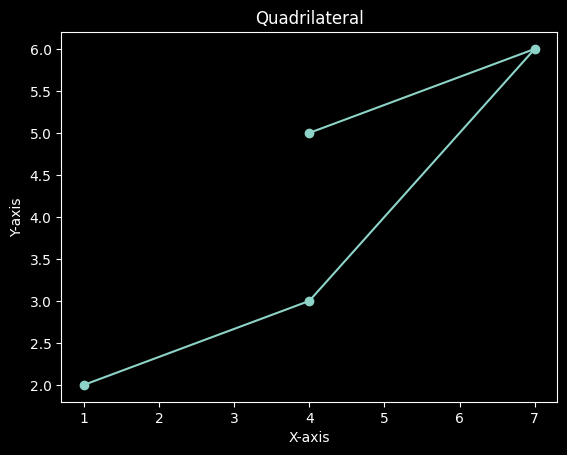

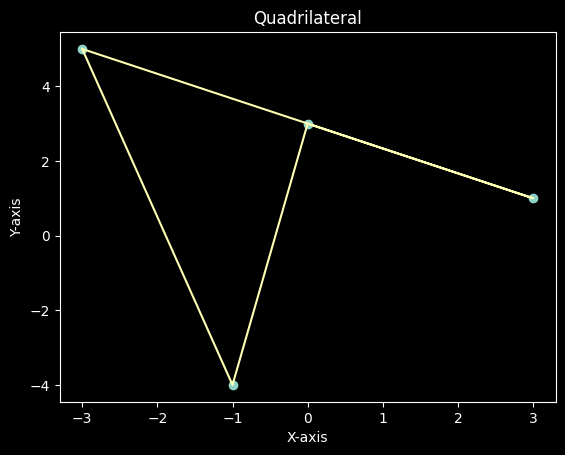

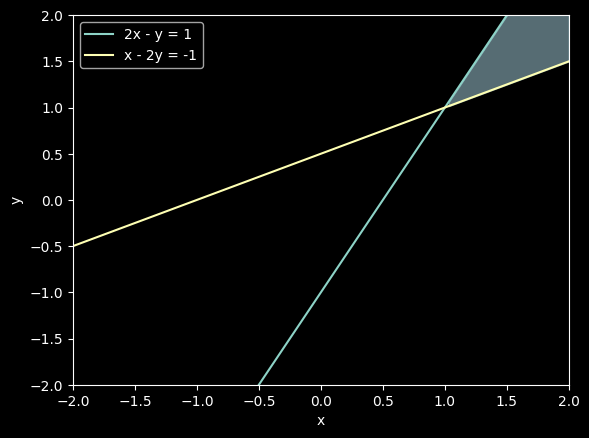

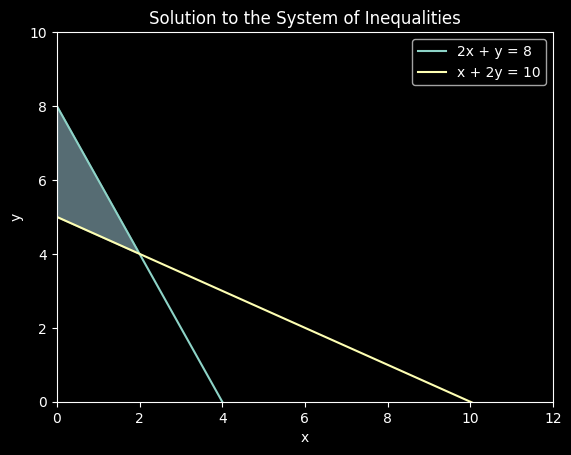

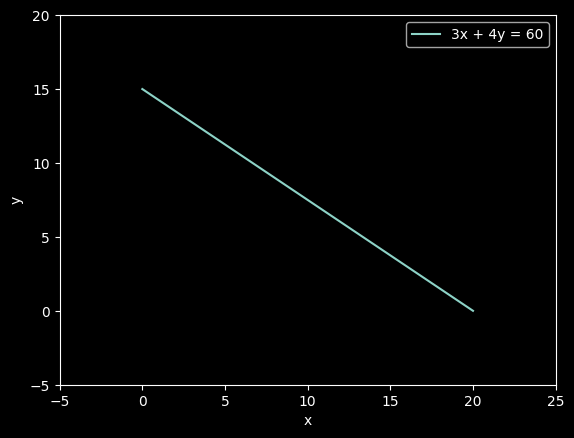

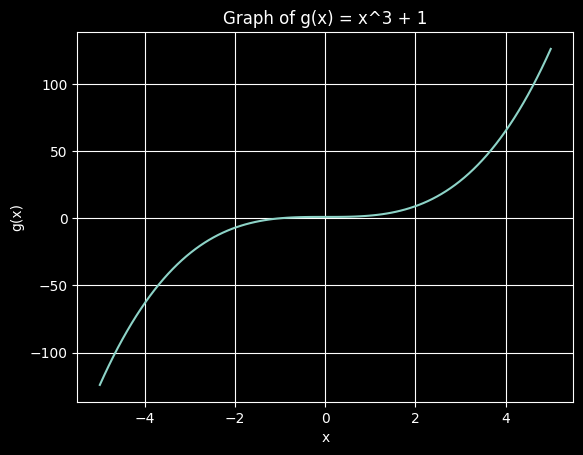

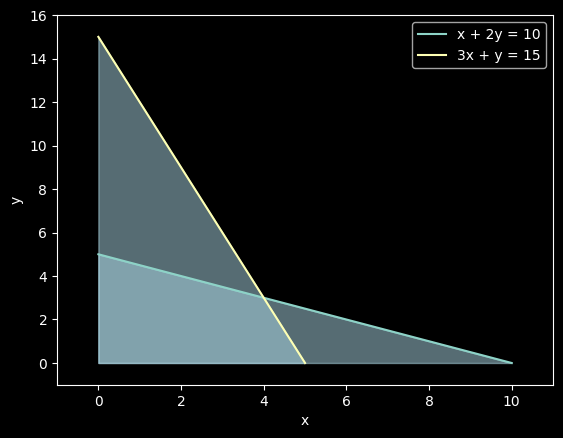

  0%|          | 0/4272 [00:00<?, ?it/s]

,exp_id,text,input_tokens,output_tokens,code_counter,code_snippet,code_output,error
0,Exp0002,<START_OF_SOLUTION>\n<math_problem>Which is th...,15248,125,0,None,None,None
1,Exp0000,<math_problem>Write the next three natural num...,15255,179,0,None,None,None
2,Exp0004,<math_problem>Write the successor of $2440701$...,15254,93,1,print(2440701 + 1),2440702,None
3,Exp0001,<math_problem>Write the three whole numbers oc...,15256,184,1,"print(10001 - 1, 10001 - 2, 10001 - 3)",10000 9999 9998,None
4,Exp0005,<math_problem>Write the successor of $100199$....,15253,118,1,print(100199 + 1),100200,None
...,...,...,...,...,...,...,...,...
4267,Exp4322,<math_problem>An electronic assembly consists ...,15329,567,0,None,None,None
4268,Exp4319,"<math_problem>In a game, a man wins a rupee fo...",15299,691,1,print((1/6 * 1) + (5/36 * 0) + (25/216 * -2) +...,-1.800925925925926,None
4269,Exp4324,"<math_problem>If $P(A|B) \gt P(A)$, then which...",15322,530,0,None,None,None
4270,Exp4321,<math_problem>If each element of a second orde...,15292,806,0,None,None,None


In [10]:
tqdm.pandas()

python_repl = PythonREPL()

interim_fname = "interim_results_gemini_flash_fp_WITHOUTHINTS.jsonl"
fp_interim_df = pd.read_json(
    os.path.join(INTERIM_FOLDER, interim_fname), lines=True, orient="records"
)
fp_interim_df["code_counter"] = fp_interim_df.text.progress_apply(
    lambda x: x.count("<code>") if x is not None else 0
)
fp_interim_df["code_snippet"] = fp_interim_df.progress_apply(
    lambda x: re.findall(r"<code>(.*?)</code>", x.text, re.DOTALL)[0]
    if x.code_counter > 0
    else None,
    axis=1,
)
fp_interim_df["code_output"] = fp_interim_df.code_snippet.progress_apply(
    lambda x: python_repl.run(x).strip() if x is not None else None
)
fp_interim_df["error"] = fp_interim_df.code_output.progress_apply(
    lambda x: re.search(r"(.*)Error", x).group(1) + "Error"
    if x is not None and x.count("Error") > 0
    else None
)
fp_interim_df

In [11]:
print(fp_interim_df.input_tokens.sum())  # 84_461_379
print(fp_interim_df.output_tokens.sum())  #  1_229_057

65253932
1197999


In [12]:
fp_interim_df.code_counter.value_counts()
# code_counter
# 0    2314
# 1    1975

code_counter
1    2305
0    1963
2       4
Name: count, dtype: int64

In [13]:
fp_interim_df.error.value_counts()
# error
# TypeError                   23
# ImportError                  7
# NameError                    6
# AttributeError               3
# NonInvertibleMatrixError     2
# IndexError                   1
# ModuleNotFoundError          1

error
TypeError                   24
ImportError                  9
NameError                    6
ModuleNotFoundError          3
ValueError                   2
AttributeError               2
NonInvertibleMatrixError     2
SyntaxError                  1
SympifyError                 1
ShapeError                   1
Name: count, dtype: int64

In [15]:
second_pass_df = fp_interim_df[
    (fp_interim_df.code_snippet.notna()) & (fp_interim_df.error.isna())
]
second_pass_df.reset_index(drop=True, inplace=True)
second_pass_df

,exp_id,text,input_tokens,output_tokens,code_counter,code_snippet,code_output,error
0,Exp0004,<math_problem>Write the successor of $2440701$...,15254,93,1,print(2440701 + 1),2440702,None
1,Exp0001,<math_problem>Write the three whole numbers oc...,15256,184,1,"print(10001 - 1, 10001 - 2, 10001 - 3)",10000 9999 9998,None
2,Exp0005,<math_problem>Write the successor of $100199$....,15253,118,1,print(100199 + 1),100200,None
3,Exp0006,<math_problem>Write the successor of $1099999$...,15254,122,1,print(1099999 + 1),1100000,None
4,Exp0008,<math_problem>Write the predecessor of $94$.</...,15249,102,1,print(94 - 1),93,None
...,...,...,...,...,...,...,...,...
2253,Exp4318,<math_problem>How many times must a man toss a...,15269,443,1,import math\n\nn = -math.log2(0.1)\nprint(n),3.321928094887362,None
2254,Exp4317,<math_problem>An experiment succeeds twice as ...,15270,555,1,"from sympy import Rational, binomial\n\n# Defi...",496/729,None
2255,Exp4320,<math_problem>Assume that the chances of the p...,15344,502,1,from sympy import Rational\n\nvalue = (0.28 * ...,0.482758620689655,None
2256,Exp4319,"<math_problem>In a game, a man wins a rupee fo...",15299,691,1,print((1/6 * 1) + (5/36 * 0) + (25/216 * -2) +...,-1.800925925925926,None


In [18]:
idx = 2216

exp_id = second_pass_df.exp_id[idx]
print(exp_id)

problem = df[df["id"] == exp_id].problem.values[0]
hint = df[df["id"] == exp_id].solution.values[0]
first_pass_sol = interim_df[interim_df["exp_id"] == exp_id].text.values[0].strip()
code_output = interim_df[interim_df["exp_id"] == exp_id].code_output.values[0].strip()

# Create second pass input prompt
first_pass_input_prompt = generate_input_prompt(
    problem, hint, generate_few_shot_prompt(all_examples)
)
first_pass_input_prompt_extended = (
    first_pass_sol + f"\n<code_output_block>\n{code_output}\n</code_output_block>\n"
)

second_pass_input_prompt = first_pass_input_prompt + first_pass_input_prompt_extended
print(first_pass_input_prompt_extended)

Exp4263
<math_problem>In a hostel, 60% of the students read Hindi newspaper, 40% read English newspaper and 20% read both Hindi and English news papers. A student is selected at random. If she reads Hindi news paper, find the probability that she reads English news paper.</math_problem>
<start_of_step>1
Let $H$ be the event that a student reads Hindi newspaper and $E$ be the event that a student reads English newspaper.
We are given that:
$P(H) = 0.60$
$P(E) = 0.40$
$P(H \cap E) = 0.20$
<end_of_step>
<start_of_step>2
We need to find the probability that a student reads English newspaper given that she reads Hindi newspaper, i.e., $P(E|H)$.
<end_of_step>
<start_of_step>3
Using the conditional probability formula, we have:
$$P(E|H) = \frac{P(E \cap H)}{P(H)} =$$<code_input_block>
<code>print(0.20 / 0.60)</code>
</code_input_block>
<code_output_block>
0.33333333333333337
</code_output_block>



In [19]:
def nth_pass_prompt(
    problem: str,
    hints: str,
    examples: list,
    last_pass_output: str,
    last_pass_code_output: str,
    without_hint: bool = False,
    add_special_msg: bool = False,
) -> str:
    # Generate Few Shot Prompt
    few_shot_prompt = generate_few_shot_prompt(examples, without_hint)

    # Generate Input Prompt
    input_prompt = generate_input_prompt(
        problem, hints, few_shot_prompt, without_hint, add_special_msg
    )

    # Generate Last Pass Output
    last_pass_output_extended = (
        last_pass_output
        + f"\n<code_output_block>\n{last_pass_code_output}\n</code_output_block>\n"
    )

    # Generate nth Pass Prompt
    nth_pass_input_prompt = input_prompt + last_pass_output_extended

    return nth_pass_input_prompt

In [ ]:
print(
    nth_pass_prompt(
        problem, hint, all_examples[:1], first_pass_sol, code_output, True, True
    )
)

In [21]:
second_pass_input_df = second_pass_df[["exp_id", "text", "code_output"]].copy(True)

# Create second pass input prompt
for idx, current_row in tqdm(
    second_pass_input_df.iterrows(),
    total=len(second_pass_input_df),
    desc="Creating Second Pass Input Prompt",
):
    exp_id = current_row.exp_id
    problem = df[df["id"] == exp_id].problem.values[0]
    hint = df[df["id"] == exp_id].solution.values[0]
    first_pass_sol = current_row.text.strip()
    code_output = current_row.code_output.strip()

    # Create nth pass input prompt
    nth_pass_input_prompt = nth_pass_prompt(
        problem, hint, all_examples, first_pass_sol, code_output
    )

    second_pass_input_df.loc[idx, "prompt"] = nth_pass_input_prompt

second_pass_input_df = second_pass_input_df[["exp_id", "prompt"]]
second_pass_input_df.columns = ["id", "prompt"]
second_pass_input_df

Creating Second Pass Input Prompt:   0%|          | 0/2258 [00:00<?, ?it/s]

,id,prompt
0,Exp0004,<START_OF_INPUTS>\n<PROBLEM>Using the divisibi...
1,Exp0001,<START_OF_INPUTS>\n<PROBLEM>Using the divisibi...
2,Exp0005,<START_OF_INPUTS>\n<PROBLEM>Using the divisibi...
3,Exp0006,<START_OF_INPUTS>\n<PROBLEM>Using the divisibi...
4,Exp0008,<START_OF_INPUTS>\n<PROBLEM>Using the divisibi...
...,...,...
2253,Exp4318,<START_OF_INPUTS>\n<PROBLEM>Using the divisibi...
2254,Exp4317,<START_OF_INPUTS>\n<PROBLEM>Using the divisibi...
2255,Exp4320,<START_OF_INPUTS>\n<PROBLEM>Using the divisibi...
2256,Exp4319,<START_OF_INPUTS>\n<PROBLEM>Using the divisibi...


In [73]:
# interim_fname = f'interim_results_Preprocessing_input_data_{pd.to_datetime("now").strftime("%Y%m%d_%H%M%S")}.jsonl'
interim_fname = 'interim_results_gemini_flash_sp_WIHOUTHINTS.jsonl'
print(f"Interim Results File: {interim_fname}")

if not os.path.exists(os.path.join(INTERIM_FOLDER, interim_fname)):
    with jsonlines.open(os.path.join(INTERIM_FOLDER, interim_fname), 'w') as writer:
        writer.write_all([])

Interim Results File: interim_results_gemini_flash_sp_WIHOUTHINTS.jsonl


In [74]:
interim_fname = 'interim_results_gemini_flash_sp_WIHOUTHINTS.jsonl'
with jsonlines.open(os.path.join(INTERIM_FOLDER, interim_fname), 'r') as reader:
    interim_results_df = pd.DataFrame(reader)

if len(interim_results_df) == 0:
    interim_results_df = pd.DataFrame(columns=['exp_id', 'text', 'input_tokens', 'output_tokens'])

interim_results_df

,exp_id,text,input_tokens,output_tokens


In [246]:
interim_results_df.dropna(subset=['text'], inplace=True)
interim_results_df.reset_index(drop=True, inplace=True)
interim_results_df.to_json(interim_fname, orient='records', lines=True)

In [75]:
intermedate_df = asyncio.run(
    get_raw_output_from_llm(
        df=second_pass_input_df,
        gemini_model=gemini_flash_model,
        interim_results_df=interim_results_df,
        interim_fname=interim_fname,
        prompt_col='prompt',
        save_every=10,
        rpm=180,
    )
)

Creating Tasks:   0%|          | 0/2258 [00:00<?, ?it/s]

2258 Tasks Created


Waiting for Tasks:: 100%|███████████████████████████████████████| 2258/2258 [12:50<00:00,  2.93it/s]

Number of Safety Blocks: 0
Number of Input not processed: 0


  0%|          | 0/2258 [00:00<?, ?it/s]

  0%|          | 0/2258 [00:00<?, ?it/s]

  0%|          | 0/2258 [00:00<?, ?it/s]

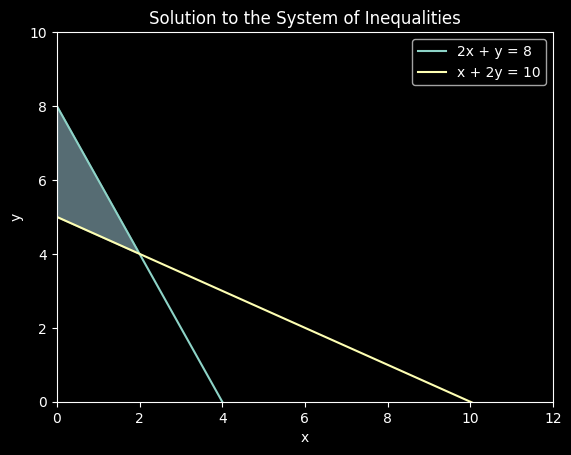

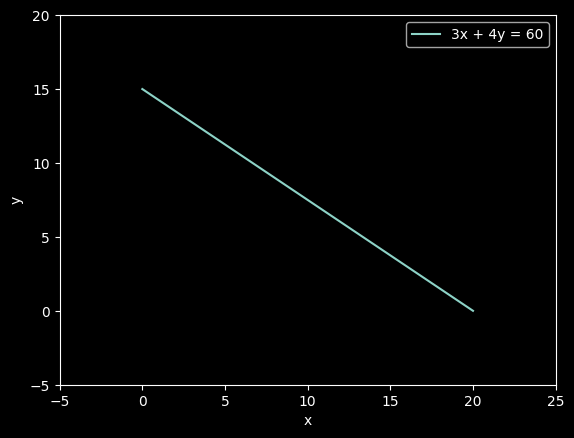

  0%|          | 0/2258 [00:00<?, ?it/s]

  0%|          | 0/2258 [00:00<?, ?it/s]

,exp_id,text,input_tokens,output_tokens,code_counter,code_snippet,code_output,error,starts_again
0,Exp0001,"<final_answer>10000, 9999, 9998</final_answer>\n",19942,28,0,None,None,None,False
1,Exp0004,Hence the successor of $2440701$ is $\boxed{24...,19770,51,0,None,None,None,False
2,Exp0005,Hence the successor of $100199$ is $\boxed{100...,19790,48,0,None,None,None,False
3,Exp0006,Hence the successor of $1099999$ is $\boxed{11...,19799,51,0,None,None,None,False
4,Exp0008,Hence the predecessor of $94$ is $\boxed{93}$<...,19754,36,0,None,None,None,False
...,...,...,...,...,...,...,...,...,...
2253,Exp4293,<START_OF_OUTPUT>\n<math_problem>A class has $...,21239,569,1,from sympy import Rational\n\nexpected_value =...,263/15,None,True
2254,Exp4301,<START_OF_OUTPUT>\n<math_problem>Suppose $X$ h...,20197,417,1,"from sympy import binomial, Rational\n\nn = 6\...",1/64,None,True
2255,Exp4292,<START_OF_OUTPUT>\n<math_problem>Let $X$ denot...,20779,614,1,from sympy import Rational\n\nexpected_value =...,7,None,True
2256,Exp4313,<START_OF_OUTPUT>\n<math_problem>Suppose that ...,20188,431,1,from scipy.special import comb\n\n# Define the...,1.0000000000000006e-10,None,True


In [17]:
tqdm.pandas()

interim_fname = "interim_results_gemini_flash_sp_WIHOUTHINTS.jsonl"
sc_interim_df = pd.read_json(
    os.path.join(INTERIM_FOLDER, interim_fname), lines=True, orient="records"
)
sc_interim_df["code_counter"] = sc_interim_df.text.progress_apply(
    lambda x: x.count("<code>") if x is not None else 0
)
sc_interim_df["code_snippet"] = sc_interim_df.progress_apply(
    lambda x: re.findall(r"<code>(.*?)</code>", x.text, re.DOTALL)[0]
    if x.code_counter > 0
    else None,
    axis=1,
)
sc_interim_df["code_output"] = sc_interim_df.code_snippet.progress_apply(
    lambda x: python_repl.run(x).strip() if x is not None else None
)
sc_interim_df["error"] = sc_interim_df.code_output.progress_apply(
    lambda x: re.search(r"(.*)Error", x).group(1) + "Error"
    if x is not None and x.count("Error") > 0
    else None
)
sc_interim_df["starts_again"] = sc_interim_df.text.progress_apply(
    lambda x: x.startswith("<START_OF_OUTPUT>")
)

sc_interim_df

In [18]:
sc_interim_df.starts_again.value_counts()

starts_again
False    2114
True      144
Name: count, dtype: int64

In [19]:
sc_interim_df[
    (sc_interim_df.code_counter > 0)
    & (sc_interim_df.error.isna())
    & (sc_interim_df.starts_again == False)
]

,exp_id,text,input_tokens,output_tokens,code_counter,code_snippet,code_output,error,starts_again
50,Exp0071,<start_of_step>2\nLets check if 15 is a factor...,20005,68,1,print(30 % 15),0,None,False
103,Exp0196,"<start_of_step>3\nThe LCM of 6, 8, and 12 is 2...",19915,125,1,"for i in range(1, 10):\n multiple = 24 * i\...",120,None,False
104,Exp0197,"<start_of_step>3\nThe LCM of 8, 10 and 12 is 1...",19918,118,1,print(999 // 120),8,None,False
105,Exp0200,"<start_of_step>3\nThe LCM of $6, 15$ and $18$ ...",19852,95,1,print(90 + 5),95,None,False
110,Exp0201,"<start_of_step>3\nThe LCM of 18, 24 and 32 is ...",19935,86,1,print(288 * 3)\nprint(288 * 4),864\n1152,None,False
...,...,...,...,...,...,...,...,...,...
2242,Exp4298,<start_of_step>4\nThe probability of getting $...,20642,128,1,from sympy import Rational\n\nvalue = 10 * Rat...,322687697779/1024000000000,None,False
2244,Exp4315,"<start_of_step>4\nTherefore, the probability o...",20173,101,1,from sympy import Rational\n\nvalue = Rational...,625/93312,None,False
2248,Exp4299,<start_of_step>3\n(ii) Probability that not mo...,20699,142,1,print(0.95**5 + 5 * 0.05 * 0.95**4),0.9774074999999998,None,False
2249,Exp4305,<start_of_step>4\nThe probability of throwing ...,21034,84,1,print(6 * (1/6) * (5/6)**5),0.401877572016461,None,False


In [21]:
RAW_PROBLEMS_FOLDER_NAME = "Raw_Problems"
RAW_PROBLEMS_FOLDER_PATH = os.path.join(ROOT_DATA_DIR, RAW_PROBLEMS_FOLDER_NAME)

In [22]:
def get_messages(parsed_text: str) -> List[Dict[str, str]]:
    messages = []

    # Extract the Problem
    problem = re.search(
        r"<math_problem>(.*?)</math_problem>", parsed_text, re.DOTALL
    ).group(1)
    messages.append({"role": "problem", "content": problem.strip()})

    # Extract all the Steps
    steps = re.findall(
        r"<start_of_step>\d+\n(.*?)<end_of_step>", parsed_text, re.DOTALL
    )

    # Extract the incomplete step
    if "<code_input_block>" in parsed_text:
        start_index = parsed_text.rfind("<start_of_step>")
        incomplete_step = re.search(
            r"<start_of_step>\d+\n(.*?)</code_input_block>",
            parsed_text[start_index:],
            re.DOTALL,
        ).group(1)
        steps.append(incomplete_step + "</code_input_block>")

    for step in steps:
        # Extract the text before the code block
        if "<code_input_block>" not in step:
            messages.append(
                {"role": "step", "content": [{"role": "text", "content": step.strip()}]}
            )
            continue
        else:
            text_before_code = re.search(
                r"(.*?)<code_input_block>", step, re.DOTALL
            ).group(1)
            try:
                text_after_code = re.search(
                    r"</code_output_block>(.*?)", step, re.DOTALL
                ).group(1)
            except Exception:
                text_after_code = None

            codes = re.findall(r"<code>(.*?)</code>", step, re.DOTALL)

            messages.append(
                {
                    "role": "step",
                    "content": [
                        {"role": "text", "content": text_before_code.strip()},
                        *[{"role": "code", "content": code.strip()} for code in codes],
                        {
                            "role": "code_output",
                            "content": [
                                python_repl.run(code).strip() for code in codes
                            ],
                        },
                    ],
                }
            )

            if text_after_code is not None:
                messages[-1]["content"].append(
                    {"role": "text", "content": text_after_code.strip()}
                )

    # Final Answer
    final_answer = re.search(
        r"<final_answer>(.*?)</final_answer>", parsed_text, re.DOTALL
    ).group(1)

    messages.append({"role": "final_answer", "content": final_answer.strip()})

    return messages

In [23]:
def replace_second_occurrence(text):
    parts = text.split("<math_problem>", 2)
    if len(parts) < 3:
        return text  # No replacement needed
    return "<math_problem>".join(parts[:2]) + "</math_problem>" + parts[2]


def replace_nth_occurrence(text, old, new, n):
    parts = text.split(old, n)
    if len(parts) < n + 1:
        return text  # No replacement needed
    return old.join(parts[:n]) + new + parts[n]


unicode_remapping = {
    "≅": r"\cong",
    "≠": r"\neq",
    "≡": r"\equiv",
    "≤": r"\leq",
    "≥": r"\geq",
    "⊥": r"\perp",
    "⊂": r"\subset",
    "⊆": r"\subseteq",
    "⊇": r"\supseteq",
    "⊕": r"\oplus",
    "⊗": r"\otimes",
    "∩": r"\cap",
    "∴": r"\therefore",
    "”": r"\"",
    "‘": r"'",
    "“": r"\"",
    "\xad": r"-",
    "–": r"-",
    "º": r"\degree",
    "°": r"\degree",
    "θ": r"\theta",
    "∞": r"\infty",
    "□": r"\square",
    "Σ": r"\Sigma",
    "…": r"\cdots",
    "³": r"^3",
    "′": r"'",
    "⇒": r"\implies",
    "×": r"\times",
    "Δ": r"\Delta",
    "σ": r"\sigma",
    "∆": r"\Delta",
    "÷": r"\div",
    "☐": r"\square",
    "Φ": r"\phi",
    "∠": r"\angle",
    "∵": r"\because",
    "±": r"\pm",
    "↔": r"\Leftrightarrow",
    "π": r"\pi",
    "²": r"^2",
    "μ": r"\mu",
    "≈": r"\approx",
    "₹": r"Rs.",
    "’": r"'",
}

new_unicode_remapping = {
    "\u2245": r"\cong",
    "\u22a5": r"\perp",
    "\u2229": r"\cap",
    "\u2234": r"\therefore",
    "\u201d": r"\"",
    "\u2018": r"'",
    "\u201c": r"\"",
    "\xad": r"-",
    "\xba": r"\degree",
    "\u2260": r"\neq",
    "\u03b8": r"\theta",
    "\u221e": r"\infty",
    "\u25a1": r"\square",
    "\u03a3": r"\Sigma",
    "\u2026": r"\cdots",
    "\xb3": r"^3",
    "\xb0": r"\degree",
    "\u2032": r"'",
    "\u21d2": r"\implies",
    "\xd7": r"\times",
    "\u0394": r"\Delta",
    "\u03c3": r"\sigma",
    "\u2206": r"\Delta",
    "\xf7": r"\div",
    "\u2610": r"\square",
    "\u2265": r"\geq",
    "\u03a6": r"\phi",
    "\u2220": r"\angle",
    "\u2235": r"\because",
    "\xb1": r"\pm",
    "\u2194": r"\Leftrightarrow",
    "\u03c0": r"\pi",
    "\xb2": r"^2",
    "\u2013": r"-",
    "\u03bc": r"\mu",
    "\u2248": r"\approx",
    "\u20b9": r"Rs.",
    "\u2264": r"\leq",
    "\u2019": r"'",
    "\u2212": r"-",
}

In [31]:
# Save all completed problems from fp interim results
counter = 0
for idx, current_row in tqdm(fp_interim_df.iterrows(), total=len(fp_interim_df), desc="Saving Completed Problems"):
    if current_row.code_counter > 0:
        continue

    if current_row.text is None:
        continue

    exp_id = current_row.exp_id
    problem = df[df["id"] == exp_id].problem.values[0]
    hint = df[df["id"] == exp_id].solution.values[0]
    parsed_text = current_row.text

    # Remove Excess space after step number if any
    try:
        parsed_text = re.sub(
            r"(<start_of_step>\d+)\s+", r"\1\n", parsed_text, re.DOTALL
        )
    except Exception:
        print(f"Error at exp {exp_id} - input not processed")
        break

    # Replace Unicode Characters, if any
    for key, value in new_unicode_remapping.items():
        parsed_text = parsed_text.replace(key, value)

    # <math_problem> appears twice in the text, then replace only the second occurence with </math_problem> tag
    if parsed_text.count("<math_problem>") > 1:
        parsed_text = replace_nth_occurrence(
            parsed_text, "<math_problem>", "</math_problem>", 2
        )

    if parsed_text.count("</code_input_block>") > 1:
        parsed_text = replace_nth_occurrence(
            parsed_text, "</code_input_block>", "<code_input_block>", 1
        )

    if (
        parsed_text.count("<code_input_block>") == 0
        and parsed_text.count("</code_input_block>") == 1
    ):
        parsed_text = parsed_text.replace("</code_input_block>", "<end_of_step>")

    if "</start_of_step>" in parsed_text:
        parsed_text = parsed_text.replace("</start_of_step>", "<end_of_step>")

    if parsed_text.count("<math_problem>") > 1:
        parsed_text = replace_second_occurrence(parsed_text)

    # print(parsed_text)
    # print(repr(parsed_text))
    try:
        get_messages(parsed_text)
    except Exception:
        print(f"Error at exp {exp_id} - input not processed")
        continue

    new_example = {
        "problem": problem,
        "hint": hint,
        "raw_output": parsed_text,
        "message_format": get_messages(parsed_text),
    }

    with open(os.path.join(RAW_PROBLEMS_FOLDER_PATH, f"{exp_id}.json"), "w") as f:
        json.dump(new_example, f, indent=4)
    counter += 1

print(f"Saved {counter} Completed Problems in {RAW_PROBLEMS_FOLDER_PATH}")

Saving Completed Problems:   0%|          | 0/4272 [00:00<?, ?it/s]

Saved 1963 Completed Problems in ../../../DataDump/AI-Mathematics-Olympiad/Raw_Problems


In [ ]:
# Have a look later
# Error at exp Exp2542 - input not processed
# Error at exp Exp2944 - input not processed
# Error at exp Exp3650 - input not processed
# Error at exp Exp3782 - input not processed
# Error at exp Exp3798 - input not processed
# Error at exp Exp4029 - input not processed

In [32]:
# Completed with Second Pass
sp_complete_df = (
    sc_interim_df[
        (sc_interim_df.code_counter == 0)
        & (sc_interim_df.error.isna())
        & (sc_interim_df.starts_again == False)
    ]
    .copy(deep=True)
    .reset_index(drop=True)
)
sp_complete_df

,exp_id,text,input_tokens,output_tokens,code_counter,code_snippet,code_output,error,starts_again
0,Exp0001,"<final_answer>10000, 9999, 9998</final_answer>\n",19942,28,0,None,None,None,False
1,Exp0004,Hence the successor of $2440701$ is $\boxed{24...,19770,51,0,None,None,None,False
2,Exp0005,Hence the successor of $100199$ is $\boxed{100...,19790,48,0,None,None,None,False
3,Exp0006,Hence the successor of $1099999$ is $\boxed{11...,19799,51,0,None,None,None,False
4,Exp0008,Hence the predecessor of $94$ is $\boxed{93}$<...,19754,36,0,None,None,None,False
...,...,...,...,...,...,...,...,...,...
1450,Exp4312,"<start_of_step>4\nTherefore, the probability o...",20160,63,0,None,None,None,False
1451,Exp4317,<final_answer>496/729</final_answer>\n,20335,18,0,None,None,None,False
1452,Exp4318,"<start_of_step>6\nTherefore, $n$ must be great...",20243,81,0,None,None,None,False
1453,Exp4320,<final_answer>0.482758620689655</final_answer>\n,20313,28,0,None,None,None,False


In [49]:
def get_messages_v2(parsed_text: str, verbose: bool = False) -> List[Dict[str, str]]:
    messages = []

    # Extract the Problem
    problem = re.search(
        r"<math_problem>(.*)</math_problem>", parsed_text, re.DOTALL
    ).group(1)
    messages.append({"role": "problem", "content": problem.strip()})

    # Extract all the Steps
    steps = re.findall(
        r"<start_of_step>\d+\n(.*?)<end_of_step>", parsed_text, re.DOTALL
    )

    # Extract the incomplete step
    if parsed_text.count("<code_input_block") < parsed_text.count(
        "<code_output_block>"
    ):
        start_index = parsed_text.rfind("<start_of_step>")
        incomplete_step = re.search(
            r"<start_of_step>\d+\n(.*)</code_input_block>",
            parsed_text[start_index:],
            re.DOTALL,
        ).group(1)
        steps.append(incomplete_step + "</code_input_block>")

    if verbose:
        print(f"\n{'=='*50}\nFound {len(steps)} Steps")
        print(steps)

    for step in steps:
        # Extract the text before the code block
        if "<code_input_block>" not in step:
            messages.append(
                {"role": "step", "content": [{"role": "text", "content": step.strip()}]}
            )
            continue
        else:
            text_before_code = re.search(
                r"(.*)<code_input_block>", step, re.DOTALL
            ).group(1)

            if "</code_output_block>" in step:
                text_after_code = re.search(
                    r"</code_output_block>(.*)", step, re.DOTALL
                ).group(1)
                text_after_code = (
                    None if text_after_code.strip() == "" else text_after_code
                )
            else:
                text_after_code = None

            codes = re.findall(r"<code>(.*)</code>", step, re.DOTALL)

            if verbose:
                print(f"Text Before Code: {text_before_code}")
                print(f"Text After Code: {text_after_code}")
                print(f"Codes: {codes}")

            messages.append(
                {
                    "role": "step",
                    "content": [
                        {"role": "text", "content": text_before_code.strip()},
                        *[{"role": "code", "content": code.strip()} for code in codes],
                        {
                            "role": "code_output",
                            "content": [
                                python_repl.run(code).strip() for code in codes
                            ],
                        },
                    ],
                }
            )

            if text_after_code is not None:
                if text_after_code.strip() != "":
                    messages[-1]["content"].append(
                        {"role": "text", "content": text_after_code.strip()}
                    )

    # Final Answer
    if "<final_answer>" in parsed_text:
        final_answer = re.search(
            r"<final_answer>(.*?)</final_answer>", parsed_text, re.DOTALL
        ).group(1)
        messages.append({"role": "final_answer", "content": final_answer.strip()})

    return messages

In [50]:
def convert_output_to_message_format(
    parsed_text: str, verbose: bool = False
) -> List[Dict[str, str]]:
    # Remove Excess space after step number if any
    parsed_text = re.sub(r"(<start_of_step>\d+)\s+", r"\1\n", parsed_text, re.DOTALL)

    # Replace Unicode Characters, if any
    for key, value in new_unicode_remapping.items():
        parsed_text = parsed_text.replace(key, value)

    # <math_problem> appears twice in the text, then replace only the second occurence with </math_problem> tag
    if parsed_text.count("<math_problem>") > 1:
        parsed_text = replace_nth_occurrence(
            parsed_text, "<math_problem>", "</math_problem>", 2
        )

    if parsed_text.count("</code_input_block>") > 1:
        parsed_text = replace_nth_occurrence(
            parsed_text, "</code_input_block>", "<code_input_block>", 1
        )

    if (
        parsed_text.count("<code_input_block>") == 0
        and parsed_text.count("</code_input_block>") == 1
    ):
        parsed_text = parsed_text.replace("</code_input_block>", "<end_of_step>")

    if "</start_of_step>" in parsed_text:
        parsed_text = parsed_text.replace("</start_of_step>", "<end_of_step>")

    if parsed_text.count("<math_problem>") > 1:
        parsed_text = replace_second_occurrence(parsed_text)

    if verbose:
        print(parsed_text)
    # print(repr(parsed_text))
    return get_messages_v2(parsed_text, verbose)

In [51]:
step = "Lets perform the calculation: $125 \\times 8 \\times 40 \\times 25=$<code_input_block>\n<code>print(125 * 8 * 40 * 25)</code>\n</code_input_block>\n<code_output_block>\n1000000\n</code_output_block>\nTherefore, $125 \\times 40 \\times 8 \\times 25 = \\boxed{1000000}$"
re.search(r"</code_output_block>\n(.*)", step, re.DOTALL).group(1)

'Therefore, $125 \\times 40 \\times 8 \\times 25 = \\boxed{1000000}$'

In [52]:
convert_output_to_message_format(
    "<math_problem>Find the product by suitable rearrangement: $125 \\times 40 \\times 8 \\times 25$.</math_problem>\n<start_of_step>1\nLets perform the calculation: $125 \\times 8 \\times 40 \\times 25=$<code_input_block>\n<code>print(125 * 8 * 40 * 25)</code>\n</code_input_block>\n<code_output_block>\n1000000\n</code_output_block>\nTherefore, $125 \\times 40 \\times 8 \\times 25 = \\boxed{1000000}$<end_of_step>\n<final_answer>1000000</final_answer>",
    True,
)

<math_problem>Find the product by suitable rearrangement: $125 \times 40 \times 8 \times 25$.</math_problem>
<start_of_step>1
Lets perform the calculation: $125 \times 8 \times 40 \times 25=$<code_input_block>
<code>print(125 * 8 * 40 * 25)</code>
</code_input_block>
<code_output_block>
1000000
</code_output_block>
Therefore, $125 \times 40 \times 8 \times 25 = \boxed{1000000}$<end_of_step>
<final_answer>1000000</final_answer>

Found 1 Steps
['Lets perform the calculation: $125 \\times 8 \\times 40 \\times 25=$<code_input_block>\n<code>print(125 * 8 * 40 * 25)</code>\n</code_input_block>\n<code_output_block>\n1000000\n</code_output_block>\nTherefore, $125 \\times 40 \\times 8 \\times 25 = \\boxed{1000000}$']
Text Before Code: Lets perform the calculation: $125 \times 8 \times 40 \times 25=$
Text After Code: 
Therefore, $125 \times 40 \times 8 \times 25 = \boxed{1000000}$
Codes: ['print(125 * 8 * 40 * 25)']


[{'role': 'problem',
  'content': 'Find the product by suitable rearrangement: $125 \\times 40 \\times 8 \\times 25$.'},
 {'role': 'step',
  'content': [{'role': 'text',
    'content': 'Lets perform the calculation: $125 \\times 8 \\times 40 \\times 25=$'},
   {'role': 'code', 'content': 'print(125 * 8 * 40 * 25)'},
   {'role': 'code_output', 'content': ['1000000']},
   {'role': 'text',
    'content': 'Therefore, $125 \\times 40 \\times 8 \\times 25 = \\boxed{1000000}$'}]},
 {'role': 'final_answer', 'content': '1000000'}]

In [32]:
idx = 1454
exp_id = "Exp0019"
# exp_id = sc_complete_df.exp_id[idx]

first_pass_sol = interim_df[interim_df["exp_id"] == exp_id].text.values[0].strip()
code_output = interim_df[interim_df["exp_id"] == exp_id].code_output.values[0].strip()
second_pass_sol = (
    sp_complete_df[sp_complete_df["exp_id"] == exp_id].text.values[0].strip()
)

if second_pass_sol.count("<end_of_step>") == second_pass_sol.count("<start_of_step>"):
    final_sol = (
        first_pass_sol
        + f"\n<code_output_block>\n{code_output}\n</code_output_block><end_of_step>\n"
        + second_pass_sol
    )
else:
    final_sol = (
        first_pass_sol
        + f"\n<code_output_block>\n{code_output}\n</code_output_block>\n"
        + second_pass_sol
    )
# print(final_sol)

msg_fmt = convert_output_to_message_format(final_sol, True)
print()
msg_fmt

<math_problem>600 is the successor of 599.
True False</math_problem>
<start_of_step>1
The successor of a number is the next number in the sequence. To find the successor, we simply add 1 to the given number.
Therefore, the successor of 599 is 599 + 1 =
<code_input_block>
<code>print(599 + 1)</code>
</code_input_block>
<code_output_block>
600
</code_output_block><end_of_step>
<start_of_step>2
Hence, the successor of 599 is 600.
Therefore, the given statement is $\boxed{\text{True}}$.<end_of_step>
<final_answer>True</final_answer>
Found 2 Steps



[{'role': 'problem', 'content': '600 is the successor of 599.\nTrue False'},
 {'role': 'step',
  'content': [{'role': 'text',
    'content': 'The successor of a number is the next number in the sequence. To find the successor, we simply add 1 to the given number.\nTherefore, the successor of 599 is 599 + 1 ='},
   {'role': 'code', 'content': 'print(599 + 1)'},
   {'role': 'code_output', 'content': ['600']}]},
 {'role': 'step',
  'content': [{'role': 'text',
    'content': 'Hence, the successor of 599 is 600.\nTherefore, the given statement is $\\boxed{\\text{True}}$.'}]},
 {'role': 'final_answer', 'content': 'True'}]

Saving Completed Problems:   0%|          | 0/1455 [00:00<?, ?it/s]

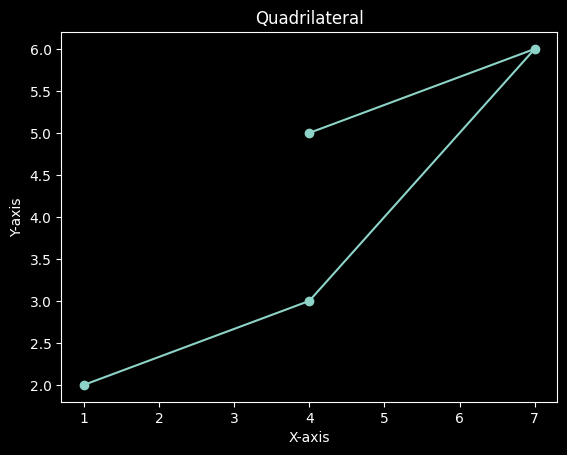

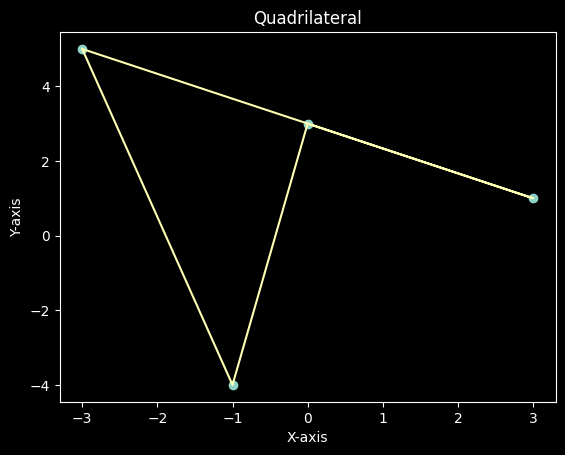

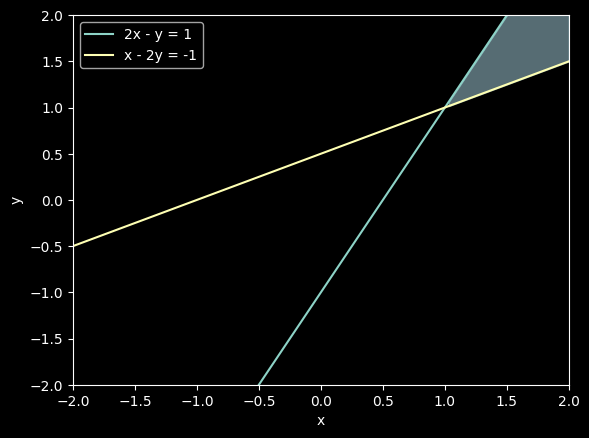

Error at exp Exp3521 - input not processed


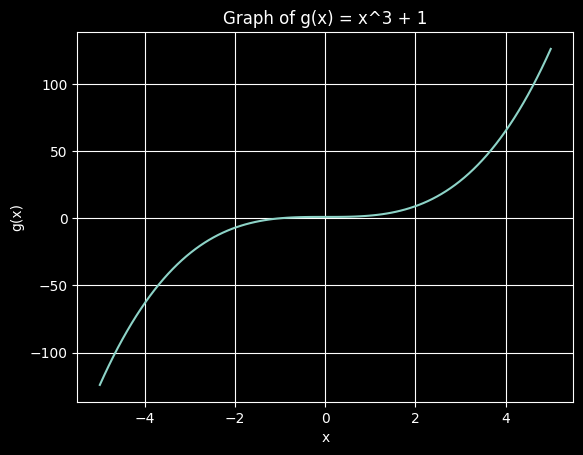

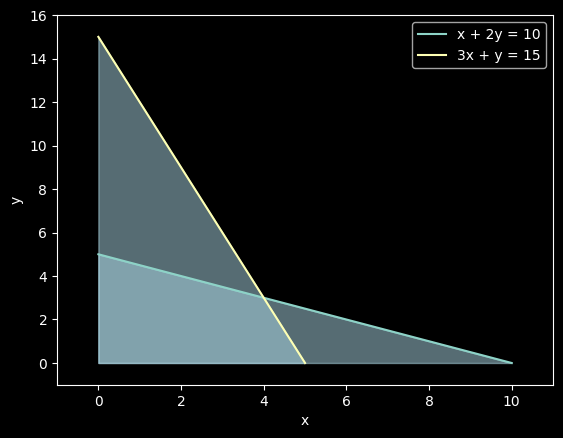

Saved 1450 Completed Problems in ../../../DataDump/AI-Mathematics-Olympiad/Raw_Problems


In [53]:
# Save all completed problems from fp interim results
counter = 0
for idx, current_row in tqdm(sp_complete_df.iterrows(), total=len(sp_complete_df), desc="Saving Completed Problems"):
    if current_row.code_counter > 0:
        continue

    if current_row.text is None:
        continue

    exp_id = current_row.exp_id
    problem = df[df["id"] == exp_id].problem.values[0]
    hint = df[df["id"] == exp_id].solution.values[0]

    first_pass_sol = (
        fp_interim_df[fp_interim_df["exp_id"] == exp_id].text.values[0].strip()
    )
    code_output = (
        fp_interim_df[fp_interim_df["exp_id"] == exp_id].code_output.values[0].strip()
    )
    second_pass_sol = (
        sp_complete_df[sp_complete_df["exp_id"] == exp_id].text.values[0].strip()
    )

    if second_pass_sol == "":
        continue

    if second_pass_sol.count("<end_of_step>") == second_pass_sol.count(
        "<start_of_step>"
    ):
        final_sol = (
            first_pass_sol
            + f"\n<code_output_block>\n{code_output}\n</code_output_block><end_of_step>\n"
            + second_pass_sol
        )
    else:
        final_sol = (
            first_pass_sol
            + f"\n<code_output_block>\n{code_output}\n</code_output_block>\n"
            + second_pass_sol
        )

    try:
        msg_fmt = convert_output_to_message_format(final_sol)
    except Exception:
        print(f"Error at exp {exp_id} - input not processed")
        continue

    new_example = {
        "problem": problem,
        "hint": hint,
        "raw_output": final_sol,
        "message_format": msg_fmt,
    }

    with open(os.path.join(RAW_PROBLEMS_FOLDER_PATH, f"{exp_id}.json"), "w") as f:
        json.dump(new_example, f, indent=4)
    counter += 1

print(f"Saved {counter} Completed Problems in {RAW_PROBLEMS_FOLDER_PATH}")

In [54]:
third_pass_df = sc_interim_df[
    (sc_interim_df.code_snippet.notna())
    & (sc_interim_df.error.isna())
    & (sc_interim_df.starts_again == False)
]
third_pass_df.reset_index(drop=True, inplace=True)
third_pass_input_df = third_pass_df[["exp_id", "text", "code_output"]].copy(True)
third_pass_input_df

,exp_id,text,code_output
0,Exp0071,<start_of_step>2\nLets check if 15 is a factor...,0
1,Exp0196,"<start_of_step>3\nThe LCM of 6, 8, and 12 is 2...",120
2,Exp0197,"<start_of_step>3\nThe LCM of 8, 10 and 12 is 1...",8
3,Exp0200,"<start_of_step>3\nThe LCM of $6, 15$ and $18$ ...",95
4,Exp0201,"<start_of_step>3\nThe LCM of 18, 24 and 32 is ...",864\n1152
...,...,...,...
647,Exp4298,<start_of_step>4\nThe probability of getting $...,322687697779/1024000000000
648,Exp4315,"<start_of_step>4\nTherefore, the probability o...",625/93312
649,Exp4299,<start_of_step>3\n(ii) Probability that not mo...,0.9774074999999998
650,Exp4305,<start_of_step>4\nThe probability of throwing ...,0.401877572016461


In [52]:
current_row = third_pass_input_df.loc[651]
exp_id = current_row.exp_id
problem = df[df["id"] == exp_id].problem.values[0]
hint = df[df["id"] == exp_id].solution.values[0]

first_pass_sol = interim_df[interim_df["exp_id"] == exp_id].text.values[0].strip()
first_pass_code = (
    sc_interim_df[sc_interim_df["exp_id"] == exp_id].code_output.values[0].strip()
)
second_pass_sol = (
    sc_interim_df[sc_interim_df["exp_id"] == exp_id].text.values[0].strip()
)
second_pass_code_output = current_row.code_output.strip()

if second_pass_sol.count("<end_of_step>") == second_pass_sol.count("<start_of_step>"):
    third_pass_input = (
        first_pass_sol
        + f"\n<code_output_block>\n{first_pass_code}\n</code_output_block><end_of_step>\n"
        + second_pass_sol
    )
else:
    third_pass_input = (
        first_pass_sol
        + f"\n<code_output_block>\n{first_pass_code}\n</code_output_block>\n"
        + second_pass_sol
    )


# Create nth pass input prompt
nth_pass_input_prompt = nth_pass_prompt(
    problem, hint, [], third_pass_input, second_pass_code_output, True, True
)

print(nth_pass_input_prompt)
# print(third_pass_input)

Initially you are given some examples enclosed in <START_OF_EXAMPLES> <END_OF_EXAMPLES> tags.
These are for you to understand the solution format, and follow it in your solutions.

Remember that, you should always write the required python code to perform each and every kind of calculations.
Make use of the code blocks for each and every calculation, even for addition, subtraction, counting, probability, etc - EACH AND EVERY CALCULATION!

<START_OF_EXAMPLES>

<END_OF_EXAMPLES>

<PROBLEM>In a hurdle race, a player has to cross 10 hurdles. The probability that he will clear each hurdle is 5/6 . What is the probability that he will knock down fewer than 2 hurdles?</PROBLEM>
<START_OF_SOLUTION>
<math_problem>In a hurdle race, a player has to cross $10$ hurdles. The probability that he will clear each hurdle is $\frac{5}{6}$. What is the probability that he will knock down fewer than $2$ hurdles?</math_problem>
<start_of_step>1
The player can knock down fewer than $2$ hurdles in two ways:
-

In [149]:
print("Hi", flush=True)

In [53]:
# Create second pass input prompt
for idx, current_row in tqdm(third_pass_input_df.iterrows(), total=len(third_pass_input_df), desc="Creating Third Pass Input Prompt"):
    exp_id = current_row.exp_id
    problem = df[df["id"] == exp_id].problem.values[0]
    hint = df[df["id"] == exp_id].solution.values[0]

    first_pass_sol = interim_df[interim_df["exp_id"] == exp_id].text.values[0].strip()
    first_pass_code = (
        sc_interim_df[sc_interim_df["exp_id"] == exp_id].code_output.values[0].strip()
    )
    second_pass_sol = (
        sc_interim_df[sc_interim_df["exp_id"] == exp_id].text.values[0].strip()
    )
    second_pass_code_output = current_row.code_output.strip()

    third_pass_input = first_pass_sol

    if second_pass_sol.count("<end_of_step>") == second_pass_sol.count(
        "<start_of_step>"
    ):
        third_pass_input += f"\n<code_output_block>\n{first_pass_code}\n</code_output_block><end_of_step>\n"
    else:
        third_pass_input += (
            f"\n<code_output_block>\n{first_pass_code}\n</code_output_block>\n"
        )

    third_pass_input += second_pass_sol

    # Create nth pass input prompt
    nth_pass_input_prompt = nth_pass_prompt(
        problem,
        hint,
        all_examples,
        third_pass_input,
        second_pass_code_output,
        True,
        True,
    )

    third_pass_input_df.loc[idx, "prompt"] = nth_pass_input_prompt

third_pass_input_df = third_pass_input_df[["exp_id", "prompt"]]
third_pass_input_df.columns = ["id", "prompt"]
third_pass_input_df

Creating Third Pass Input Prompt:   0%|          | 0/652 [00:00<?, ?it/s]

,id,prompt
0,Exp0071,Initially you are given some examples enclosed...
1,Exp0196,Initially you are given some examples enclosed...
2,Exp0197,Initially you are given some examples enclosed...
3,Exp0200,Initially you are given some examples enclosed...
4,Exp0201,Initially you are given some examples enclosed...
...,...,...
647,Exp4298,Initially you are given some examples enclosed...
648,Exp4315,Initially you are given some examples enclosed...
649,Exp4299,Initially you are given some examples enclosed...
650,Exp4305,Initially you are given some examples enclosed...


In [57]:
# interim_fname = f'interim_results_Preprocessing_input_data_{pd.to_datetime("now").strftime("%Y%m%d_%H%M%S")}.jsonl'
interim_fname = "interim_results_gemini_flash_tp_WIHOUTHINTS.jsonl"
print(f"Interim Results File: {interim_fname}")

if not os.path.exists(os.path.join(INTERIM_FOLDER, interim_fname)):
    with jsonlines.open(interim_fname, "w") as writer:
        writer.write_all([])

Interim Results File: interim_results_gemini_flash_tp_WIHOUTHINTS.jsonl


In [58]:
interim_fname = "interim_results_gemini_flash_tp_WIHOUTHINTS.jsonl"
with jsonlines.open(os.path.join(INTERIM_FOLDER, interim_fname), "r") as reader:
    interim_results_df = pd.DataFrame(reader)

if len(interim_results_df) == 0:
    interim_results_df = pd.DataFrame(
        columns=["exp_id", "text", "input_tokens", "output_tokens"]
    )

interim_results_df

,exp_id,text,input_tokens,output_tokens


In [ ]:
interim_results_df.dropna(subset=['text'], inplace=True)
interim_results_df.reset_index(drop=True, inplace=True)
interim_results_df.to_json(interim_fname, orient='records', lines=True)

In [61]:
intermedate_df = asyncio.run(
    get_raw_output_from_llm(
        df=third_pass_input_df,
        gemini_model=gemini_flash_model,
        interim_results_df=interim_results_df,
        interim_fname=interim_fname,
        prompt_col="prompt",
        save_every=10,
        rpm=180,
    )
)

Creating Tasks:   0%|          | 0/652 [00:00<?, ?it/s]

652 Tasks Created


Waiting for Tasks:: 100%|█████████████████████████████████████████| 652/652 [03:40<00:00,  2.96it/s]

Number of Safety Blocks: 0
Number of Input not processed: 0


In [55]:
tqdm.pandas()

interim_fname = "interim_results_gemini_flash_tp_WIHOUTHINTS.jsonl"
tp_interim_df = pd.read_json(
    os.path.join(INTERIM_FOLDER, interim_fname), lines=True, orient="records"
)
tp_interim_df["code_counter"] = tp_interim_df.text.progress_apply(
    lambda x: x.count("<code>") if x is not None else 0
)
tp_interim_df["code_snippet"] = tp_interim_df.progress_apply(
    lambda x: re.findall(r"<code>(.*?)</code>", x.text, re.DOTALL)[-1]
    if x.code_counter > 0
    else None,
    axis=1,
)
tp_interim_df["code_output"] = tp_interim_df.code_snippet.progress_apply(
    lambda x: python_repl.run(x).strip() if x is not None else None
)
tp_interim_df["error"] = tp_interim_df.code_output.progress_apply(
    lambda x: re.search(r"(.*)Error", x).group(1) + "Error"
    if x is not None and x.count("Error") > 0
    else None
)
tp_interim_df["starts_again"] = tp_interim_df.text.progress_apply(
    lambda x: x.strip().startswith("<START_OF_SOLUTION>")
)

tp_interim_df

  0%|          | 0/652 [00:00<?, ?it/s]

  0%|          | 0/652 [00:00<?, ?it/s]

  0%|          | 0/652 [00:00<?, ?it/s]

  0%|          | 0/652 [00:00<?, ?it/s]

  0%|          | 0/652 [00:00<?, ?it/s]

,exp_id,text,input_tokens,output_tokens,code_counter,code_snippet,code_output,error,starts_again
0,Exp0196,"<start_of_step>4\nTherefore, the smallest 3-di...",15584,63,0,None,None,None,False
1,Exp0201,"<start_of_step>4\nHence, the smallest 4-digit ...",15558,65,0,None,None,None,False
2,Exp0197,"<start_of_step>4\nTherefore, the greatest 3-di...",15568,61,1,print(8 * 120),960,None,False
3,Exp0259,"<start_of_step>3\nHence, $45 - (-11) = 57 + (-...",15457,61,0,None,None,None,False
4,Exp0257,"<start_of_step>3\nTherefore, $(-3) + (-6) = \b...",15450,71,0,None,None,None,False
...,...,...,...,...,...,...,...,...,...
647,Exp4314,"<start_of_step>4\nTherefore, the probability o...",15636,126,1,from sympy import Rational\n\nvalue = (Rationa...,9765625/20155392,None,False
648,Exp4245,<START_OF_SOLUTION>\n<math_problem>A fair die ...,16032,411,1,from sympy import Rational\n\nvalue = Rational...,1/2,None,True
649,Exp4299,<start_of_step>4\n(iii) Probability that more ...,15788,135,1,print(1 - (0.95**5 + 5 * 0.05 * 0.95**4)),0.022592500000000237,None,False
650,Exp4271,<start_of_step>4\n- $P(T) = \frac{6000}{2000 +...,15731,86,1,print(6000 / (2000 + 4000 + 6000)),0.5,None,False


In [56]:
tp_complete_df = (
    tp_interim_df[
        (tp_interim_df.code_counter == 0)
        & (tp_interim_df.error.isna())
        & (tp_interim_df.starts_again == False)
    ]
    .copy(deep=True)
    .reset_index(drop=True)
)

tp_complete_df

,exp_id,text,input_tokens,output_tokens,code_counter,code_snippet,code_output,error,starts_again
0,Exp0196,"<start_of_step>4\nTherefore, the smallest 3-di...",15584,63,0,None,None,None,False
1,Exp0201,"<start_of_step>4\nHence, the smallest 4-digit ...",15558,65,0,None,None,None,False
2,Exp0259,"<start_of_step>3\nHence, $45 - (-11) = 57 + (-...",15457,61,0,None,None,None,False
3,Exp0257,"<start_of_step>3\nTherefore, $(-3) + (-6) = \b...",15450,71,0,None,None,None,False
4,Exp0260,"<start_of_step>3\nTherefore, $(-25) - (-42) = ...",15470,68,0,None,None,None,False
...,...,...,...,...,...,...,...,...,...
300,Exp4193,"<start_of_step>9\nTherefore, the coordinates o...",15959,92,0,None,None,None,False
301,Exp4247,"<start_of_step>3\nTherefore, the conditional p...",15928,58,0,None,None,None,False
302,Exp4255,"<start_of_step>4\nTherefore, if A and B are in...",15984,65,0,None,None,None,False
303,Exp4276,"<start_of_step>6\nTherefore, the probability t...",16002,61,0,None,None,None,False


In [57]:
def fix_end_of_step(
    previous_chunk: str, current_chunk: str, current_code_output: str
) -> str:
    if current_chunk.count("<end_of_step>") <= current_chunk.count("<start_of_step>"):
        return (
            previous_chunk
            + f"\n<code_output_block>\n{current_code_output}\n</code_output_block><end_of_step>\n{current_chunk}"
        )
    else:
        return (
            previous_chunk
            + f"\n<code_output_block>\n{current_code_output}\n</code_output_block>\n{current_chunk}"
        )

In [59]:
idx = 304
# exp_id = "Exp0019"
exp_id = tp_complete_df.exp_id[idx]

first_pass_sol = fp_interim_df[fp_interim_df["exp_id"] == exp_id].text.values[0].strip()
first_pass_code_output = (
    fp_interim_df[fp_interim_df["exp_id"] == exp_id].code_output.values[0].strip()
)
second_pass_sol = (
    sc_interim_df[sc_interim_df["exp_id"] == exp_id].text.values[0].strip()
)
second_pass_code_output = (
    sc_interim_df[sc_interim_df["exp_id"] == exp_id].code_output.values[0].strip()
)
second_pass_sol = fix_end_of_step(
    first_pass_sol, second_pass_sol, first_pass_code_output
)

third_pass_sol = (
    tp_complete_df[tp_complete_df["exp_id"] == exp_id].text.values[0].strip()
)

third_pass_sol = fix_end_of_step(
    second_pass_sol, third_pass_sol, second_pass_code_output
)

# print(third_pass_sol)
msg_fmt = convert_output_to_message_format(third_pass_sol, True)
print()
msg_fmt

<math_problem>A die is thrown again and again until three sixes are obtained. Find the probability of obtaining the third six in the sixth throw of the die.</math_problem>
<start_of_step>1
The probability of getting a six on a single throw of a die is $\frac{1}{6}$.<end_of_step>
<start_of_step>2
The probability of not getting a six on a single throw of a die is $1 - \frac{1}{6} = \frac{5}{6}$.<end_of_step>
<start_of_step>3
To get the third six on the sixth throw, we need to have two sixes in the first five throws and one six on the sixth throw.
The probability of getting two sixes in the first five throws is given by:
$$^5C_2 \times \left(\frac{1}{6}\right)^2 \times \left(\frac{5}{6}\right)^3 =$$<code_input_block>
<code>from sympy import Rational

value = Rational(5, 2) * (Rational(1, 6))**2 * (Rational(5, 6))**3

print(value)</code>
<code_input_block>
<code_output_block>
625/15552
</code_output_block><end_of_step>
<start_of_step>4
Therefore, the probability of obtaining the third six 

[{'role': 'problem',
  'content': 'A die is thrown again and again until three sixes are obtained. Find the probability of obtaining the third six in the sixth throw of the die.'},
 {'role': 'step',
  'content': [{'role': 'text',
    'content': 'The probability of getting a six on a single throw of a die is $\\frac{1}{6}$.'}]},
 {'role': 'step',
  'content': [{'role': 'text',
    'content': 'The probability of not getting a six on a single throw of a die is $1 - \\frac{1}{6} = \\frac{5}{6}$.'}]},
 {'role': 'step',
  'content': [{'role': 'text',
    'content': 'To get the third six on the sixth throw, we need to have two sixes in the first five throws and one six on the sixth throw.\nThe probability of getting two sixes in the first five throws is given by:\n$$^5C_2 \\times \\left(\\frac{1}{6}\\right)^2 \\times \\left(\\frac{5}{6}\\right)^3 =$$<code_input_block>\n<code>from sympy import Rational\n\nvalue = Rational(5, 2) * (Rational(1, 6))**2 * (Rational(5, 6))**3\n\nprint(value)</code>

In [61]:
# Save all completed problems from fp interim results
counter = 0
for idx, current_row in tqdm(tp_complete_df.iterrows(), total=len(tp_complete_df), desc="Saving Completed Problems"):
    if current_row.code_counter > 0:
        continue

    if current_row.text is None:
        continue

    exp_id = current_row.exp_id

    first_pass_sol = (
        fp_interim_df[fp_interim_df["exp_id"] == exp_id].text.values[0].strip()
    )
    first_pass_code_output = (
        fp_interim_df[fp_interim_df["exp_id"] == exp_id].code_output.values[0].strip()
    )
    second_pass_sol = (
        sc_interim_df[sc_interim_df["exp_id"] == exp_id].text.values[0].strip()
    )
    second_pass_code_output = (
        sc_interim_df[sc_interim_df["exp_id"] == exp_id].code_output.values[0].strip()
    )
    second_pass_sol = fix_end_of_step(
        first_pass_sol, second_pass_sol, first_pass_code_output
    )

    third_pass_sol = (
        tp_complete_df[tp_complete_df["exp_id"] == exp_id].text.values[0].strip()
    )

    parsed_text = fix_end_of_step(
        second_pass_sol, third_pass_sol, second_pass_code_output
    )

    try:
        msg_fmt = convert_output_to_message_format(parsed_text)
    except Exception:
        print(f"Error at exp {exp_id} - input not processed")
        continue

    new_example = {
        "problem": problem,
        "hint": hint,
        "raw_output": parsed_text,
        "message_format": msg_fmt,
    }

    with open(os.path.join(RAW_PROBLEMS_FOLDER_PATH, f"{exp_id}.json"), "w") as f:
        json.dump(new_example, f, indent=4)
    counter += 1

print(f"Saved {counter} Completed Problems in {RAW_PROBLEMS_FOLDER_PATH}")

Saving Completed Problems:   0%|          | 0/305 [00:00<?, ?it/s]

Saved 305 Completed Problems in ../../../DataDump/AI-Mathematics-Olympiad/Raw_Problems


In [62]:
len(os.listdir(RAW_PROBLEMS_FOLDER_PATH))

3718